# Smart-Kage NOR analysis 

This notebook uses the combined MASTER NOR tables generated from the postprocessing notebook.

Main analysis generated here:

1. Total exploration
2. Average exploration over time for 4 h and 24 h.
3. Cumulative exploration for 2 h and 24 h.
4. Test-phase DI over 2 h, 10 h and 24 h.
5. Side-bias DI.
6. First approach count and percentage.

In [5]:
import sys
print(sys.executable)

/opt/anaconda3/envs/smart-kages/bin/python


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

pd.set_option("display.max_columns", 100)


## Figure formatting and constants


In [66]:
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

FIG_W = 10
FIG_H = 8
WIDE_W = 25
WIDE_H = 15

AGE_ORDER = ["3m"]
GENO_ORDER = ["WT", "RELN-Colbos"]
PHASE_ORDER = ["sample", "ITI_baseline", "test", ]

GENO_COLORS = {
    "WT": "blue",
    "RELN-Colbos": "red",
    # "APP1-em1BDS": "#FF8C00",
    # "NLF": "#9B5DE5",
}

FIRST_APPROACH_COLORS = {
    "novel": "#2EC4C7",
    "familiar": "#F28CC8",
}

SMOOTH_SIGMA = 1.5
ROW_DURATION = 0.5  # one drum-output row is 0.5 s


def format_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(axis="both", direction="in", width=1.2, length=5, pad=6)
    ax.set_facecolor("white")
    return ax


def sem(x):
    return x.sem()


def clean_phase_label(x):
    return str(x).replace("_", " ").capitalize()


## Load MASTER NOR data

Expected folder:

`/Volumes/Aimi_SmrtKg/NOR_MASTER`

Expected files:

- `NOR_MASTER_binned.csv`
- `NOR_MASTER_events.csv`
- `NOR_MASTER_first_approach.csv`
- `NOR_MASTER_phase_total.csv`
- `NOR_MASTER_test_di_per_mouse.csv`
- `NOR_MASTER_test_first2h_binned.csv`
- `NOR_MASTER_test_first2h_mouse_DI.csv`

The notebook recomputes most summaries from `NOR_MASTER_binned.csv` so age, genotype and phase are never accidentally pooled.


In [8]:
ROOT_BASE = Path(r"/Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration")
# ROOT_BASE = Path(r"/Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB")
MASTER_OUTPUT = ROOT_BASE / "NOR_MASTER"

MASTER_BINNED = MASTER_OUTPUT / "NOR_MASTER_binned.csv"
MASTER_EVENTS = MASTER_OUTPUT / "NOR_MASTER_events.csv"
MASTER_FIRST = MASTER_OUTPUT / "NOR_MASTER_first_approach.csv"
MASTER_PHASE_TOTAL = MASTER_OUTPUT / "NOR_MASTER_phase_total.csv"
MASTER_TEST_DI_MOUSE = MASTER_OUTPUT / "NOR_MASTER_test_first2h_mouse_DI.csv"
MASTER_TEST_2H = MASTER_OUTPUT / "NOR_MASTER_test_first2h_binned.csv"

binned_df = pd.read_csv(MASTER_BINNED)

if MASTER_EVENTS.exists():
    events = pd.read_csv(MASTER_EVENTS)
else:
    events = None
    print("Warning: NOR_MASTER_events.csv not found. Event-aligned before/after plots need this file.")

if MASTER_FIRST.exists():
    first_approach_df = pd.read_csv(MASTER_FIRST)
else:
    first_approach_df = None
    print("Warning: NOR_MASTER_first_approach.csv not found.")

print("binned_df shape:", binned_df.shape)
binned_df.head()


binned_df shape: (5717, 18)


,bin,left,right,left_sec,right_sec,total_sec,KageID,Genotype,Phase,rotation,window_end,NOR_side,cumulative_left_sec,cumulative_right_sec,cumulative_total_sec,Cohort,Age,MouseSessionID
0,0,0,1,0.0,0.5,0.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,0.0,0.5,0.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1
1,1,3,59,1.5,29.5,31.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,1.5,30.0,31.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1
2,2,33,0,16.5,0.0,16.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,18.0,30.0,48.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1
3,3,18,20,9.0,10.0,19.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,40.0,67.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1
4,4,0,6,0.0,3.0,3.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,43.0,70.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1


In [9]:

# ==========================================================
# PDF EXPORT FOR EVERY FIGURE IN THIS NOTEBOOK
# ==========================================================

from matplotlib.backends.backend_pdf import PdfPages
import re

FIGURE_PDF_DIR = MASTER_OUTPUT / "all_figure_pdfs"
FIGURE_PDF_DIR.mkdir(parents=True, exist_ok=True)

ALL_FIGURES_PDF_PATH = MASTER_OUTPUT / "SmartKage_NOR_all_figures.pdf"

# Close an old writer if this setup cell is re-run.
if "_ALL_FIGURES_PDF" in globals():
    try:
        _ALL_FIGURES_PDF.close()
    except Exception:
        pass

_ALL_FIGURES_PDF = PdfPages(ALL_FIGURES_PDF_PATH)
_FIGURE_PDF_COUNTER = 0


def _safe_pdf_name(text):
    """Convert a figure title into a filesystem-safe filename."""
    text = str(text).strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "", text)
    return text[:120] or "figure"


def save_figure_pdf(fig=None, name=None):
    """
    Save the current figure:
      1. as an individual vector PDF; and
      2. as one page in the combined multipage PDF.

    This function is inserted immediately before every plt.show() call.
    """
    global _FIGURE_PDF_COUNTER

    if fig is None:
        fig = plt.gcf()

    # Do not save an empty placeholder figure.
    if fig is None or not fig.get_axes():
        return None

    _FIGURE_PDF_COUNTER += 1

    if name is None:
        title = fig._suptitle.get_text() if fig._suptitle is not None else ""

        if not title and fig.axes:
            title = fig.axes[0].get_title()

        name = title or f"figure_{_FIGURE_PDF_COUNTER:03d}"

    filename = (
        f"{_FIGURE_PDF_COUNTER:03d}_"
        f"{_safe_pdf_name(name)}.pdf"
    )

    individual_path = FIGURE_PDF_DIR / filename

    fig.savefig(
        individual_path,
        format="pdf",
        bbox_inches="tight",
    )

    _ALL_FIGURES_PDF.savefig(
        fig,
        bbox_inches="tight",
    )

    print(f"Saved PDF: {individual_path.name}")
    return individual_path


print("Individual figure PDFs will be saved to:")
print(FIGURE_PDF_DIR)
print("\nA combined multipage PDF will be saved to:")
print(ALL_FIGURES_PDF_PATH)


Individual figure PDFs will be saved to:
/Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration/NOR_MASTER/all_figure_pdfs

A combined multipage PDF will be saved to:
/Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration/NOR_MASTER/SmartKage_NOR_all_figures.pdf


## Clean columns and phase labels

The master table should already contain `Age`, `Cohort`, `Genotype`, `MouseSessionID` and `Phase`.

This cell standardises phase names and keeps only the main analysis phases:

- sample
- ITI_baseline
- test

The post-trial baseline is excluded from the main analysis.


In [10]:
# Standardise core text columns
for col in ["Age", "Genotype", "Phase", "KageID", "Cohort", "rotation", "cumulative_total_sec", "MouseSessionID"]:
    if col in binned_df.columns:
        binned_df[col] = binned_df[col].astype(str).str.strip()

# Fix common phase spellings
phase_replace = {
    "iti_baseline": "ITI_baseline",
    "ITI baseline": "ITI_baseline",
    "Iti baseline": "ITI_baseline",
    "baseline": "ITI_baseline",  # only use this if old files had one baseline label
    "post baseline": "post_trial_baseline",
    "post_trial": "post_trial_baseline",
    "post_trial_baseline": "post_trial_baseline",
    "sample": "sample",
    "test": "test",
}

binned_df["Phase"] = binned_df["Phase"].replace(phase_replace)

# Make sure bin is numeric and minutes
binned_df["bin"] = pd.to_numeric(binned_df["bin"], errors="coerce")
binned_df = binned_df.dropna(subset=["bin"]).copy()
binned_df["bin"] = binned_df["bin"].astype(int)
binned_df["time_min"] = binned_df["bin"]
binned_df["time_hr"] = binned_df["bin"] / 60

# Keep main NOR phases only for most plots
main_binned = binned_df[binned_df["Phase"].isin(PHASE_ORDER)].copy()

print("Ages:", sorted(main_binned["Age"].unique()))
print("Genotypes:", sorted(main_binned["Genotype"].unique()))
print("Phases:", main_binned["Phase"].value_counts())
main_binned.head()


Ages: ['3m']
Genotypes: ['RELN-Colbos', 'WT']
Phases: Phase
sample          1595
test            1422
ITI_baseline    1201
Name: count, dtype: int64


,bin,left,right,left_sec,right_sec,total_sec,KageID,Genotype,Phase,rotation,window_end,NOR_side,cumulative_left_sec,cumulative_right_sec,cumulative_total_sec,Cohort,Age,MouseSessionID,time_min,time_hr
0,0,0,1,0.0,0.5,0.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,0.0,0.5,0.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,0,0.000000
1,1,3,59,1.5,29.5,31.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,1.5,30.0,31.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,1,0.016667
2,2,33,0,16.5,0.0,16.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,18.0,30.0,48.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,2,0.033333
3,3,18,20,9.0,10.0,19.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,40.0,67.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,3,0.050000
4,4,0,6,0.0,3.0,3.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,43.0,70.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,4,0.066667


## Helper functions for grouped time-series plots

- Summaries are grouped by `Age`, `Genotype`, `Phase` and time


In [11]:
def rebin_timeseries(data, value_cols, bin_factor=1, cutoff_min=None):
    """Re-bin per mouse/session before taking group means.

    If bin_factor=1, each bin is 1 min.
    If bin_factor=5, data are collapsed into 5-min bins.
    """
    df = data.copy()
    if cutoff_min is not None:
        df = df[df["time_min"] <= cutoff_min].copy()

    df["time_bin"] = (df["time_min"] // bin_factor) * bin_factor

    group_cols = ["MouseSessionID", "KageID", "Cohort", "Age", "Genotype", "Phase", "rotation", "cumulative_total_sec", "time_bin"]
    available_group_cols = [c for c in group_cols if c in df.columns]

    agg = {col: (col, "sum") for col in value_cols if col in df.columns}

    return (
        df.groupby(available_group_cols, as_index=False)
          .agg(**agg)
          .rename(columns={"time_bin": "time_min"})
    )


def summarise_timeseries(data, value_col):
    return (
        data
        .groupby(["Age", "Genotype", "Phase", "time_min"], as_index=False)
        .agg(
            mean_value=(value_col, "mean"),
            sem_value=(value_col, sem),
            n=(value_col, "count")
        )
    )


def plot_age_phase_grid(summary, y_label, title, cutoff_min, sigma=SMOOTH_SIGMA, ylim=None):
    """3x3 grid: rows = age, columns = phase, lines = genotype."""
    fig, axes = plt.subplots(
        len(AGE_ORDER),
        len(PHASE_ORDER),
        figsize=(18, 5* len(AGE_ORDER)),
        sharex=True,
        sharey=True,
        squeeze=False
    )

    for r, age in enumerate(AGE_ORDER):
        for c, phase in enumerate(PHASE_ORDER):
            ax = axes[r, c]
            sub = summary[(summary["Age"] == age) & (summary["Phase"] == phase)].copy()

            for genotype in GENO_ORDER:
                temp = sub[sub["Genotype"] == genotype].sort_values("time_min")
                if temp.empty:
                    continue

                y = gaussian_filter1d(temp["mean_value"].values, sigma=sigma)
                e = gaussian_filter1d(temp["sem_value"].fillna(0).values, sigma=sigma)

                ax.plot(
                    temp["time_min"],
                    y,
                    color=GENO_COLORS.get(genotype, "black"),
                    label=genotype,
                    linewidth=2
                )

                ax.fill_between(
                    temp["time_min"],
                    y - e,
                    y + e,
                    color=GENO_COLORS.get(genotype, "black"),
                    alpha=0.18
                )

            format_axes(ax)
            ax.set_xlim(0, cutoff_min)
            if ylim is not None:
                ax.set_ylim(*ylim)

            if r == 0:
                ax.set_title(clean_phase_label(phase))
            if c == 0:
                ax.set_ylabel(f"{age}{y_label}")
            if r == len(AGE_ORDER) - 1:
                ax.set_xlabel("Time from wheel change (min)")

    handles, labels = axes[0, -1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98)
    )
    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    save_figure_pdf()
plt.show()


# Wheel change timestamps

This section examines when wheel changes occurred for each NOR phase.

Purpose:
- Check whether wheel changes happened at consistent times across mice.
- Identify any sessions with unusually early or late wheel changes.
- Confirm that differences in behavioural measures are not explained by large differences in the timing of wheel changes.

Plot:
- Each point represents one wheel change for one mouse.

Saved PDF: 001_Timing_of_Wheel_Changes_across_mice.pdf


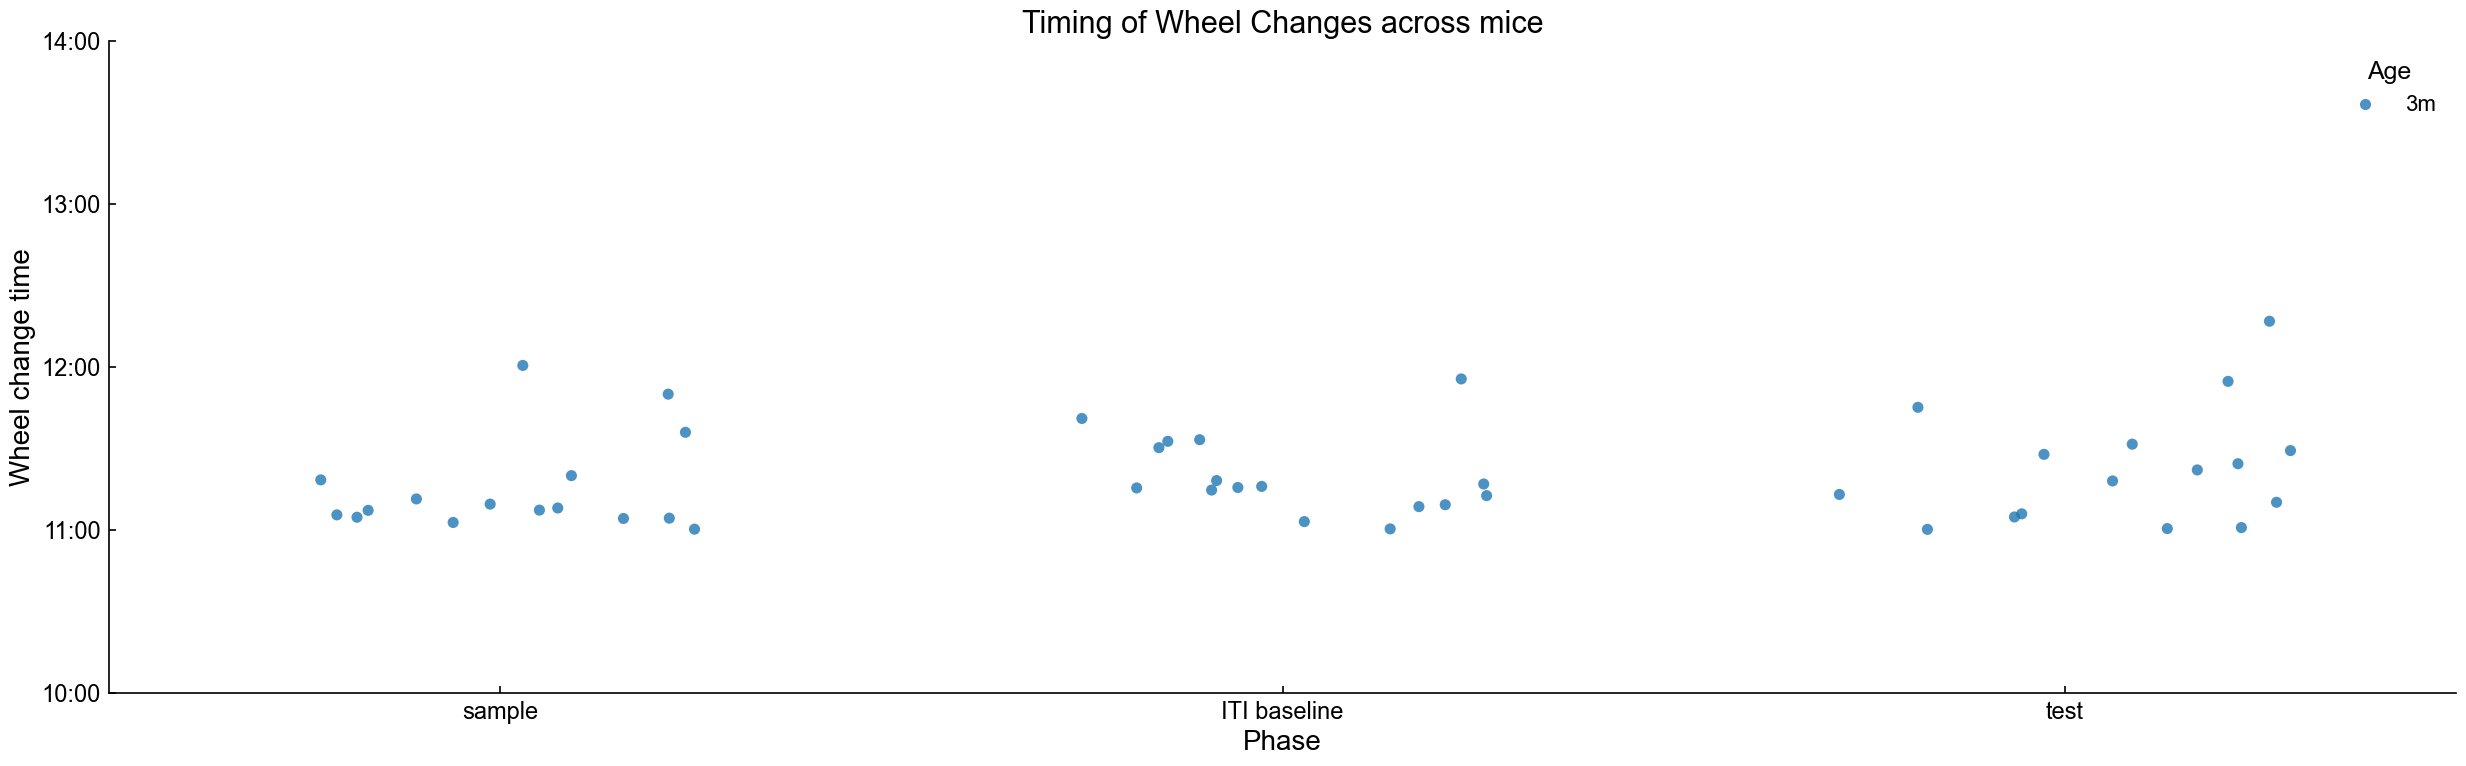

In [12]:
# Wheel change timing QC plot

wheel_times = events.copy()

wheel_times["rotation"] = pd.to_datetime(wheel_times["rotation"])
wheel_times["clock_time"] = (
    wheel_times["rotation"].dt.hour
    + wheel_times["rotation"].dt.minute / 60
    + wheel_times["rotation"].dt.second / 3600
)

wheel_times["Phase"] = wheel_times["Phase"].replace({
    "ITI_baseline": "ITI baseline",
    "post_trial_baseline": "Post-trial baseline"
})

fig, ax = plt.subplots(figsize=(WIDE_W, FIG_H))

sns.stripplot(
    data=wheel_times,
    x="Phase",
    y="clock_time",
    hue="Age",
    order=[
        "sample",
        "ITI baseline",
        "test"
    ],
    hue_order=AGE_ORDER,
    dodge=True,
    jitter=0.3,
    size=8,
    alpha=0.8,
    ax=ax
)

format_axes(ax)

ax.set_ylabel("Wheel change time")
ax.set_xlabel("Phase")
ax.set_title("Timing of Wheel Changes across mice")

ax.set_yticks([10, 11, 12, 13, 14])
ax.set_yticklabels(["10:00", "11:00", "12:00", "13:00", "14:00"])

ax.legend(
    title="Age",
    frameon=False
)

plt.tight_layout()
save_figure_pdf()
plt.show()


# Total exploration 

This plot compares total exploration for each phase.



In [13]:
phase_total = (
    main_binned
    .groupby(["MouseSessionID", "KageID", "Cohort", "Age", "Genotype", "Phase"], as_index=False)["total_sec"]
    .sum()
)

phase_total.head()

,MouseSessionID,KageID,Cohort,Age,Genotype,Phase,total_sec
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,ITI_baseline,447.0
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,661.5
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,test,435.0
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,ITI_baseline,681.5
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,1614.5


/var/folders/yn/k4f882yj71xg0t4j81qfm7pw0000gn/T/ipykernel_95807/4166178088.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([clean_phase_label(x.get_text()) for x in ax.get_xticklabels()], rotation=20, ha="right")


Saved PDF: 002_Total_Exploration.pdf


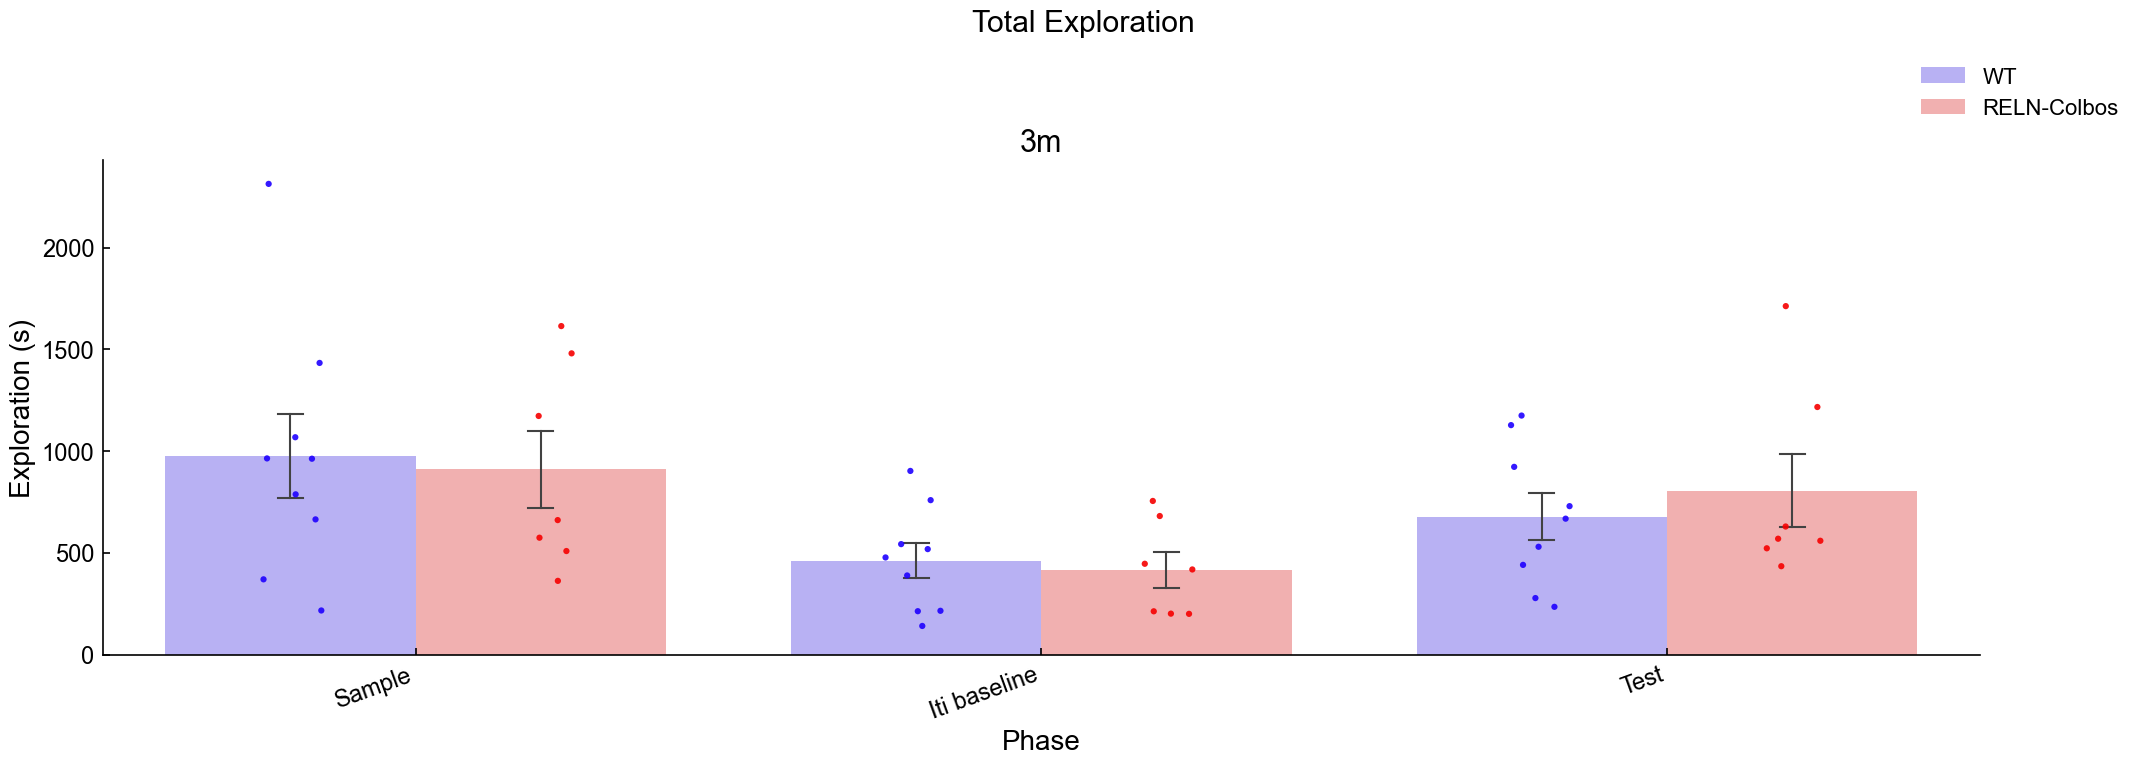

In [14]:
def plot_total_exploration_by_age(phase_total):
    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(22, 7.5), sharey=True)
    axes = np.atleast_1d(axes) 

    for ax, age in zip(axes, AGE_ORDER):
        sub = phase_total[phase_total["Age"] == age].copy()

        sns.barplot(
            data=sub,
            x="Phase",
            y="total_sec",
            hue="Genotype",
            order=PHASE_ORDER,
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            errorbar="se",
            capsize=0.08,
            err_kws={"linewidth": 1.5},
            alpha=0.35,
            ax=ax
        )

        sns.stripplot(
            data=sub,
            x="Phase",
            y="total_sec",
            hue="Genotype",
            order=PHASE_ORDER,
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            dodge=True,
            size=4.5,
            alpha=0.9,
            ax=ax
        )

        format_axes(ax)
        ax.set_title(age)
        ax.set_xlabel("Phase")
        ax.set_ylabel("Exploration (s)" if age == AGE_ORDER[0] else "")
        ax.set_xticklabels([clean_phase_label(x.get_text()) for x in ax.get_xticklabels()], rotation=20, ha="right")

        # remove duplicate legends inside each subplot
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles[:len(GENO_ORDER)],
        labels[:len(GENO_ORDER)],
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98)
    )

    fig.suptitle("Total Exploration", y=1.03)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    save_figure_pdf()
plt.show()

plot_total_exploration_by_age(phase_total)


# Average exploration over time

These are exploration-rate plots.

- 4-hour: `0-240 min`
- 24-hour: `0-1440 min`

The average is calculated separately within each age, genotype, phase and time bin.

In [15]:
def plot_phase_rows_for_one_age(
    summary_df,
    age,
    y_label,
    title,
    cutoff_min,
    sigma=0.5
):
    fig, axes = plt.subplots(
        len(PHASE_ORDER),
        1,
        figsize=(WIDE_W, WIDE_H),
        sharex=True,
        sharey=True
    )

    age_df = summary_df[
        summary_df["Age"] == age
    ].copy()

    for ax, phase in zip(axes, PHASE_ORDER):

        phase_df = age_df[
            age_df["Phase"] == phase
        ].copy()

        for genotype in GENO_ORDER:

            temp = phase_df[
                phase_df["Genotype"] == genotype
            ].sort_values("time_min")

            if temp.empty:
                continue

            y = gaussian_filter1d(
                temp["mean_value"].values,
                sigma=sigma
            )

            sem = gaussian_filter1d(
                temp["sem_value"].fillna(0).values,
                sigma=sigma
            )

            ax.plot(
                temp["time_min"],
                y,
                color=GENO_COLORS[genotype],
                label=genotype,
                linewidth=2
            )

            ax.fill_between(
                temp["time_min"],
                y - sem,
                y + sem,
                color=GENO_COLORS[genotype],
                alpha=0.2
            )

        format_axes(ax)

        ax.set_title(phase.replace("_", " ").capitalize())
        ax.set_ylabel(y_label)

    axes[-1].set_xlabel("Time from wheel change (min)")
    axes[-1].set_xlim(0, cutoff_min)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98)
    )

    fig.suptitle(f"{title} ({age})", y=1.02)

    plt.tight_layout()
    save_figure_pdf()
plt.show()

In [16]:
avg_4h_binned = rebin_timeseries(
    main_binned,
    value_cols=["total_sec"],
    bin_factor=1,
    cutoff_min=240
)

avg_4h_summary = summarise_timeseries(
    avg_4h_binned,
    "total_sec"
)

Saved PDF: 003_Average_exploration_over_4_hours_3m.pdf


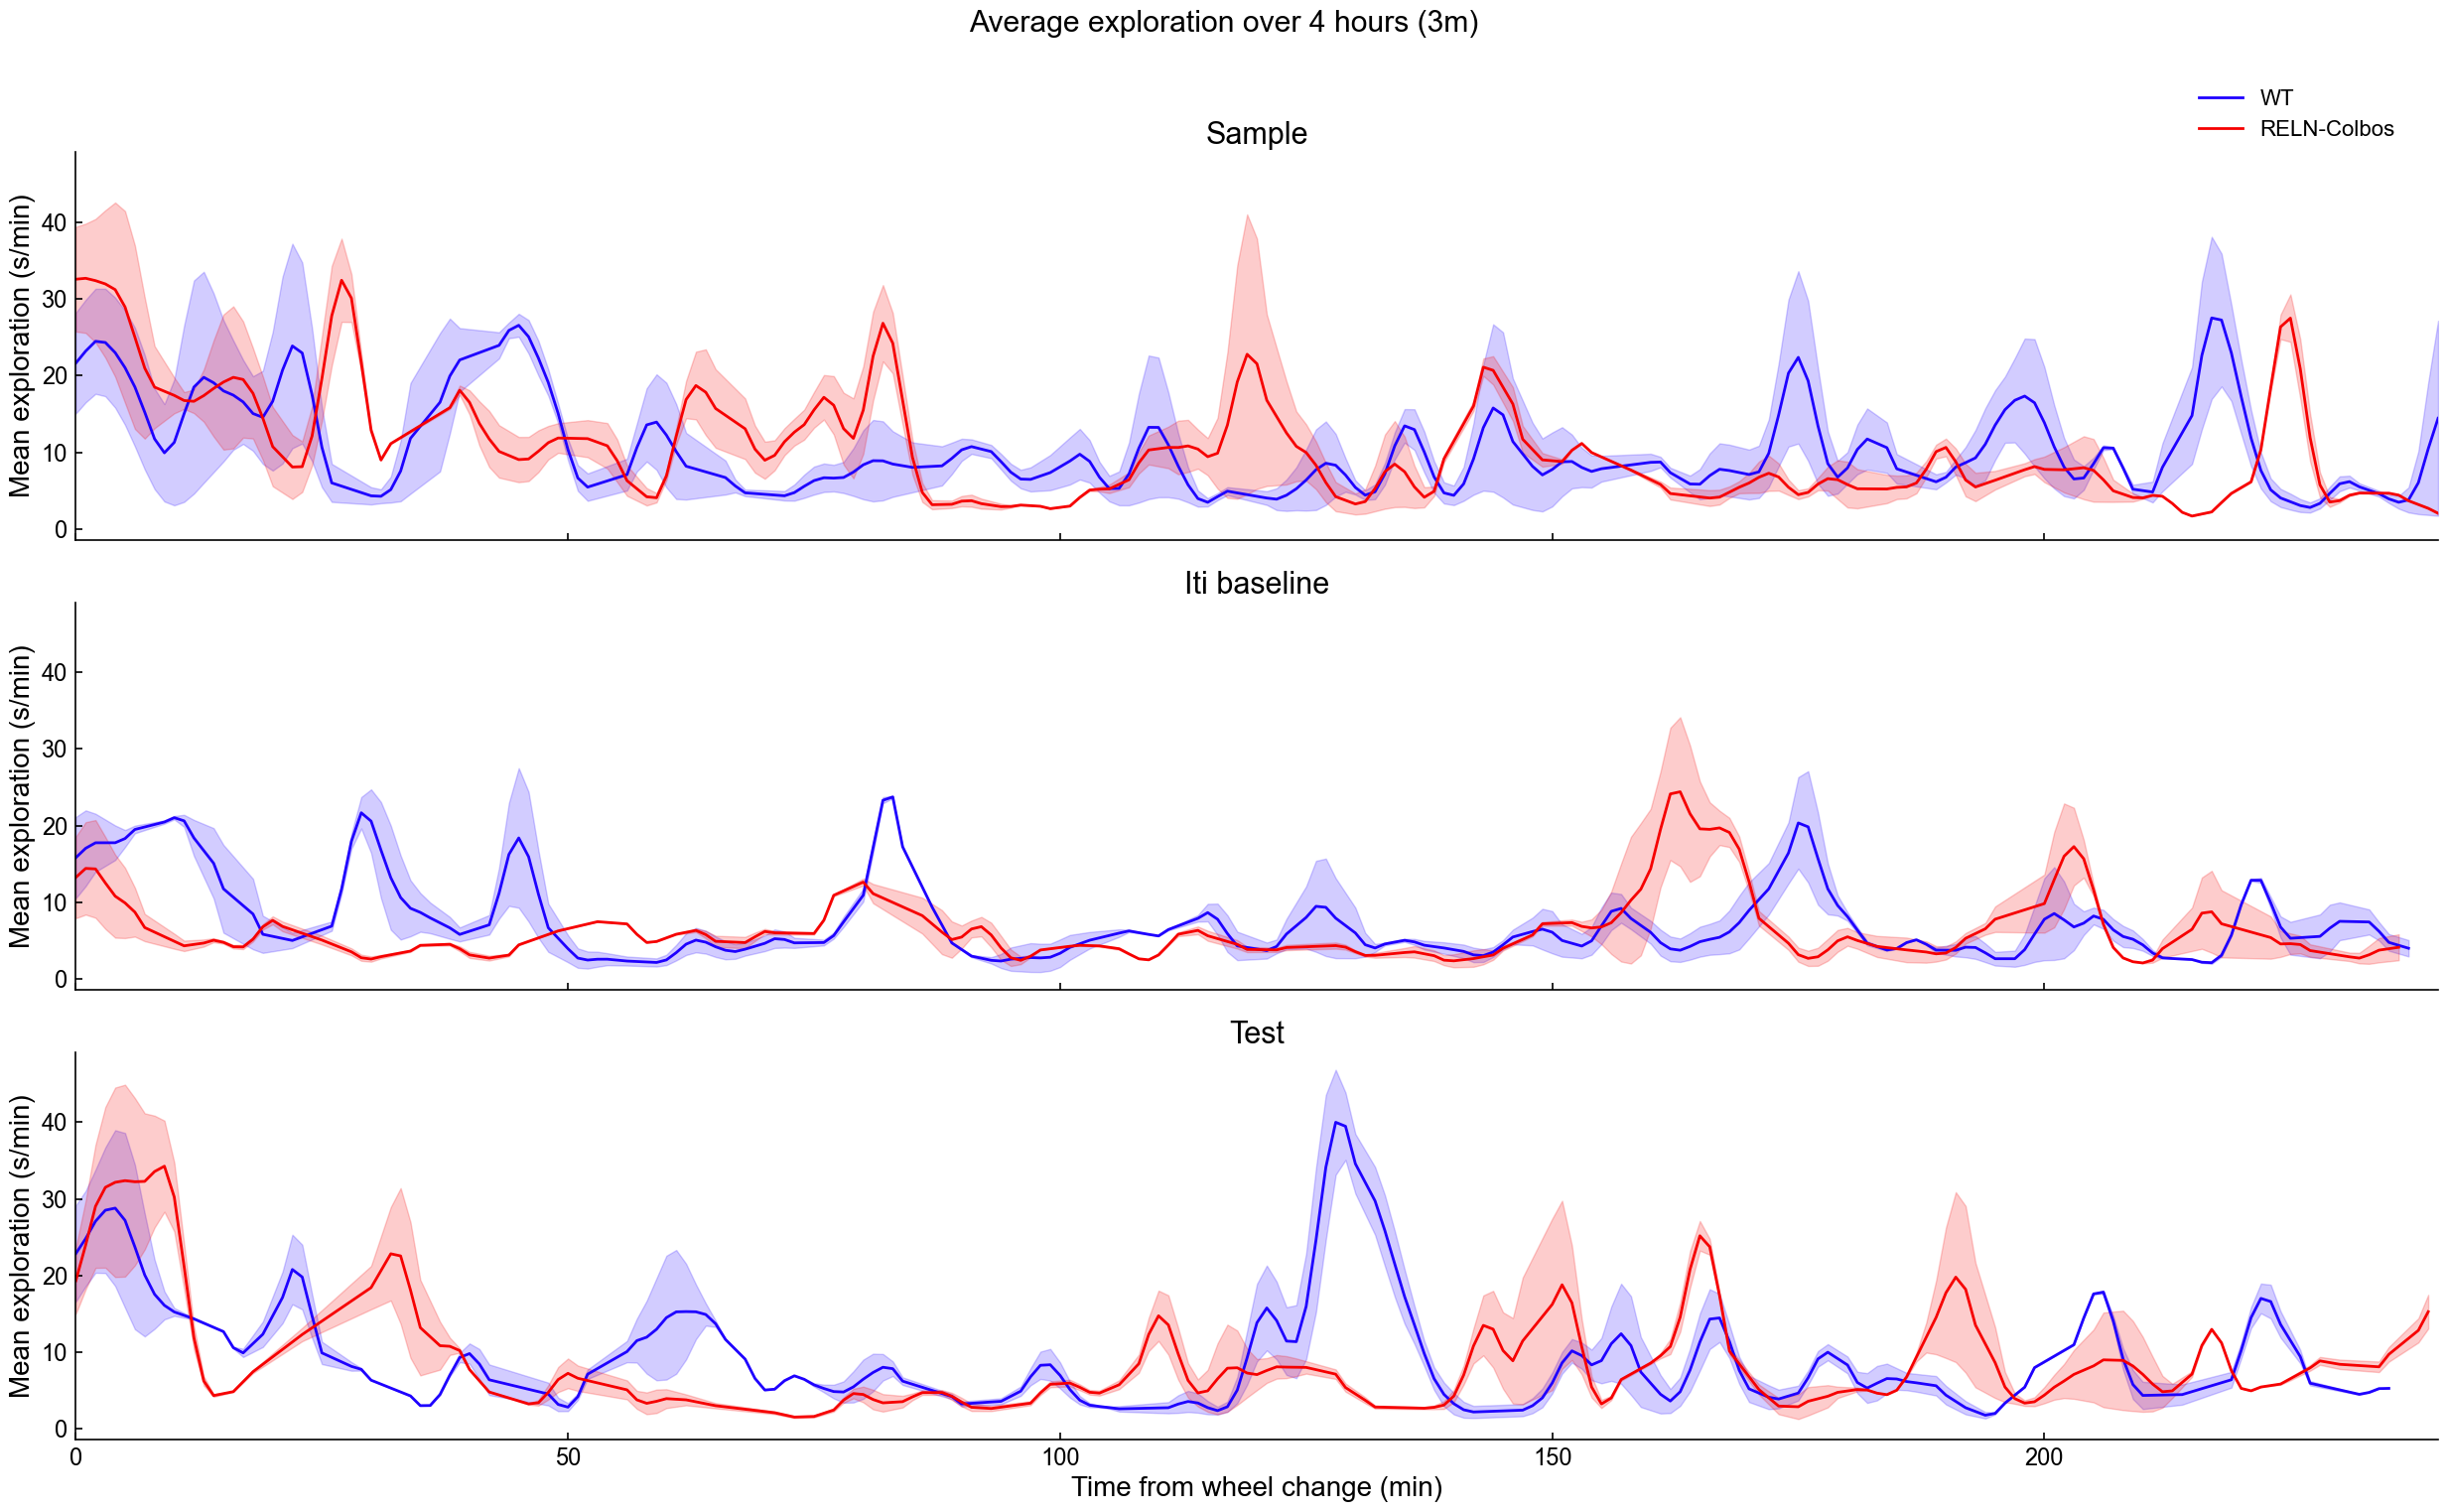

In [17]:
for age in AGE_ORDER:
    plot_phase_rows_for_one_age(
        avg_4h_summary,
        age=age,
        y_label="Mean exploration (s/min)",
        title="Average exploration over 4 hours",
        cutoff_min=240,
        sigma=SMOOTH_SIGMA
    )

In [18]:
avg_8h_binned = rebin_timeseries(
    main_binned,
    value_cols=["total_sec"],
    bin_factor=1,
    cutoff_min=480
)

avg_8h_summary = summarise_timeseries(
    avg_8h_binned,
    "total_sec"
)

Saved PDF: 004_Average_exploration_over_8_hours_3m.pdf


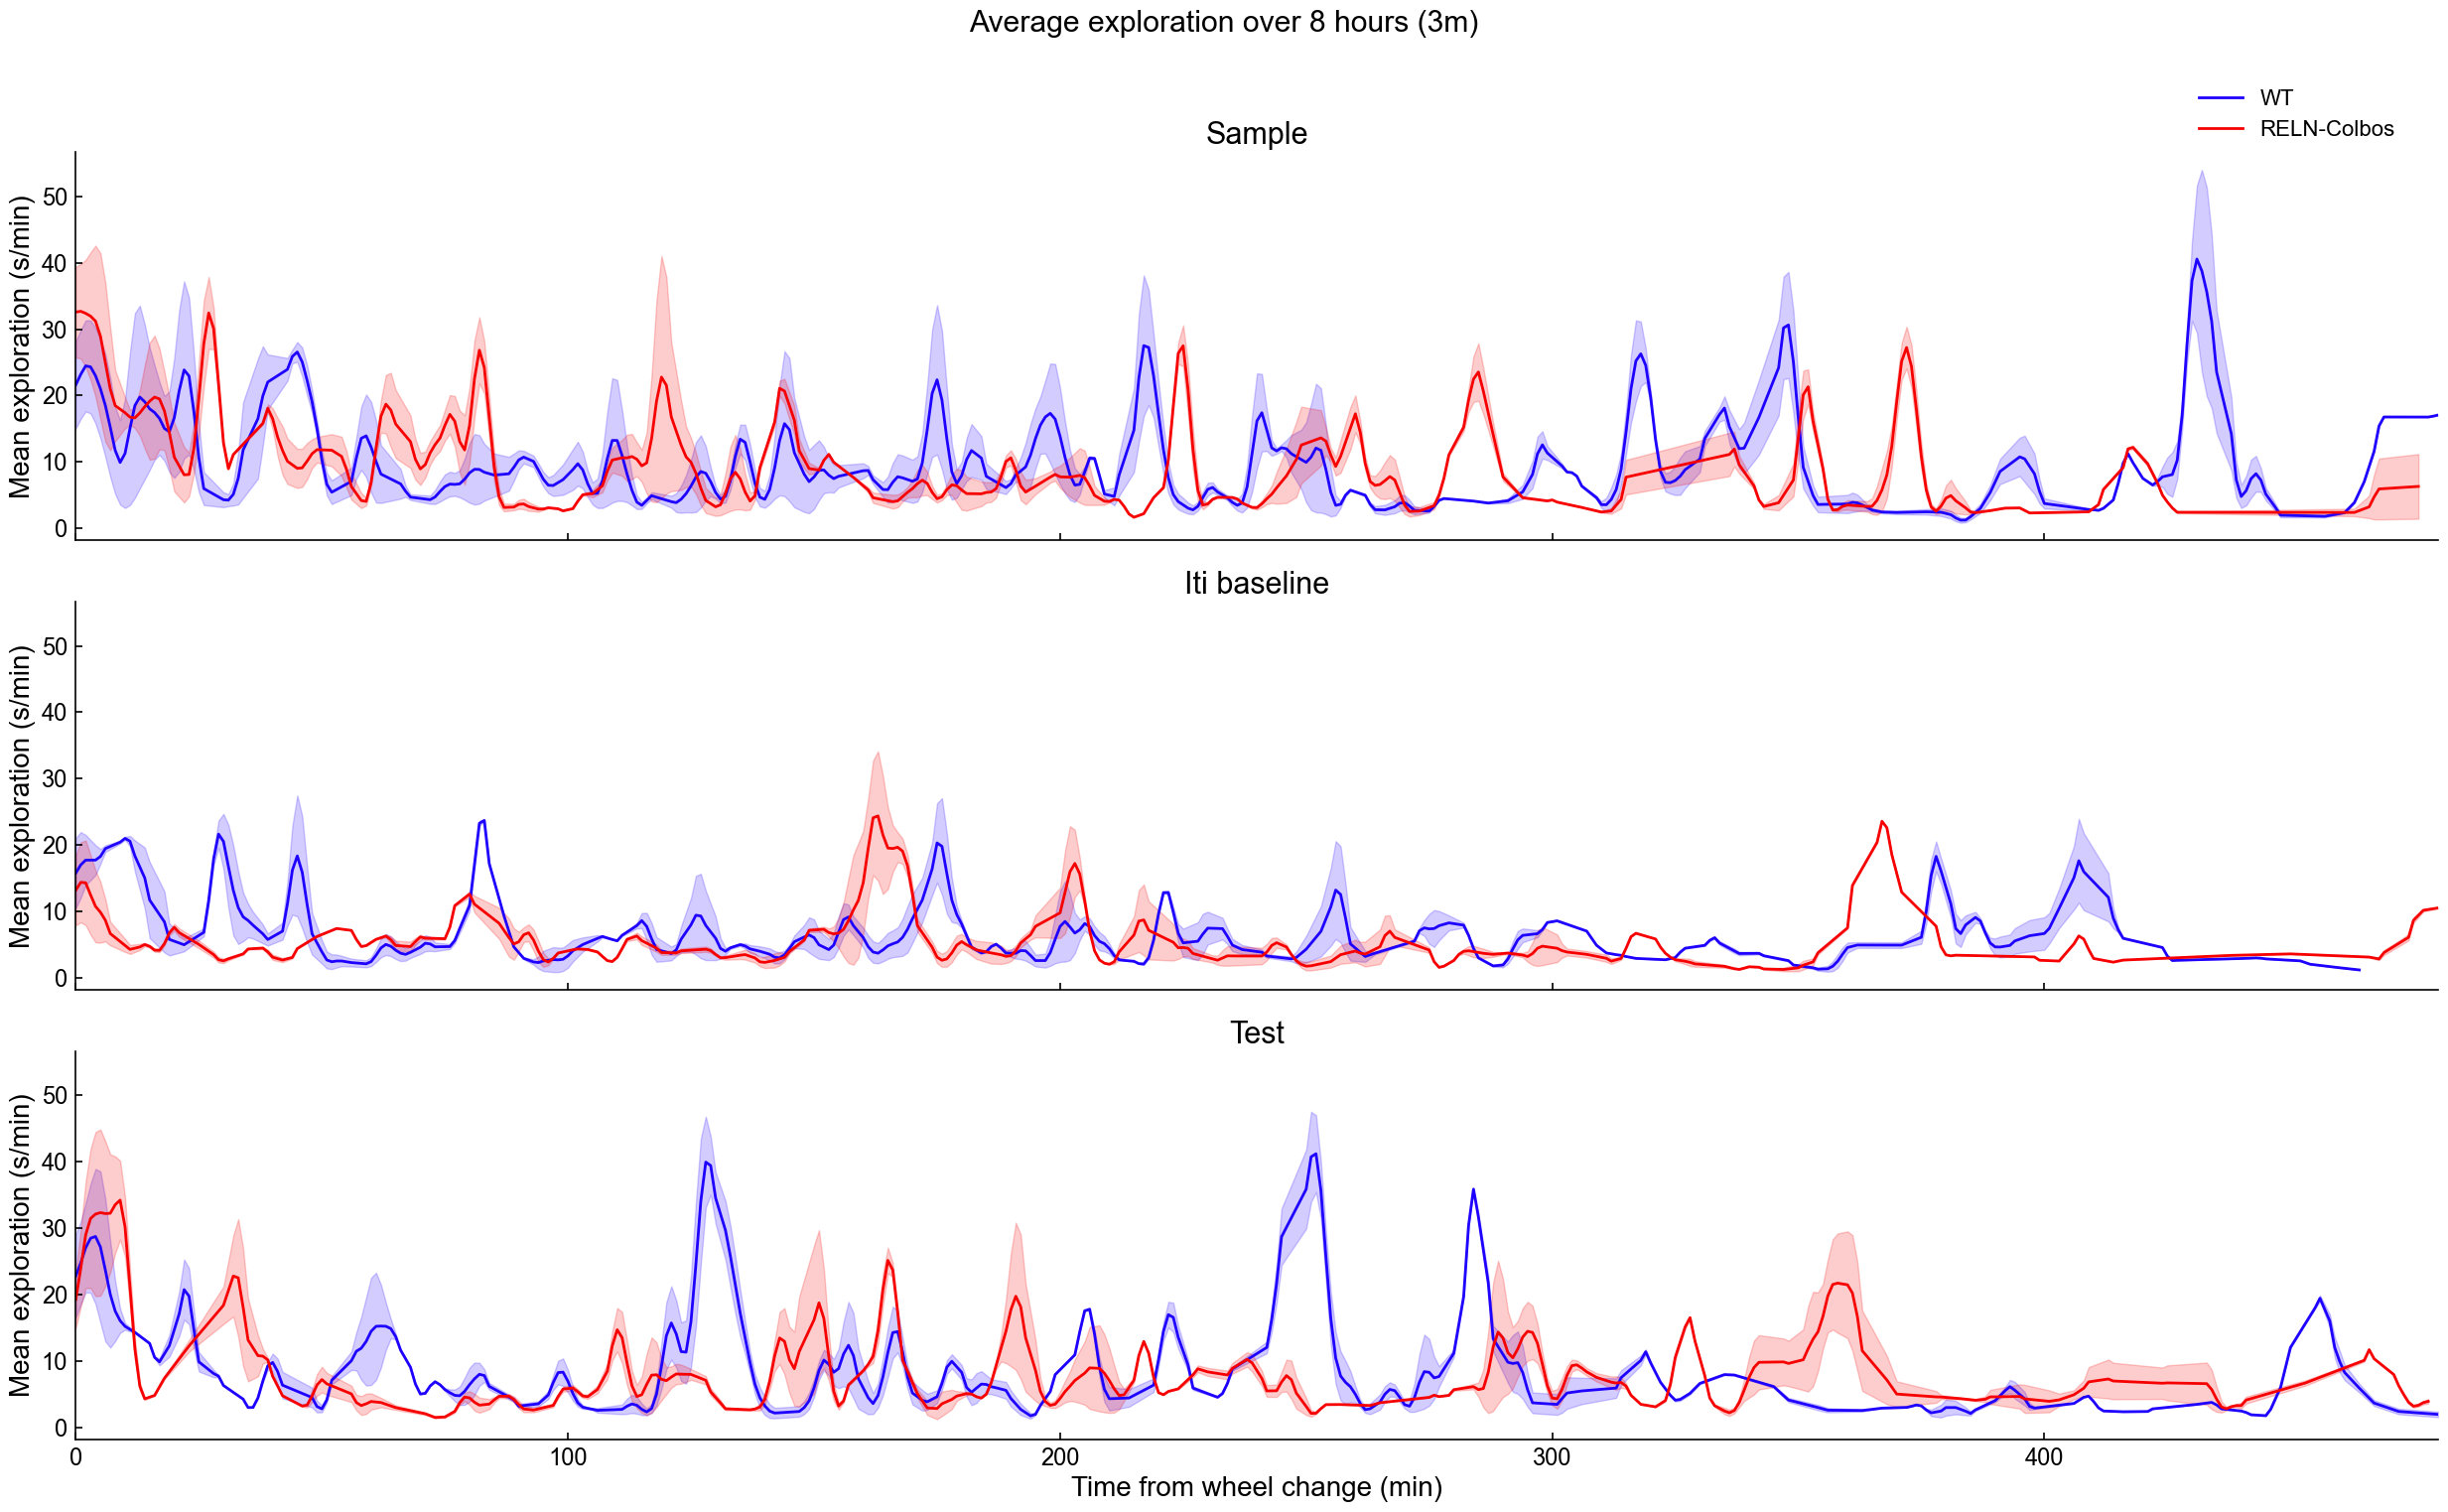

In [19]:
for age in AGE_ORDER:
    plot_phase_rows_for_one_age(
        avg_8h_summary,
        age=age,
        y_label="Mean exploration (s/min)",
        title="Average exploration over 8 hours",
        cutoff_min=480,
        sigma=SMOOTH_SIGMA
    )

In [20]:
avg_24h_binned = rebin_timeseries(
    main_binned,
    value_cols=["total_sec"],
    bin_factor=1,
    cutoff_min=1440
)

avg_24h_summary = summarise_timeseries(
    avg_24h_binned,
    "total_sec"
)

Saved PDF: 005_Average_exploration_over_24-hours_3m.pdf


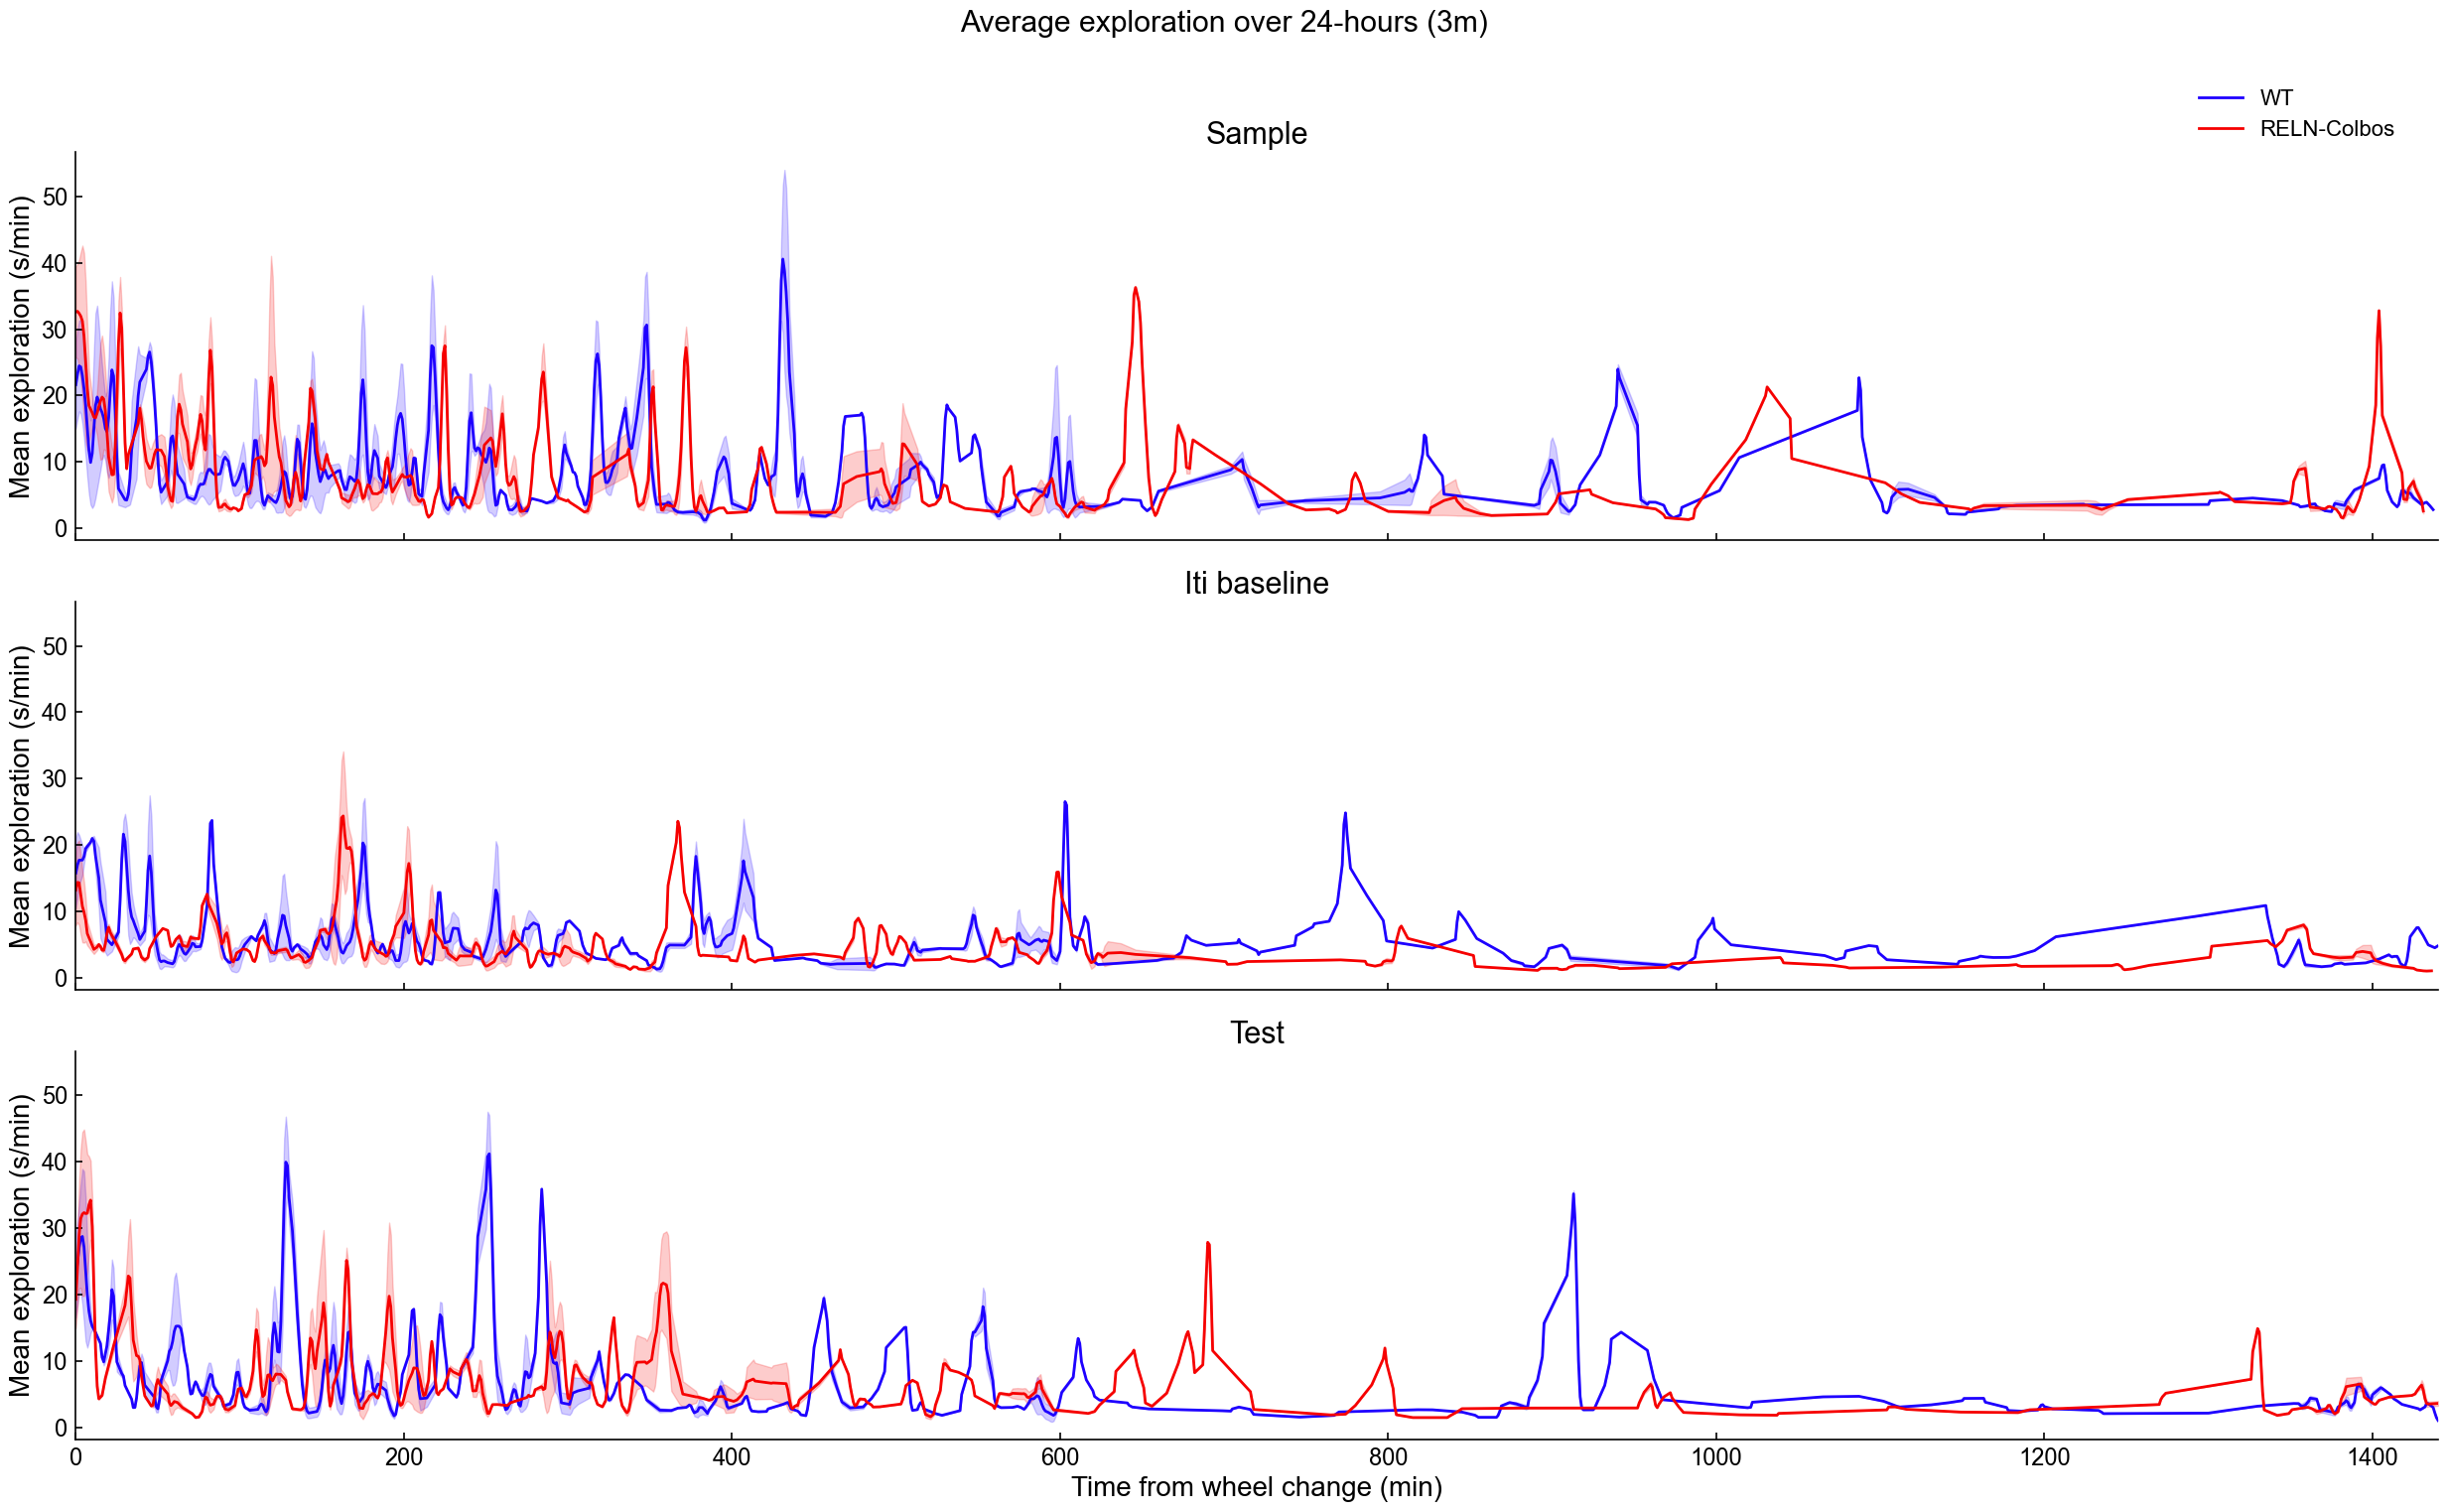

In [21]:
for age in AGE_ORDER:
    plot_phase_rows_for_one_age(
        avg_24h_summary,
        age=age,
        y_label="Mean exploration (s/min)",
        title="Average exploration over 24-hours",
        cutoff_min=1440,
        sigma=SMOOTH_SIGMA
    )

Saved PDF: 006_Average_exploration_over_time_4_h.pdf


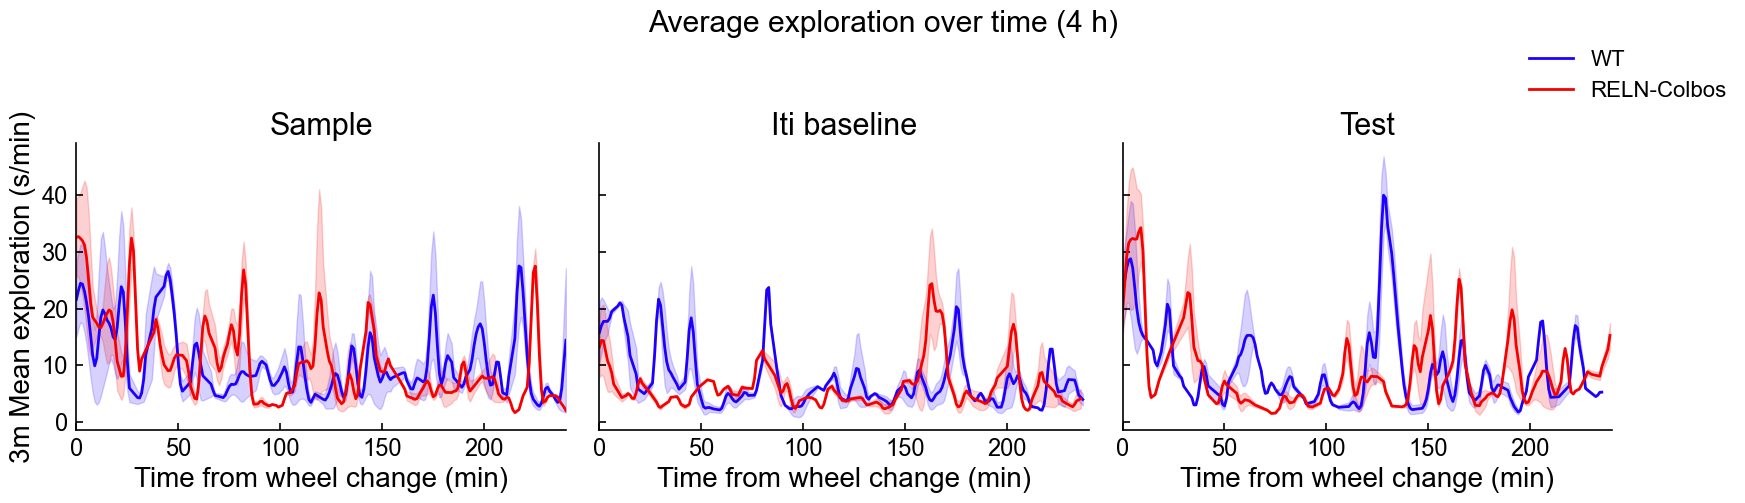

In [22]:
# Average exploration: 4 h
avg_4h_binned = rebin_timeseries(
    main_binned,
    value_cols=["total_sec"],
    bin_factor=1,
    cutoff_min=240
)

avg_4h_summary = summarise_timeseries(avg_4h_binned, "total_sec")

plot_age_phase_grid(
    avg_4h_summary,
    y_label=" Mean exploration (s/min)",
    title="Average exploration over time (4 h)",
    cutoff_min=240,
    sigma=SMOOTH_SIGMA
)


Saved PDF: 007_Average_exploration_over_time_24_h.pdf


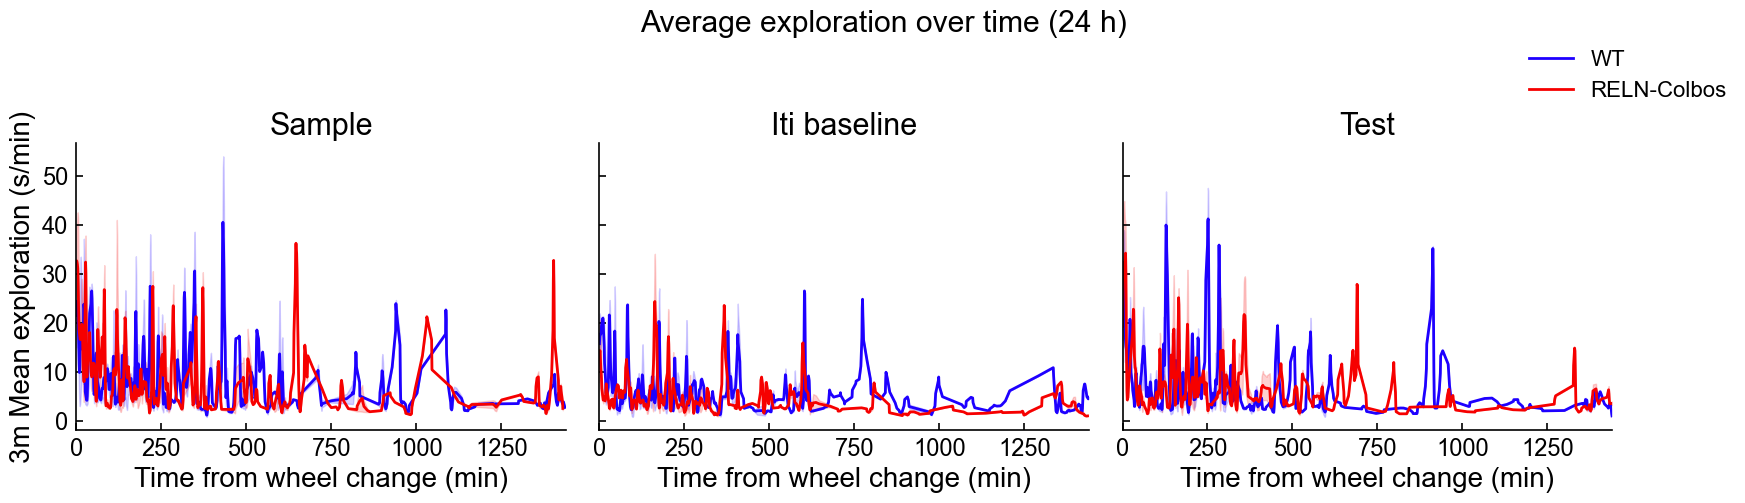

In [23]:
# Average exploration: 24 h
avg_24h_binned = rebin_timeseries(
    main_binned,
    value_cols=["total_sec"],
    bin_factor=1,
    cutoff_min=1440
)

avg_24h_summary = summarise_timeseries(avg_24h_binned, "total_sec")

plot_age_phase_grid(
    avg_24h_summary,
    y_label=" Mean exploration (s/min)",
    title="Average exploration over time (24 h)",
    cutoff_min=1440,
    sigma=SMOOTH_SIGMA
)


# Cumulative exploration

Cumulative exploration is recomputed from `total_sec`. This avoids drops in the curve when different mice have different phase lengths.

- 2 h cumulative exploration
- 24 h cumulative exploration


In [24]:
def make_cumulative_filled_master(data, cutoff_min=1440):
    full_bins = range(0, cutoff_min + 1)

    filled = []

    for (mouse, phase), df in data.groupby(["MouseSessionID", "Phase"]):

        df = df[df["time_min"] <= cutoff_min].copy()

        df["time_min"] = pd.to_numeric(df["time_min"], errors="coerce")
        df["cumulative_total_sec"] = pd.to_numeric(
            df["cumulative_total_sec"],
            errors="coerce"
        )

        df = df.dropna(subset=["time_min", "cumulative_total_sec"])

        meta = df.iloc[0][
            ["MouseSessionID", "KageID", "Cohort", "Age", "Genotype", "Phase"]
        ]

        df = (
            df
            .groupby("time_min", as_index=False)
            .agg(
                cumulative_total_sec=("cumulative_total_sec", "max")
            )
        )

        df = df.set_index("time_min").reindex(full_bins)

        for col in meta.index:
            df[col] = meta[col]

        df["cumulative_total_sec"] = (
            df["cumulative_total_sec"]
            .ffill()
            .fillna(0)
        )

        filled.append(df.reset_index())

    return pd.concat(filled, ignore_index=True)

In [25]:
# Make the full 24 h filled cumulative table once
binned_filled_24h = make_cumulative_filled_master(
    main_binned,
    cutoff_min=1440
)

binned_filled_2h = binned_filled_24h[
    binned_filled_24h["time_min"] <= 120
].copy()

cum_2h_summary = (
    binned_filled_2h
    .groupby(["Age", "Genotype", "Phase", "time_min"], as_index=False)
    .agg(
        mean_value=("cumulative_total_sec", "mean"),
        sem_value=("cumulative_total_sec", lambda x: x.sem())
    )
)

Saved PDF: 008_Cumulative_exploration_over_2_hours.pdf


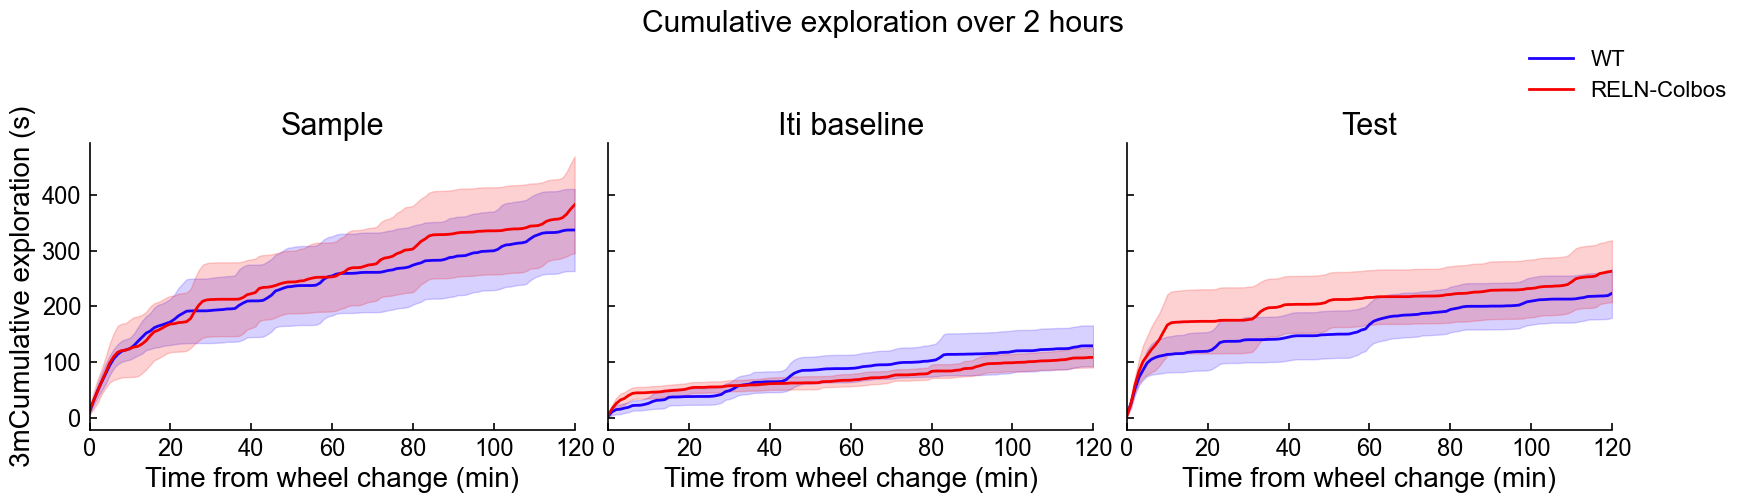

In [26]:
plot_age_phase_grid(
    cum_2h_summary,
    y_label="Cumulative exploration (s)",
    title="Cumulative exploration over 2 hours",
    cutoff_min=120,
    sigma=0.5
)

In [27]:
binned_filled_10h = binned_filled_24h[
    binned_filled_24h["time_min"] <= 600
].copy()

cum_10h_summary = (
    binned_filled_10h
    .groupby(["Age", "Genotype", "Phase", "time_min"], as_index=False)
    .agg(
        mean_value=("cumulative_total_sec", "mean"),
        sem_value=("cumulative_total_sec", lambda x: x.sem())
    )
)

Saved PDF: 009_Cumulative_exploration_over_10_hours.pdf


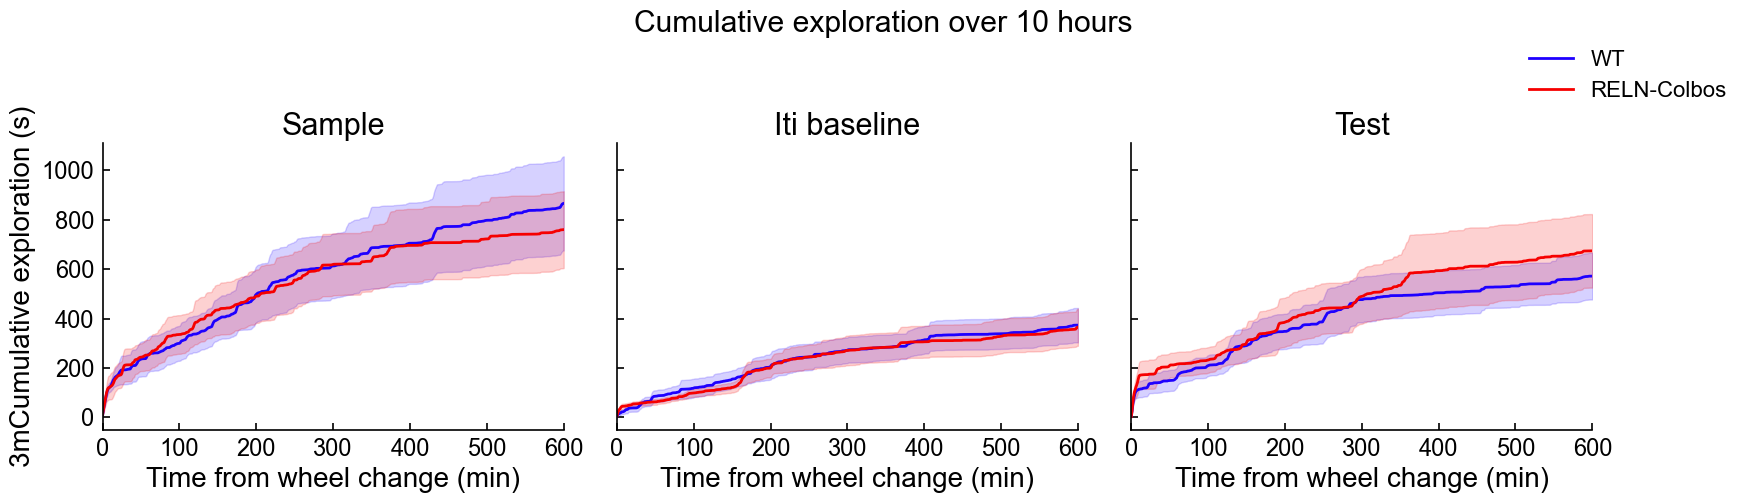

In [28]:
plot_age_phase_grid(
    cum_10h_summary,
    y_label="Cumulative exploration (s)",
    title="Cumulative exploration over 10 hours",
    cutoff_min=600,
    sigma=0.5
)

Saved PDF: 010_Cumulative_exploration_over_24_hours.pdf


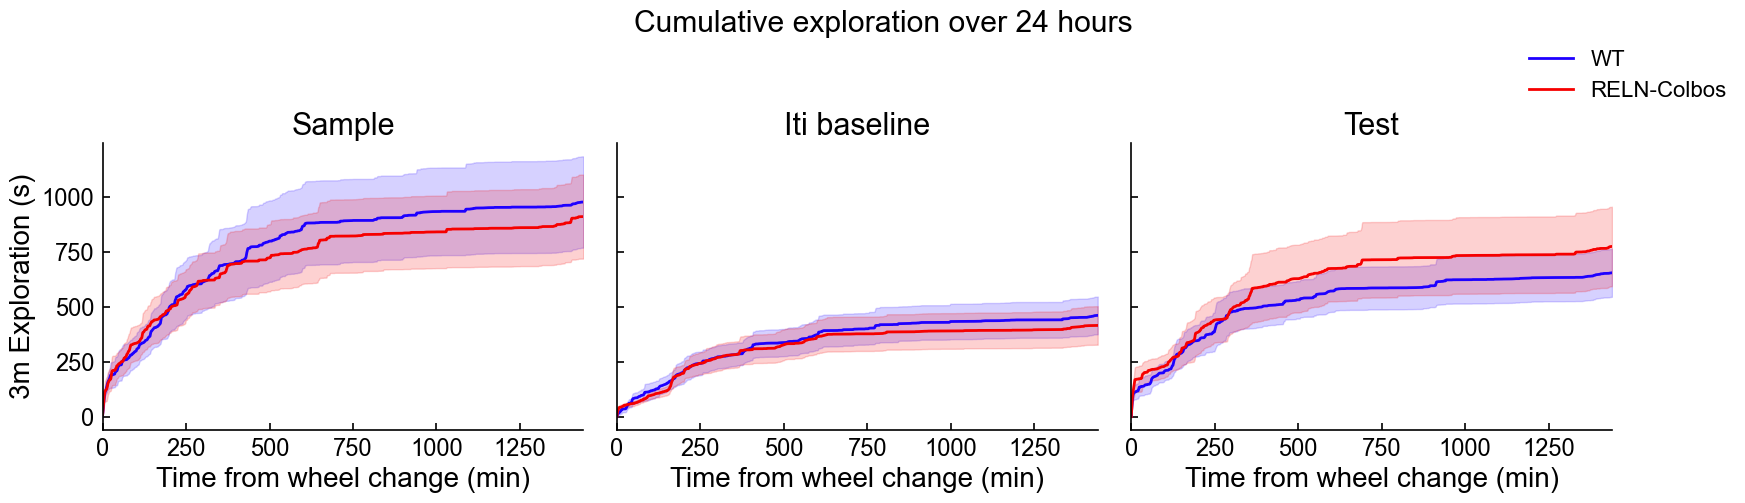

In [29]:
cum_24h_summary = (
    binned_filled_24h
    .groupby(["Age", "Genotype", "Phase", "time_min"], as_index=False)
    .agg(
        mean_value=("cumulative_total_sec", "mean"),
        sem_value=("cumulative_total_sec", lambda x: x.sem())
    )
)

plot_age_phase_grid(
    cum_24h_summary,
    y_label=" Exploration (s)",
    title="Cumulative exploration over 24 hours",
    cutoff_min=1440,
    sigma=0.5
)

# Novel/Familiar & Left/Right Discrimination Index

For test phase only:

- `NOR_side = L` means left side is novel.
- `NOR_side = R` means right side is novel.

DI is calculated at the mouse/session level first, then averaged by age and genotype.

Two DI measures are generated:

1. Novel/familiar DI

`(Novel - Familiar) / (Novel + Familiar)`

2. Side-bias DI

`(Left - Right) / (Left + Right)`


In [30]:
def make_test_di_table(data, cutoff_min=120, bin_factor=1):
    test = data[data["Phase"] == "test"].copy()

    needed = ["left_sec", "right_sec", "NOR_side"]
    missing = [c for c in needed if c not in test.columns]
    if missing:
        raise ValueError(f"Missing required columns for DI: {missing}")

    test = rebin_timeseries(
        test,
        value_cols=["left_sec", "right_sec"],
        bin_factor=bin_factor,
        cutoff_min=cutoff_min
    )

    # rebin_timeseries drops NOR_side, so bring it back per MouseSessionID
    meta_cols = ["MouseSessionID", "NOR_side"]
    meta = data[data["Phase"] == "test"][meta_cols].drop_duplicates("MouseSessionID")
    test = test.merge(meta, on="MouseSessionID", how="left")

    side = test["NOR_side"].astype(str).str.upper().str[0]

    test["novel_sec"] = np.where(side == "L", test["left_sec"], test["right_sec"])
    test["familiar_sec"] = np.where(side == "L", test["right_sec"], test["left_sec"])

    test["novel_familiar_total"] = test["novel_sec"] + test["familiar_sec"]
    test["left_right_total"] = test["left_sec"] + test["right_sec"]

    test["DI"] = np.where(
        test["novel_familiar_total"] > 0,
        (test["novel_sec"] - test["familiar_sec"]) / test["novel_familiar_total"],
        np.nan
    )

    test["side_bias_DI"] = np.where(
        test["left_right_total"] > 0,
        (test["left_sec"] - test["right_sec"]) / test["left_right_total"],
        np.nan
    )

    return test


def summarise_di(di_table, value_col):
    return (
        di_table
        .groupby(["Age", "Genotype", "time_min"], as_index=False)
        .agg(
            mean_value=(value_col, "mean"),
            sem_value=(value_col, sem),
            n=(value_col, "count")
        )
    )


def plot_di_by_age(di_summary, title, cutoff_min, y_label="DI", sigma=2):
    fig, axes = plt.subplots(len(AGE_ORDER), 1, figsize=(10, 5), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, age in zip(axes, AGE_ORDER):
        sub = di_summary[di_summary["Age"] == age].copy()

        for genotype in GENO_ORDER:
            temp = sub[sub["Genotype"] == genotype].sort_values("time_min")
            if temp.empty:
                continue

            y = gaussian_filter1d(temp["mean_value"].values, sigma=2)
            e = gaussian_filter1d(temp["sem_value"].fillna(0).values, sigma=2)

            ax.plot(
                temp["time_min"],
                y,
                color=GENO_COLORS.get(genotype, "black"),
                label=genotype,
                linewidth=2
            )

            ax.fill_between(
                temp["time_min"],
                y - e,
                y + e,
                color=GENO_COLORS.get(genotype, "black"),
                alpha=0.18
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        format_axes(ax)
        ax.set_xlim(0, cutoff_min)
        ax.set_ylim(-1, 1)
        ax.set_ylabel(f"{age}{y_label}")

    axes[-1].set_xlabel("Time from test wheel change (min)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.90, 0.98])
    save_figure_pdf()
plt.show()


Saved PDF: 011_Novelfamiliar_DI_120_min.pdf
Saved PDF: 012_Novelfamiliar_DI_600_min.pdf
Saved PDF: 013_Novelfamiliar_DI_1440_min.pdf


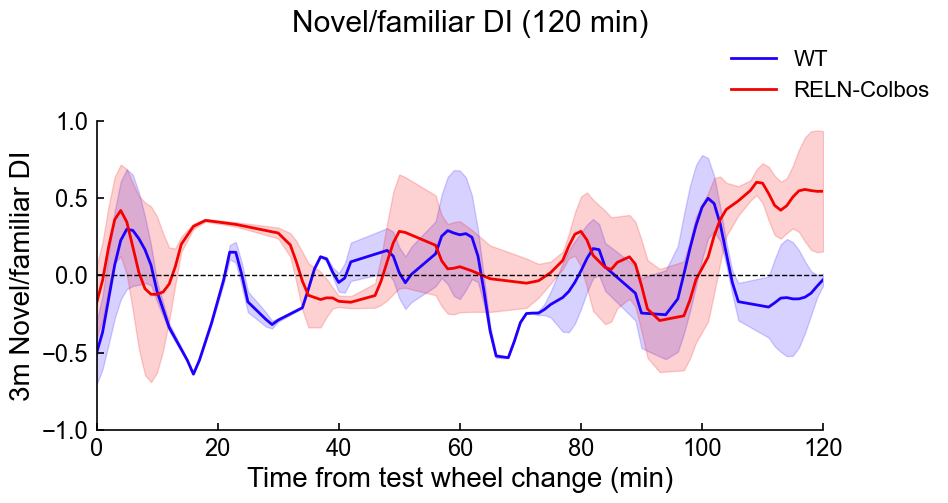

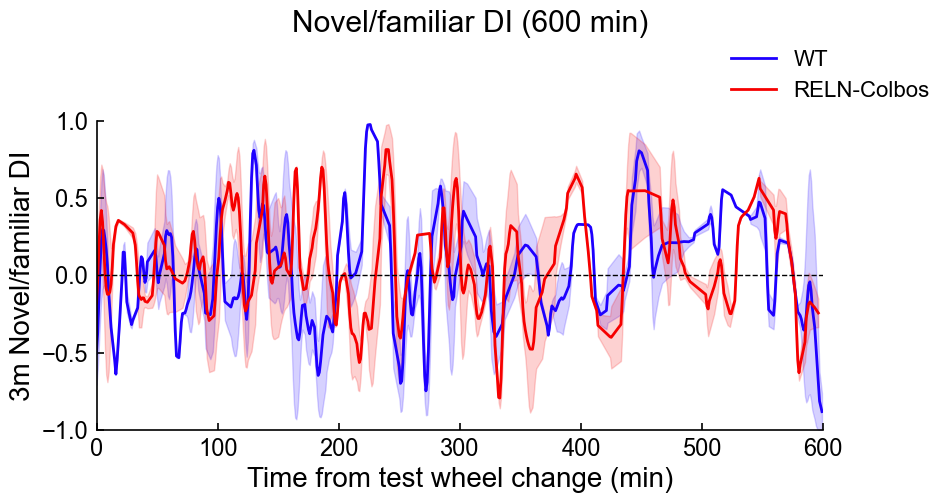

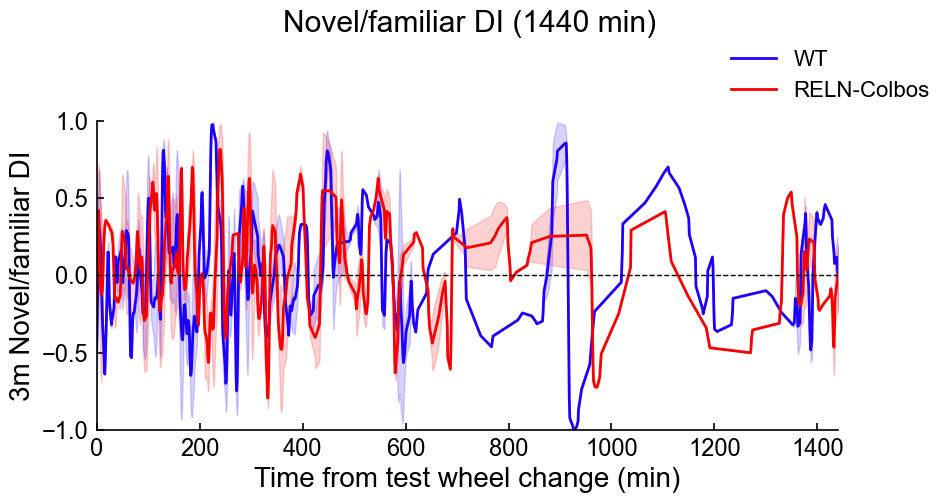

In [31]:
# Novel/familiar DI: 2 h, 10 h, 24 h
for cutoff in [120, 600, 1440]:
    di_table = make_test_di_table(main_binned, cutoff_min=cutoff, bin_factor=1)
    di_summary = summarise_di(di_table, "DI")
    plot_di_by_age(
        di_summary,
        title=f"Novel/familiar DI ({cutoff} min)",
        cutoff_min=cutoff,
        y_label=" Novel/familiar DI",
        sigma=2
    )


Saved PDF: 014_Side-bias_DI_120_min.pdf
Saved PDF: 015_Side-bias_DI_600_min.pdf
Saved PDF: 016_Side-bias_DI_1440_min.pdf


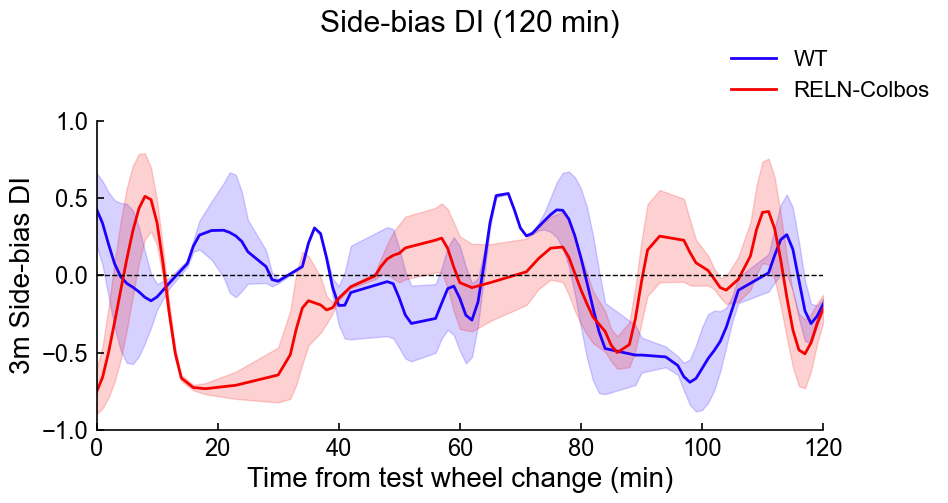

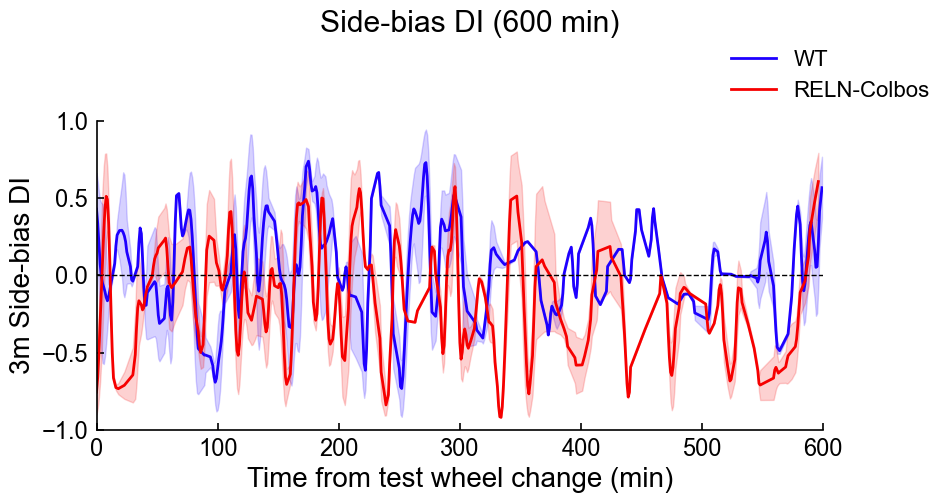

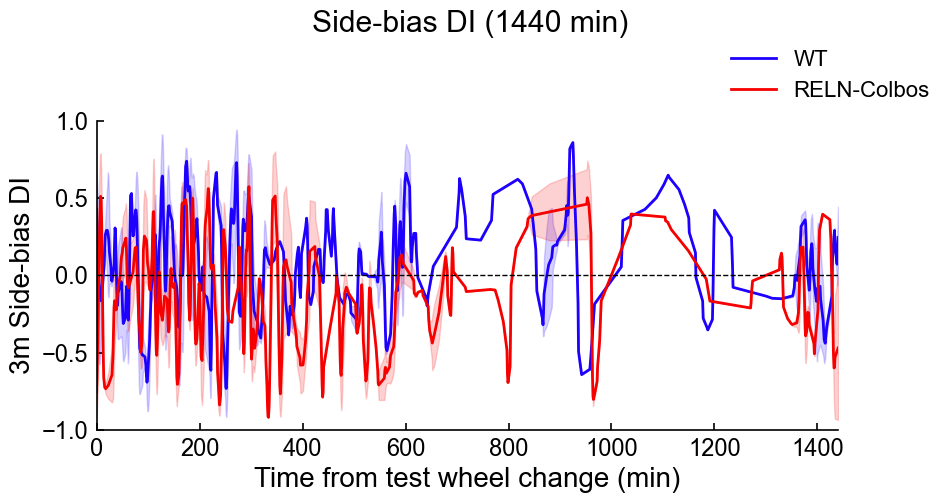

In [32]:
# Side-bias DI: 2 h, 10 h, 24 h
for cutoff in [120, 600, 1440]:
    side_table = make_test_di_table(main_binned, cutoff_min=cutoff, bin_factor=1)
    side_summary = summarise_di(side_table, "side_bias_DI")
    plot_di_by_age(
        side_summary,
        title=f"Side-bias DI ({cutoff} min)",
        cutoff_min=cutoff,
        y_label=" Side-bias DI",
        sigma=2
    )


In [33]:
DI_TIMEPOINTS = [120, 240, 360, 480]  # 2, 4, 6, 8 h

di_timepoint_df = []

for t in DI_TIMEPOINTS:

    temp = di_table[
        di_table["time_min"] <= t
    ].copy()

    summary = (
        temp
        .groupby(["Age", "Genotype", "MouseSessionID"], as_index=False)
        .agg(
            novel_sec=("novel_sec", "sum"),
            familiar_sec=("familiar_sec", "sum")
        )
    )

    summary["DI"] = (
        (summary["novel_sec"] - summary["familiar_sec"]) /
        (summary["novel_sec"] + summary["familiar_sec"])
    )

    summary["timepoint_h"] = t / 60

    di_timepoint_df.append(summary)

di_timepoint_df = pd.concat(di_timepoint_df, ignore_index=True)

di_timepoint_df.head()

,Age,Genotype,MouseSessionID,novel_sec,familiar_sec,DI,timepoint_h
0,3m,RELN-Colbos,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,78.5,33.5,0.401786,2.0
1,3m,RELN-Colbos,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,302.5,199.0,0.206381,2.0
2,3m,RELN-Colbos,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage14,58.5,73.0,-0.110266,2.0
3,3m,RELN-Colbos,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage16,173.0,60.5,0.481799,2.0
4,3m,RELN-Colbos,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage2,171.0,41.0,0.613208,2.0


In [34]:
def plot_di_timepoints_by_age(di_df, age):

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    plot_df = di_df[
        di_df["Age"] == age
    ].copy()

    sns.barplot(
        data=plot_df,
        x="timepoint_h",
        y="DI",
        hue="Genotype",
        hue_order=GENO_ORDER,
        palette=GENO_COLORS,
        errorbar="se",
        capsize=0.1,
        alpha=0.35,
        err_kws={"linewidth":1.5},
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="timepoint_h",
        y="DI",
        hue="Genotype",
        hue_order=GENO_ORDER,
        palette=GENO_COLORS,
        dodge=True,
        size=4,
        alpha=0.9,
        ax=ax
    )

    format_axes(ax)

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel("Time after wheel change (h)")
    ax.set_ylabel("Discrimination index")
    ax.set_title(f"{age} discrimination index")

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:len(GENO_ORDER)],
        labels[:len(GENO_ORDER)],
        frameon=False
    )

    plt.tight_layout()
    save_figure_pdf()
plt.show()

Saved PDF: 017_3m_discrimination_index.pdf


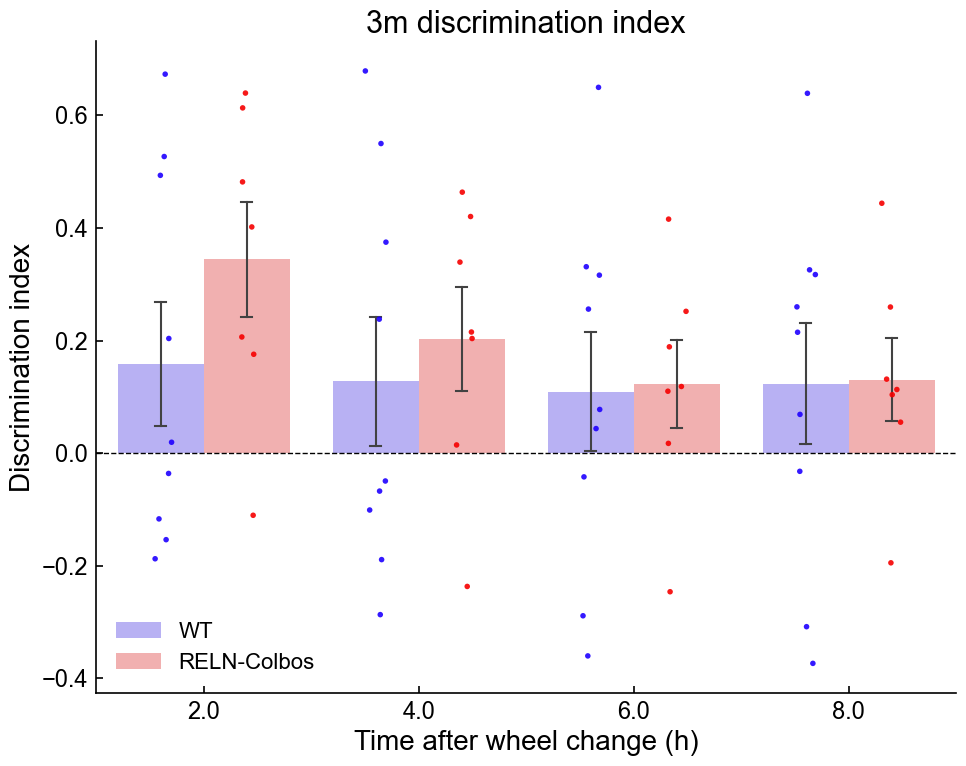

In [35]:
for age in AGE_ORDER:
    plot_di_timepoints_by_age(
        di_timepoint_df,
        age
    )

# Mouse-level DI summaries

These tables are useful for statistics.

They compute one DI per mouse/session over a fixed time window.


In [36]:
def mouse_level_test_di(data, cutoff_min=120):
    di_table = make_test_di_table(data, cutoff_min=cutoff_min, bin_factor=cutoff_min)

    out = di_table[[
        "MouseSessionID", "KageID", "Cohort", "Age", "Genotype",
        "novel_sec", "familiar_sec", "left_sec", "right_sec",
        "DI", "side_bias_DI"
    ]].copy()

    return out

mouse_di_2h = mouse_level_test_di(main_binned, cutoff_min=120)
mouse_di_10h = mouse_level_test_di(main_binned, cutoff_min=600)
mouse_di_24h = mouse_level_test_di(main_binned, cutoff_min=1440)

mouse_di_2h.head()


,MouseSessionID,KageID,Cohort,Age,Genotype,novel_sec,familiar_sec,left_sec,right_sec,DI,side_bias_DI
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,4.5,3.0,3.0,4.5,0.200000,-0.200000
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,0.0,1.5,1.5,0.0,-1.000000,1.000000
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,2.5,0.5,0.5,2.5,0.666667,-0.666667
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,1.0,0.0,0.0,1.0,1.000000,-1.000000
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,0.0,0.5,0.5,0.0,-1.000000,1.000000


# First approach

1. Count of mice choosing novel/familiar first.
2. Percentage of mice choosing novel first.

In [37]:
if first_approach_df is not None:
    for col in ["Age", "Genotype", "FirstApproach"]:
        first_approach_df[col] = first_approach_df[col].astype(str).str.strip()

    first_approach_df["FirstApproach"] = first_approach_df["FirstApproach"].str.lower()
    first_approach_df = first_approach_df[first_approach_df["Age"].isin(AGE_ORDER)].copy()

    first_summary = (
        first_approach_df
        .groupby(["Age", "Genotype", "FirstApproach"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    display(first_summary.head())
else:
    first_summary = None


,Age,Genotype,FirstApproach,count
0,3m,RELN-Colbos,familiar,3
1,3m,RELN-Colbos,novel,4
2,3m,WT,familiar,6
3,3m,WT,novel,3


In [38]:
first_binary = (
    first_approach_df[
        ["MouseSessionID", "Age", "Genotype", "FirstApproach"]
    ]
    .drop_duplicates()
    .copy()
)

first_binary["NovelFirst"] = (
    first_binary["FirstApproach"] == "novel"
).astype(int)

Saved PDF: 018_Percentage_of_mice_approaching_novel_first.pdf


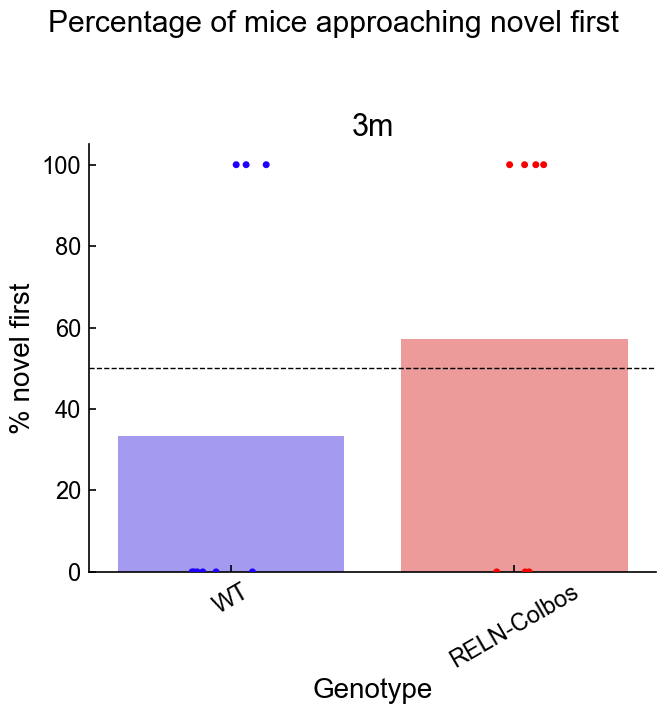

,Age,Genotype,percent_novel,n
0,3m,RELN-Colbos,57.142857,7
1,3m,WT,33.333333,9


In [39]:
if first_approach_df is not None:
    first_binary = first_approach_df.copy()
    first_binary["novel_first"] = (first_binary["FirstApproach"] == "novel").astype(int)

    first_percent = (
        first_binary
        .groupby(["Age", "Genotype"], as_index=False)
        .agg(
            percent_novel=("novel_first", lambda x: x.mean() * 100),
            n=("novel_first", "count")
        )
    )

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(7, 7), sharey=True)
    axes = np.atleast_1d(axes)  # ensure axes is always an array, even if there's only one subplot

    for ax, age in zip(axes, AGE_ORDER):
        sub = first_percent[first_percent["Age"] == age].copy()

        sns.barplot(
            data=sub,
            x="Genotype",
            y="percent_novel",
            order=GENO_ORDER,
            hue="Genotype",
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            legend=False,
            alpha=0.45,
            ax=ax
        )

        sns.stripplot(
            data=first_binary[first_binary["Age"] == age].assign(percent=lambda d: d["novel_first"] * 100),
            x="Genotype",
            y="percent",
            order=GENO_ORDER,
            hue="Genotype",
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            dodge=False,
            legend=False,
            size=5,
            jitter=0.15,
            ax=ax
        )

        ax.axhline(50, color="black", linestyle="--", linewidth=1)
        format_axes(ax)
        ax.set_title(age)
        ax.set_ylabel("% novel first" if age == AGE_ORDER[0] else "")
        ax.set_xlabel("Genotype")
        ax.tick_params(axis="x", rotation=30)
        ax.set_ylim(0, 105)

    fig.suptitle("Percentage of mice approaching novel first", y=1.03)
    plt.tight_layout()
    save_figure_pdf()
plt.show()

display(first_percent.head())


Saved PDF: 019_First_object_approached_during_the_NOR_test.pdf


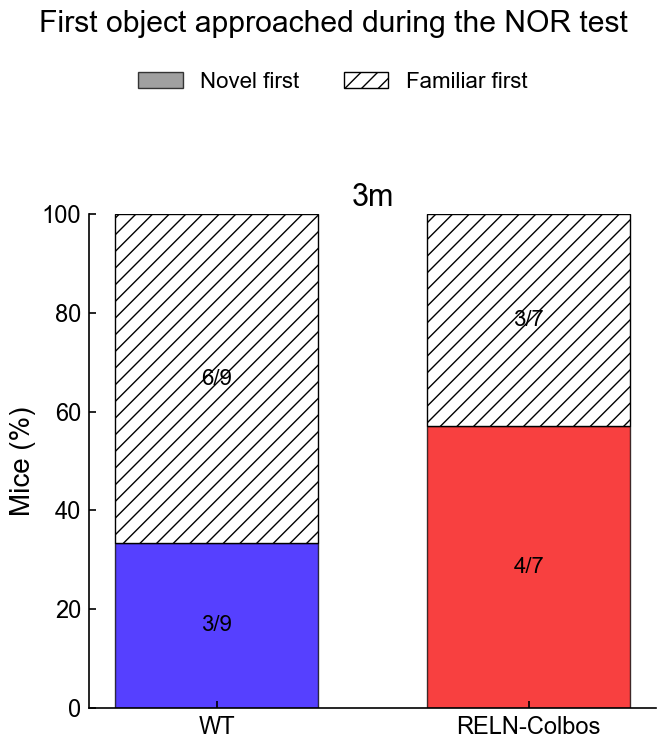

,Age,Genotype,n_total,n_novel,n_familiar,percent_novel,percent_familiar
0,3m,RELN-Colbos,7,4,3,57.142857,42.857143
1,3m,WT,9,3,6,33.333333,66.666667


In [40]:
if first_approach_df is not None:

    # --------------------------------------------
    # Create binary novel/familiar-first summary
    # --------------------------------------------
    first_binary = first_approach_df.copy()

    first_binary["novel_first"] = (
        first_binary["FirstApproach"] == "novel"
    ).astype(int)

    first_summary = (
        first_binary
        .groupby(["Age", "Genotype"], as_index=False)
        .agg(
            n_total=("novel_first", "count"),
            n_novel=("novel_first", "sum"),
        )
    )

    first_summary["n_familiar"] = (
        first_summary["n_total"]
        - first_summary["n_novel"]
    )

    first_summary["percent_novel"] = (
        first_summary["n_novel"]
        / first_summary["n_total"]
        * 100
    )

    first_summary["percent_familiar"] = (
        first_summary["n_familiar"]
        / first_summary["n_total"]
        * 100
    )

    # --------------------------------------------
    # Plot stacked bars
    # --------------------------------------------
    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(7, 7),
        sharey=True,
        squeeze=False  #<------------------------- remove if there's multiple rows of subplots, but keep if only one row
    )
    axes = axes.flatten()  # <-------------------- same as above, remove if there's multiple rows of subplots, but keep if only one row
    x = np.arange(len(GENO_ORDER))

    for ax, age in zip(axes, AGE_ORDER):

        sub = (
            first_summary[
                first_summary["Age"] == age
            ]
            .set_index("Genotype")
            .reindex(GENO_ORDER)
        )

        novel_vals = sub["percent_novel"].to_numpy()
        familiar_vals = sub["percent_familiar"].to_numpy()

        # Novel first
        ax.bar(
            x,
            novel_vals,
            width=0.65,
            color=[
                GENO_COLORS[g]
                for g in GENO_ORDER
            ],
            alpha=0.75,
            edgecolor="black",
            linewidth=1,
            label="Novel first"
        )

        # Familiar first
        ax.bar(
            x,
            familiar_vals,
            bottom=novel_vals,
            width=0.65,
            color="white",
            edgecolor="black",
            linewidth=1,
            hatch="//",
            label="Familiar first"
        )

        # ----------------------------------------
        # Add counts inside each segment
        # ----------------------------------------
        for i, genotype in enumerate(GENO_ORDER):

            if pd.isna(sub.loc[genotype, "n_total"]):
                continue

            n_total = int(sub.loc[genotype, "n_total"])
            n_novel = int(sub.loc[genotype, "n_novel"])
            n_familiar = int(sub.loc[genotype, "n_familiar"])

            # Novel count
            if novel_vals[i] > 8:
                ax.text(
                    i,
                    novel_vals[i] / 2,
                    f"{n_novel}/{n_total}",
                    ha="center",
                    va="center",
                    fontsize=16
                )

            # Familiar count
            if familiar_vals[i] > 8:
                ax.text(
                    i,
                    novel_vals[i] + familiar_vals[i] / 2,
                    f"{n_familiar}/{n_total}",
                    ha="center",
                    va="center",
                    fontsize=16
                )

        ax.set_title(age)

        ax.set_xticks(x)
        ax.set_xticklabels(
            GENO_ORDER,
            rotation=0
        )

        ax.set_xlabel("")
        ax.set_ylabel(
            "Mice (%)"
            if age == AGE_ORDER[0]
            else ""
        )

        ax.set_ylim(0, 100)

        ax.set_yticks([
            0,
            20,
            40,
            60,
            80,
            100
        ])

        format_axes(ax)

    # --------------------------------------------
    # Shared legend
    # --------------------------------------------
    handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor="gray",
            alpha=0.75,
            edgecolor="black",
            label="Novel first"
        ),
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor="white",
            edgecolor="black",
            hatch="//",
            label="Familiar first"
        ),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False
    )

    fig.suptitle(
        "First object approached during the NOR test",
        y=1.08
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    save_figure_pdf()

    plt.show()

    display(first_summary)

## Save processed analysis summaries

This saves useful analysis-level tables from the MASTER data.


In [41]:
ANALYSIS_OUTPUT = MASTER_OUTPUT / "analysis_summaries"
ANALYSIS_OUTPUT.mkdir(exist_ok=True)

phase_total.to_csv(ANALYSIS_OUTPUT / "phase_total_by_age_genotype.csv", index=False)
avg_4h_summary.to_csv(ANALYSIS_OUTPUT / "average_exploration_4h_summary.csv", index=False)
avg_24h_summary.to_csv(ANALYSIS_OUTPUT / "average_exploration_24h_summary.csv", index=False)
cum_2h_summary.to_csv(ANALYSIS_OUTPUT / "cumulative_exploration_2h_summary.csv", index=False)
cum_24h_summary.to_csv(ANALYSIS_OUTPUT / "cumulative_exploration_24h_summary.csv", index=False)
mouse_di_2h.to_csv(ANALYSIS_OUTPUT / "mouse_level_DI_2h.csv", index=False)
mouse_di_10h.to_csv(ANALYSIS_OUTPUT / "mouse_level_DI_10h.csv", index=False)
mouse_di_24h.to_csv(ANALYSIS_OUTPUT / "mouse_level_DI_24h.csv", index=False)

if first_approach_df is not None:
    first_approach_df.to_csv(ANALYSIS_OUTPUT / "first_approach_cleaned.csv", index=False)

print("Saved summaries to:", ANALYSIS_OUTPUT)


Saved summaries to: /Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration/NOR_MASTER/analysis_summaries


In [42]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway, kruskal
from statsmodels.stats.multitest import multipletests

In [43]:
stats_df = binned_df.copy()

AGE_COL = "Age"
GENO_COL = "Genotype"

AGE_ORDER_STATS = ["3m"]
GENO_ORDER_STATS = ["WT", "RELN-Colbos"]

# Add/edit metrics here.
# Key = dataframe column name.
METRICS = {
    "total_sec": "Total exploration",
}

STATS_OUTPUT = Path("statistics_example")
STATS_OUTPUT.mkdir(exist_ok=True)

# Keep only WT and NLGF, and only the selected ages.
stats_df = stats_df.copy()
stats_df[AGE_COL] = stats_df[AGE_COL].astype(str).str.strip()
stats_df[GENO_COL] = stats_df[GENO_COL].astype(str).str.strip()
stats_df = stats_df[stats_df[AGE_COL].isin(AGE_ORDER_STATS)].copy()
stats_df = stats_df[stats_df[GENO_COL].isin(GENO_ORDER_STATS)].copy()

for metric in METRICS:
    if metric in stats_df.columns:
        stats_df[metric] = pd.to_numeric(stats_df[metric], errors="coerce")
    else:
        print(f"Warning: metric column not found and will be skipped: {metric}")

print("Data included in statistics:")
display(stats_df.groupby([AGE_COL, GENO_COL]).size().reset_index(name="n"))

stats_df.head()

Data included in statistics:


,Age,Genotype,n
0,3m,RELN-Colbos,2554
1,3m,WT,3163


,bin,left,right,left_sec,right_sec,total_sec,KageID,Genotype,Phase,rotation,window_end,NOR_side,cumulative_left_sec,cumulative_right_sec,cumulative_total_sec,Cohort,Age,MouseSessionID,time_min,time_hr
0,0,0,1,0.0,0.5,0.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,0.0,0.5,0.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,0,0.000000
1,1,3,59,1.5,29.5,31.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,1.5,30.0,31.5,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,1,0.016667
2,2,33,0,16.5,0.0,16.5,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,18.0,30.0,48.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,2,0.033333
3,3,18,20,9.0,10.0,19.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,40.0,67.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,3,0.050000
4,4,0,6,0.0,3.0,3.0,Kage1,RELN-Colbos,ITI_baseline,2026-02-14 11:32:43,2026-02-15 11:31:40,R,27.0,43.0,70.0,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,4,0.066667


In [44]:
def p_to_stars(p):
    """Convert a p-value into significance stars."""
    if pd.isna(p):
        return "NA"
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def clean_values(data, metric):
    """Return one clean numeric vector for a metric."""
    return pd.to_numeric(data[metric], errors="coerce").dropna()


def sem_numeric(x):
    """Standard error of the mean."""
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))


def shapiro_safe(x):
    """Run Shapiro-Wilk safely. Needs at least 3 values."""
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    if len(x) < 3:
        return np.nan, np.nan, "too few values"
    if len(x) > 5000:
        x = x.sample(5000, random_state=1)
    W, p = shapiro(x)
    return W, p, "normal" if p > 0.05 else "not normal"

In [45]:
normality_results = []

for metric, metric_label in METRICS.items():
    if metric not in stats_df.columns:
        continue

    for age in AGE_ORDER_STATS:
        for genotype in GENO_ORDER_STATS:
            sub = stats_df[
                (stats_df[AGE_COL] == age) &
                (stats_df[GENO_COL] == genotype)
            ]
            x = clean_values(sub, metric)
            W, p, result = shapiro_safe(x)

            normality_results.append({
                "metric": metric,
                "metric_label": metric_label,
                "age": age,
                "genotype": genotype,
                "n": len(x),
                "shapiro_W": W,
                "shapiro_p": p,
                "normality": result,
            })

normality_df = pd.DataFrame(normality_results)
normality_df.to_csv(STATS_OUTPUT / "normality_results.csv", index=False)

display(normality_df)


,metric,metric_label,age,genotype,n,shapiro_W,shapiro_p,normality
0,total_sec,Total exploration,3m,WT,3163,0.642485,5.206697e-63,not normal
1,total_sec,Total exploration,3m,RELN-Colbos,2554,0.626362,2.224084e-59,not normal


In [46]:
wt_vs_relncolbos_results = []

for metric, metric_label in METRICS.items():
    if metric not in stats_df.columns:
        continue

    for age in AGE_ORDER_STATS:
        wt = clean_values(
            stats_df[(stats_df[AGE_COL] == age) & (stats_df[GENO_COL] == "WT")],
            metric
        )
        relncolbos = clean_values(
            stats_df[(stats_df[AGE_COL] == age) & (stats_df[GENO_COL] == "RELN-Colbos")],
            metric
        )

        row = {
            "metric": metric,
            "metric_label": metric_label,
            "age": age,
            "comparison": "WT vs RELN-Colbos",
            "WT_n": len(wt),
            "RELN-Colbos_n": len(relncolbos),
            "WT_mean": wt.mean(),
            "RELN-Colbos_mean": relncolbos.mean(),
            "WT_sem": sem_numeric(wt),
            "RELN-Colbos_sem": sem_numeric(relncolbos),
        }

        if len(wt) < 2 or len(relncolbos) < 2:
            row.update({
                "test": "not enough data",
                "statistic": np.nan,
                "p_value": np.nan,
                "stars": "NA",
            })
            wt_vs_relncolbos_results.append(row)
            continue

        wt_norm_p = normality_df.query(
            "metric == @metric and age == @age and genotype == 'WT'"
        )["shapiro_p"].iloc[0]

        relncolbos_norm_p = normality_df.query(
            "metric == @metric and age == @age and genotype == 'RELN-Colbos'"
        )["shapiro_p"].iloc[0]

        both_normal = (wt_norm_p > 0.05) and (relncolbos_norm_p > 0.05)

        if both_normal:
            stat, p = ttest_ind(wt, relncolbos, equal_var=False, nan_policy="omit")
            test_name = "Welch t-test"
        else:
            stat, p = mannwhitneyu(wt, relncolbos, alternative="two-sided")
            test_name = "Mann-Whitney U"

        row.update({
            "test": test_name,
            "statistic": stat,
            "p_value": p,
            "stars": p_to_stars(p),
        })
        wt_vs_relncolbos_results.append(row)

wt_vs_relncolbos_df = pd.DataFrame(wt_vs_relncolbos_results)
wt_vs_relncolbos_df.to_csv(STATS_OUTPUT / "WT_vs_RELN-Colbos_by_age.csv", index=False)

display(wt_vs_relncolbos_df)

,metric,metric_label,age,comparison,WT_n,RELN-Colbos_n,WT_mean,RELN-Colbos_mean,WT_sem,RELN-Colbos_sem,test,statistic,p_value,stars
0,total_sec,Total exploration,3m,WT vs RELN-Colbos,3163,2554,8.000474,7.401135,0.204237,0.214024,Mann-Whitney U,4153106.0,0.065712,ns


In [47]:
age_effect_results = []
pairwise_age_results = []

for metric, metric_label in METRICS.items():
    if metric not in stats_df.columns:
        continue

    for genotype in GENO_ORDER_STATS:
        groups = []
        group_names = []
        normal_flags = []

        for age in AGE_ORDER_STATS:
            x = clean_values(
                stats_df[(stats_df[AGE_COL] == age) & (stats_df[GENO_COL] == genotype)],
                metric
            )

            if len(x) >= 2:
                groups.append(x)
                group_names.append(age)

                norm_row = normality_df.query(
                    "metric == @metric and age == @age and genotype == @genotype"
                )
                p_norm = norm_row["shapiro_p"].iloc[0] if len(norm_row) else np.nan
                normal_flags.append(p_norm > 0.05)

        if len(groups) < 2:
            age_effect_results.append({
                "metric": metric,
                "metric_label": metric_label,
                "genotype": genotype,
                "comparison": "6m vs 12m vs 24m",
                "test": "not enough data",
                "statistic": np.nan,
                "p_value": np.nan,
                "stars": "NA",
            })
            continue

        all_normal = all(normal_flags)

        if len(groups) >= 3:
            if all_normal:
                stat, p = f_oneway(*groups)
                test_name = "One-way ANOVA"
            else:
                stat, p = kruskal(*groups)
                test_name = "Kruskal-Wallis"
        else:
            if all_normal:
                stat, p = ttest_ind(groups[0], groups[1], equal_var=False, nan_policy="omit")
                test_name = "Welch t-test, two ages only"
            else:
                stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
                test_name = "Mann-Whitney U, two ages only"

        age_effect_results.append({
            "metric": metric,
            "metric_label": metric_label,
            "genotype": genotype,
            "comparison": " vs ".join(group_names),
            "test": test_name,
            "statistic": stat,
            "p_value": p,
            "stars": p_to_stars(p),
        })

        # Pairwise age comparisons, regardless of whether the overall test is significant.
        # This is useful for checking patterns, but only interpret them carefully.
        raw_pairwise = []
        for i in range(len(group_names)):
            for j in range(i + 1, len(group_names)):
                age1, age2 = group_names[i], group_names[j]
                x1, x2 = groups[i], groups[j]

                if all_normal:
                    pair_stat, pair_p = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
                    pair_test = "Welch t-test"
                else:
                    pair_stat, pair_p = mannwhitneyu(x1, x2, alternative="two-sided")
                    pair_test = "Mann-Whitney U"

                raw_pairwise.append({
                    "metric": metric,
                    "metric_label": metric_label,
                    "genotype": genotype,
                    "comparison": f"{age1} vs {age2}",
                    "test": pair_test,
                    "statistic": pair_stat,
                    "raw_p": pair_p,
                })

        if raw_pairwise:
            raw_p = [r["raw_p"] for r in raw_pairwise]
            _, corrected_p, _, _ = multipletests(raw_p, method="holm")
            for r, p_corr in zip(raw_pairwise, corrected_p):
                r["p_value_holm"] = p_corr
                r["stars"] = p_to_stars(p_corr)
                pairwise_age_results.append(r)

age_effect_df = pd.DataFrame(age_effect_results)
pairwise_age_df = pd.DataFrame(pairwise_age_results)

age_effect_df.to_csv(STATS_OUTPUT / "age_effect_within_genotype.csv", index=False)
pairwise_age_df.to_csv(STATS_OUTPUT / "pairwise_age_comparisons_holm.csv", index=False)

display(age_effect_df)
display(pairwise_age_df)

,metric,metric_label,genotype,comparison,test,statistic,p_value,stars
0,total_sec,Total exploration,WT,6m vs 12m vs 24m,not enough data,NaN,NaN,NA
1,total_sec,Total exploration,RELN-Colbos,6m vs 12m vs 24m,not enough data,NaN,NaN,NA


""


## Sample versus test discrimination index

This analysis compares each mouse's discrimination index during the sample phase with its discrimination index during the test phase.

During the sample phase, both objects are identical. Therefore, the index represents baseline side preference toward the side that will later contain the novel object.

During the test phase, the same calculation represents novel-object discrimination.

Primary analysis: first 2 hours after each wheel change.

Sensitivity analysis: whole 24-hour phase.

The sample and test points are paired within each mouse.

In [48]:
# Sample versus test DI analysis

SAMPLE_TEST_GENOTYPES = ["WT", "RELN-Colbos"]
SAMPLE_TEST_PHASE_ORDER = ["sample", "test"]

def make_sample_test_di(data, cutoff_min=120):
    """
    Calculate one DI per mouse for sample and test phases.

    Sample phase:
        'novel_sec' means exploration of the side that will later contain
        the novel object. Because the sample objects are identical, this is
        a baseline side-preference index.

    Test phase:
        DI is the conventional novel-versus-familiar discrimination index.
    """
    required = {
        "Phase", "MouseSessionID", "KageID", "Cohort", "Age",
        "Genotype", "NOR_side", "time_min", "left_sec", "right_sec"
    }
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    temp = data[
        data["Phase"].astype(str).str.lower().isin(SAMPLE_TEST_PHASE_ORDER)
    ].copy()

    temp["Phase"] = temp["Phase"].astype(str).str.lower()
    temp["Genotype"] = temp["Genotype"].astype(str).str.strip()
    temp["Age"] = temp["Age"].astype(str).str.strip()

    # Keep the requested post-wheel-change window.
    temp["time_min"] = pd.to_numeric(temp["time_min"], errors="coerce")
    temp = temp[
        temp["time_min"].ge(0)
        & temp["time_min"].lt(cutoff_min)
    ].copy()

    side = temp["NOR_side"].astype(str).str.upper().str[0]

    # Map both phases using the future novel side.
    temp["future_novel_side_sec"] = np.where(
        side.eq("L"),
        temp["left_sec"],
        temp["right_sec"],
    )
    temp["future_familiar_side_sec"] = np.where(
        side.eq("L"),
        temp["right_sec"],
        temp["left_sec"],
    )

    mouse_phase = (
        temp
        .groupby(
            [
                "MouseSessionID", "KageID", "Cohort",
                "Age", "Genotype", "Phase"
            ],
            as_index=False,
        )
        .agg(
            novel_side_sec=("future_novel_side_sec", "sum"),
            familiar_side_sec=("future_familiar_side_sec", "sum"),
        )
    )

    total = (
        mouse_phase["novel_side_sec"]
        + mouse_phase["familiar_side_sec"]
    )

    mouse_phase["DI"] = np.where(
        total > 0,
        (
            mouse_phase["novel_side_sec"]
            - mouse_phase["familiar_side_sec"]
        ) / total,
        np.nan,
    )

    mouse_phase["window_h"] = cutoff_min / 60
    return mouse_phase


sample_test_di_2h = make_sample_test_di(main_binned, cutoff_min=120)
sample_test_di_24h = make_sample_test_di(main_binned, cutoff_min=1440)

display(sample_test_di_2h.head())


,MouseSessionID,KageID,Cohort,Age,Genotype,Phase,novel_side_sec,familiar_side_sec,DI,window_h
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,116.0,135.0,-0.075697,2.0
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,test,78.5,33.5,0.401786,2.0
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,391.0,201.5,0.319831,2.0
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,test,302.5,199.0,0.206381,2.0
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage11,Kage11,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,sample,188.5,121.0,0.218094,2.0


Saved PDF: 020_NoveltyFamiliar_Discrimination_Index_first_2_h.pdf
Saved PDF: 021_NoveltyFamiliar_Discrimination_Index_whole_phase.pdf


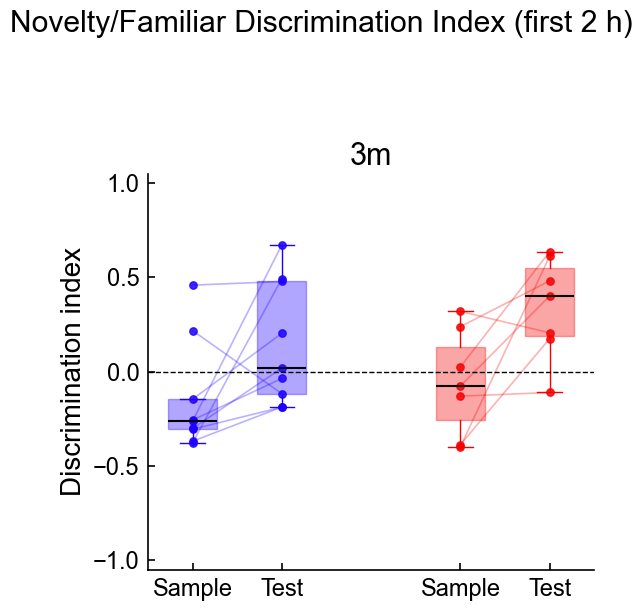

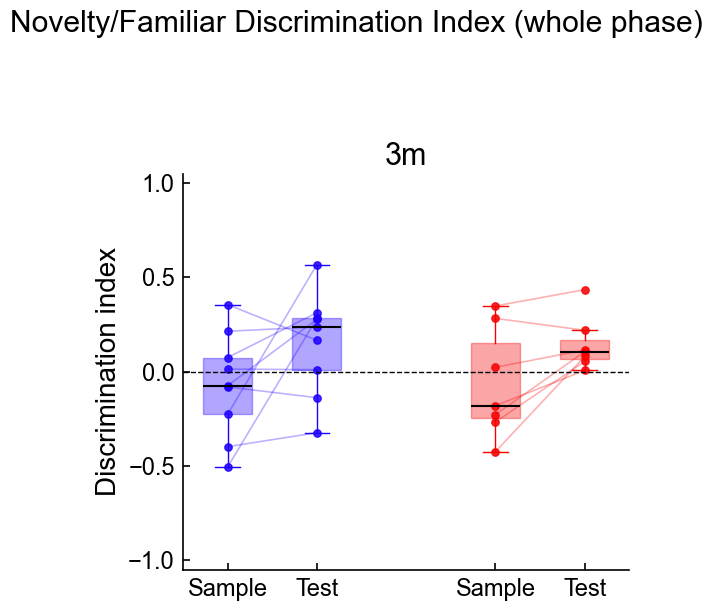

In [49]:
def plot_sample_vs_test_di(di_df, window_label):
    """
    Plot paired sample-versus-test DI for each age and genotype.
    """
    plot_df = di_df[
        di_df["Genotype"].isin(SAMPLE_TEST_GENOTYPES)
    ].dropna(subset=["DI"]).copy()

    ages_present = [
        age for age in AGE_ORDER
        if age in plot_df["Age"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(ages_present),
        figsize=(6 * len(ages_present), 6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, age in zip(axes, ages_present):
        age_df = plot_df[plot_df["Age"] == age].copy()

        genotype_positions = {
            genotype: index * 3
            for index, genotype in enumerate(SAMPLE_TEST_GENOTYPES)
        }

        for genotype in SAMPLE_TEST_GENOTYPES:
            genotype_df = age_df[
                age_df["Genotype"] == genotype
            ].copy()

            paired = (
                genotype_df
                .pivot_table(
                    index="MouseSessionID",
                    columns="Phase",
                    values="DI",
                    aggfunc="first",
                )
                .dropna(subset=["sample", "test"])
            )

            if paired.empty:
                continue

            x0 = genotype_positions[genotype]
            x_sample = x0
            x_test = x0 + 1
            color = GENO_COLORS.get(genotype, "black")

            for _, row in paired.iterrows():
                ax.plot(
                    [x_sample, x_test],
                    [row["sample"], row["test"]],
                    color=color,
                    alpha=0.30,
                    linewidth=1.2,
                    zorder=1,
                )
                ax.scatter(
                    [x_sample, x_test],
                    [row["sample"], row["test"]],
                    color=color,
                    alpha=0.85,
                    s=28,
                    zorder=2,
                )

            # Boxplots overlaid on paired observations.
            ax.boxplot(
                [paired["sample"], paired["test"]],
                positions=[x_sample, x_test],
                widths=0.55,
                patch_artist=True,
                showfliers=False,
                boxprops={
                    "facecolor": color,
                    "alpha": 0.35,
                    "edgecolor": color,
                },
                medianprops={"color": "black", "linewidth": 1.5},
                whiskerprops={"color": color},
                capprops={"color": color},
            )

        tick_positions = []
        tick_labels = []
        for genotype in SAMPLE_TEST_GENOTYPES:
            x0 = genotype_positions[genotype]
            tick_positions.extend([x0, x0 + 1])
            tick_labels.extend([
                f"Sample",
                f"Test",
            ])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(age)
        ax.set_xlabel("")
        format_axes(ax)

    axes[0].set_ylabel("Discrimination index")
    fig.suptitle(
        f"Novelty/Familiar Discrimination Index ({window_label})\n",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


# Primary figure
plot_sample_vs_test_di(sample_test_di_2h, "first 2 h")

# Sensitivity figure
plot_sample_vs_test_di(sample_test_di_24h, "whole phase")


In [50]:
# Paired sample-versus-test statistics within each age and genotype.

from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def paired_sample_test_stats(di_df, window_label):
    results = []

    analysis_df = di_df[
        di_df["Genotype"].isin(SAMPLE_TEST_GENOTYPES)
    ].copy()

    for age in AGE_ORDER:
        for genotype in SAMPLE_TEST_GENOTYPES:
            paired = (
                analysis_df[
                    (analysis_df["Age"] == age)
                    & (analysis_df["Genotype"] == genotype)
                ]
                .pivot_table(
                    index="MouseSessionID",
                    columns="Phase",
                    values="DI",
                    aggfunc="first",
                )
                .dropna(subset=["sample", "test"])
            )

            n = len(paired)

            if n < 2:
                results.append({
                    "window": window_label,
                    "age": age,
                    "genotype": genotype,
                    "n_pairs": n,
                    "sample_mean": paired["sample"].mean() if n else np.nan,
                    "test_mean": paired["test"].mean() if n else np.nan,
                    "mean_change": np.nan,
                    "test": "not enough paired data",
                    "statistic": np.nan,
                    "p_value": np.nan,
                })
                continue

            difference = paired["test"] - paired["sample"]

            if n >= 3:
                _, normality_p = shapiro(difference)
            else:
                normality_p = np.nan

            if n >= 3 and normality_p > 0.05:
                statistic, p_value = ttest_rel(
                    paired["test"],
                    paired["sample"],
                    nan_policy="omit",
                )
                test_name = "paired t-test"
            else:
                try:
                    statistic, p_value = wilcoxon(
                        paired["test"],
                        paired["sample"],
                        alternative="two-sided",
                        zero_method="wilcox",
                    )
                    test_name = "Wilcoxon signed-rank"
                except ValueError:
                    statistic, p_value = np.nan, np.nan
                    test_name = "Wilcoxon unavailable"

            results.append({
                "window": window_label,
                "age": age,
                "genotype": genotype,
                "n_pairs": n,
                "sample_mean": paired["sample"].mean(),
                "test_mean": paired["test"].mean(),
                "mean_change": difference.mean(),
                "difference_shapiro_p": normality_p,
                "test": test_name,
                "statistic": statistic,
                "p_value": p_value,
            })

    results_df = pd.DataFrame(results)

    valid = results_df["p_value"].notna()
    results_df["p_fdr"] = np.nan
    if valid.any():
        results_df.loc[valid, "p_fdr"] = multipletests(
            results_df.loc[valid, "p_value"],
            method="fdr_bh",
        )[1]

    results_df["stars"] = results_df["p_fdr"].apply(
        lambda p: (
            "NA" if pd.isna(p)
            else "****" if p < 0.0001
            else "***" if p < 0.001
            else "**" if p < 0.01
            else "*" if p < 0.05
            else "ns"
        )
    )

    return results_df


sample_test_stats_2h = paired_sample_test_stats(
    sample_test_di_2h,
    "first_2h",
)
sample_test_stats_24h = paired_sample_test_stats(
    sample_test_di_24h,
    "whole_24h",
)

sample_test_stats = pd.concat(
    [sample_test_stats_2h, sample_test_stats_24h],
    ignore_index=True,
)

display(sample_test_stats)

SAMPLE_TEST_OUTPUT = MASTER_OUTPUT / "sample_vs_test_DI"
SAMPLE_TEST_OUTPUT.mkdir(exist_ok=True)

sample_test_di_2h.to_csv(
    SAMPLE_TEST_OUTPUT / "sample_vs_test_DI_first_2h.csv",
    index=False,
)
sample_test_di_24h.to_csv(
    SAMPLE_TEST_OUTPUT / "sample_vs_test_DI_whole_24h.csv",
    index=False,
)
sample_test_stats.to_csv(
    SAMPLE_TEST_OUTPUT / "sample_vs_test_DI_statistics.csv",
    index=False,
)

print("Saved sample-versus-test DI outputs to:", SAMPLE_TEST_OUTPUT)


,window,age,genotype,n_pairs,sample_mean,test_mean,mean_change,difference_shapiro_p,test,statistic,p_value,p_fdr,stars
0,first_2h,3m,WT,9,-0.148696,0.148888,0.297584,0.438417,paired t-test,2.244087,0.055073,0.055073,ns
1,first_2h,3m,RELN-Colbos,7,-0.058101,0.343625,0.401726,0.888669,paired t-test,2.769148,0.032459,0.055073,ns
2,whole_24h,3m,WT,9,-0.069302,0.155193,0.224495,0.121915,paired t-test,1.881299,0.096712,0.096712,ns
3,whole_24h,3m,RELN-Colbos,7,-0.063398,0.145593,0.208990,0.910546,paired t-test,2.893548,0.027566,0.055131,ns


Saved sample-versus-test DI outputs to: /Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration/NOR_MASTER/sample_vs_test_DI


# 6-month cohort split and change in DI over time

This section adds the two requested NOR analyses:

1. Split the 6-month mice by cohort for novel/familiar DI.
2. Calculate the within-mouse change in DI at 2, 4, 6, and 8 hours:

\[
\Delta DI = DI_{\mathrm{test}} - DI_{\mathrm{sample}}
\]

A positive value means discrimination increased from the sample phase to the
test phase. A value near zero means little change, and a negative value means
the test DI was lower than the sample-side preference.


In [51]:
# Build sample and test DI values at cumulative 2, 4, 6, and 8 h windows.

DELTA_DI_TIMEPOINTS_MIN = [120, 240, 360, 480]
DELTA_DI_GENOTYPES = ["WT", "RELN-Colbos"]  #<----------------- Add more genotypes if desired
GENO_COLORS = ["blue", "red"]  #<----------------- Add more colors if desired

delta_di_parts = []

for cutoff_min in DELTA_DI_TIMEPOINTS_MIN:
    temp = make_sample_test_di(
        main_binned,
        cutoff_min=cutoff_min,
    )

    temp = temp[
        temp["Genotype"].isin(DELTA_DI_GENOTYPES)
    ].copy()

    # Put the paired sample and test values on the same row for each mouse.
    paired = (
        temp
        .pivot_table(
            index=[
                "MouseSessionID",
                "KageID",
                "Cohort",
                "Age",
                "Genotype",
            ],
            columns="Phase",
            values="DI",
            aggfunc="first",
        )
        .reset_index()
    )

    # Only calculate a change score when both phases are available.
    paired = paired.dropna(subset=["sample", "test"]).copy()

    paired["Delta_DI"] = paired["test"] - paired["sample"]
    paired["timepoint_min"] = cutoff_min
    paired["timepoint_h"] = cutoff_min / 60

    delta_di_parts.append(paired)

delta_di_over_time = pd.concat(
    delta_di_parts,
    ignore_index=True,
)

delta_di_over_time["timepoint_h"] = pd.Categorical(
    delta_di_over_time["timepoint_h"],
    categories=[2, 4, 6, 8],
    ordered=True,
)

display(delta_di_over_time.head())


Phase,MouseSessionID,KageID,Cohort,Age,Genotype,sample,test,Delta_DI,timepoint_min,timepoint_h
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,-0.075697,0.401786,0.477483,120,2
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,0.319831,0.206381,-0.113450,120,2
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage11,Kage11,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,0.218094,-0.116667,-0.334760,120,2
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage12,Kage12,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,-0.376744,0.493421,0.870165,120,2
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage13,Kage13,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,-0.261426,0.673130,0.934556,120,2


In [52]:
# Plot the raw novel/familiar TEST DI over time with the 6-month cohorts split.

test_di_6m_split = delta_di_over_time[
    delta_di_over_time["Age"].eq("6m")
].copy()

cohorts_6m = sorted(
    test_di_6m_split["Cohort"]
    .dropna()
    .astype(str)
    .unique()
)

if len(cohorts_6m) == 0:
    print("No 6-month cohort data were found.")
else:
    fig, axes = plt.subplots(
        1,
        len(cohorts_6m),
        figsize=(7 * len(cohorts_6m), 6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, cohort in zip(axes, cohorts_6m):
        cohort_df = test_di_6m_split[
            test_di_6m_split["Cohort"].astype(str).eq(cohort)
        ].copy()

        sns.pointplot(
            data=cohort_df,
            x="timepoint_h",
            y="test",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            errorbar="se",
            dodge=0.12,
            markers="o",
            linestyles="-",
            capsize=0.08,
            ax=ax,
        )

        sns.stripplot(
            data=cohort_df,
            x="timepoint_h",
            y="test",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            dodge=True,
            jitter=0.10,
            size=4,
            alpha=0.55,
            legend=False,
            ax=ax,
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"6m: {cohort}")
        ax.set_xlabel("Cumulative time after wheel change (h)")
        ax.set_ylabel("Novel/familiar DI" if ax is axes[0] else "")
        ax.set_ylim(-1.05, 1.05)
        format_axes(ax)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[:len(DELTA_DI_GENOTYPES)],
            labels[:len(DELTA_DI_GENOTYPES)],
            frameon=False,
            title="Genotype",
        )

    fig.suptitle(
        "6-month novel/familiar test DI",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


No 6-month cohort data were found.


In [53]:
print (DELTA_DI_GENOTYPES)
print (GENO_COLORS)

['WT', 'RELN-Colbos']
['blue', 'red']


Saved PDF: 022_Change_in_discrimination_index_from_sample_to_test.pdf


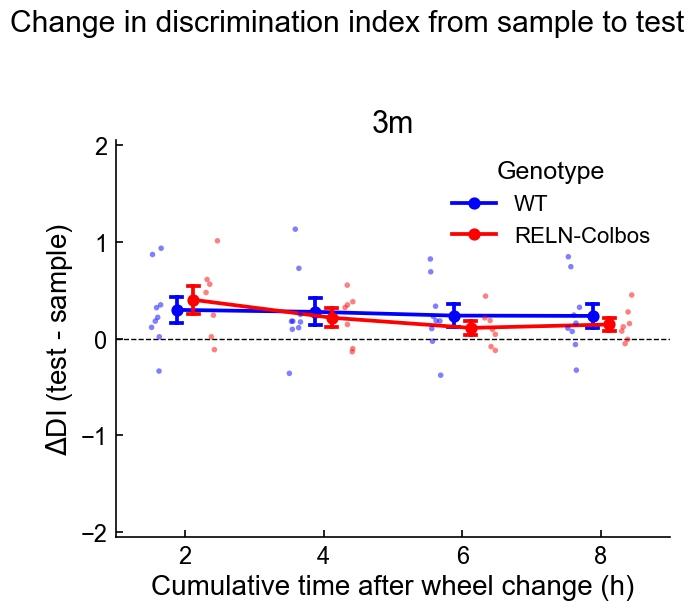

In [54]:
# Plot change in DI over time:
# Delta DI = test DI - sample DI

def plot_delta_di_over_time(delta_df):
    ages_present = [
        age for age in AGE_ORDER
        if age in delta_df["Age"].dropna().unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(ages_present),
        figsize=(7 * len(ages_present), 6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, age in zip(axes, ages_present):
        age_df = delta_df[
            delta_df["Genotype"].isin(DELTA_DI_GENOTYPES)
        ].copy()

        sns.pointplot(
            data=age_df,
            x="timepoint_h",
            y="Delta_DI",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            errorbar="se",
            dodge=0.12,
            markers="o",
            linestyles="-",
            capsize=0.08,
            ax=ax,
        )

        sns.stripplot(
            data=age_df,
            x="timepoint_h",
            y="Delta_DI",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            dodge=True,
            jitter=0.10,
            size=4,
            alpha=0.50,
            legend=False,
            ax=ax,
        )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )
        ax.set_title(age)
        ax.set_xlabel("Cumulative time after wheel change (h)")
        ax.set_ylabel(
            r"$\Delta$DI (test - sample)"
            if ax is axes[0]
            else ""
        )
        ax.set_ylim(-2.05, 2.05)
        format_axes(ax)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[:len(DELTA_DI_GENOTYPES)],
            labels[:len(DELTA_DI_GENOTYPES)],
            frameon=False,
            title="Genotype",
        )

    fig.suptitle(
        "Change in discrimination index from sample to test",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


plot_delta_di_over_time(delta_di_over_time)


In [55]:
# Split the 6-month Delta DI plot by cohort as well.

delta_di_6m = delta_di_over_time[
    delta_di_over_time["Age"].eq("6m")
].copy()

cohorts_6m = sorted(
    delta_di_6m["Cohort"]
    .dropna()
    .astype(str)
    .unique()
)

if len(cohorts_6m) == 0:
    print("No 6-month cohort data were found.")
else:
    fig, axes = plt.subplots(
        1,
        len(cohorts_6m),
        figsize=(7 * len(cohorts_6m), 6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, cohort in zip(axes, cohorts_6m):
        cohort_df = delta_di_6m[
            delta_di_6m["Cohort"].astype(str).eq(cohort)
        ].copy()

        sns.pointplot(
            data=cohort_df,
            x="timepoint_h",
            y="Delta_DI",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            errorbar="se",
            dodge=0.12,
            markers="o",
            linestyles="-",
            capsize=0.08,
            ax=ax,
        )

        sns.stripplot(
            data=cohort_df,
            x="timepoint_h",
            y="Delta_DI",
            hue="Genotype",
            hue_order=DELTA_DI_GENOTYPES,
            palette=GENO_COLORS,
            dodge=True,
            jitter=0.10,
            size=4,
            alpha=0.55,
            legend=False,
            ax=ax,
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"6m: {cohort}")
        ax.set_xlabel("Cumulative time after wheel change (h)")
        ax.set_ylabel(
            r"$\Delta$DI (test - sample)"
            if ax is axes[0]
            else ""
        )
        ax.set_ylim(-2.05, 2.05)
        format_axes(ax)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[:len(DELTA_DI_GENOTYPES)],
            labels[:len(DELTA_DI_GENOTYPES)],
            frameon=False,
            title="Genotype",
        )

    fig.suptitle(
        "6-month change in DI",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


No 6-month cohort data were found.


In [56]:
# Save the new tables.

DELTA_DI_OUTPUT = MASTER_OUTPUT / "delta_DI_over_time"
DELTA_DI_OUTPUT.mkdir(exist_ok=True)

delta_di_over_time.to_csv(
    DELTA_DI_OUTPUT / "sample_to_test_delta_DI_2h_4h_6h_8h.csv",
    index=False,
)

# test_di_6m_split.to_csv(
    #DELTA_DI_OUTPUT / "6m_test_DI_split_by_cohort.csv",
    #index=False,
#)

if "delta_mixed_model_table" in globals():
    delta_mixed_model_table.to_csv(
        DELTA_DI_OUTPUT / "delta_DI_mixed_model_coefficients.csv",
        index=False,
    )

print("Saved Delta DI outputs to:", DELTA_DI_OUTPUT)


Saved Delta DI outputs to: /Volumes/SWC_SmrtKg2/SmartKages_Nov2025_onwards/2026-01-Jan-Feb_RELN-COLBOS_Coh2/DB_previousIteration/NOR_MASTER/delta_DI_over_time


In [57]:
def compare_sample_test_paired_value(df, value_col, context=None):
    """Paired Sample-versus-Test analysis for a specified outcome."""
    context = {} if context is None else dict(context)

    paired = (
        df.pivot_table(
            index="MouseSessionID",
            columns="Phase",
            values=value_col,
            aggfunc="first",
        )
        .dropna(subset=SAMPLE_TEST_PHASES)
    )

    difference = paired["test"] - paired["sample"]
    diff_norm = shapiro_result(difference)

    result = {
        **context,
        "comparison": "Whole Sample vs Test",
        "value_col": value_col,
        "n_pairs": len(paired),
        "sample_mean": paired["sample"].mean() if len(paired) else np.nan,
        "test_mean": paired["test"].mean() if len(paired) else np.nan,
        "mean_change_test_minus_sample": (
            difference.mean() if len(difference) else np.nan
        ),
        "difference_shapiro_W": diff_norm["W"],
        "difference_shapiro_p": diff_norm["p"],
        "differences_normal": diff_norm["normal"],
        "test": "not enough paired data",
        "statistic": np.nan,
        "p_raw": np.nan,
    }

    if len(paired) < 2:
        return result

    if diff_norm["normal"]:
        statistic, p = ttest_rel(
            paired["test"], paired["sample"], nan_policy="omit"
        )
        result["test"] = "Paired t-test"
    else:
        try:
            statistic, p = wilcoxon(
                paired["test"],
                paired["sample"],
                alternative="two-sided",
                zero_method="wilcox",
            )
            result["test"] = "Wilcoxon signed-rank"
        except ValueError:
            statistic, p = np.nan, np.nan
            result["test"] = "Wilcoxon unavailable"

    result["statistic"] = statistic
    result["p_raw"] = p
    return result



In [58]:
# 3. Paired sample-versus-test DI.
# Primary requested paired analysis uses the first 2 hours.

paired_di_rows = []

paired_analysis_df = sample_test_di_2h[
    sample_test_di_2h["Genotype"].isin(["WT", "RELN-Colbos"])
].copy()

for age in AGE_ORDER:
    for genotype in ["WT", "RELN-Colbos"]:
        sub = paired_analysis_df[
            paired_analysis_df["Age"].eq(age)
            & paired_analysis_df["Genotype"].eq(genotype)
        ].copy()

        paired_di_rows.append(
            compare_sample_test_paired(
                sub,
                context={
                    "analysis": "Paired DI first 2 h",
                    "Age": age,
                    "Genotype": genotype,
                },
            )
        )

paired_di_stats = add_holm_and_stars(
    pd.DataFrame(paired_di_rows)
)

display(paired_di_stats)
paired_di_stats.to_csv(
    REQUESTED_STATS_OUTPUT / "paired_sample_vs_test_DI_first_2h.csv",
    index=False,
)


def plot_paired_di_with_requested_stats(di_df, stats_df):
    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(18, 6.5),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    genotype_positions = {
        "WT": 0,
        "RELN-Colbos": 3,
    }

    for ax, age in zip(axes, AGE_ORDER):
        for genotype in ["WT", "RELN-Colbos"]:
            paired = (
                di_df[
                    di_df["Age"].eq(age)
                    & di_df["Genotype"].eq(genotype)
                ]
                .pivot_table(
                    index="MouseSessionID",
                    columns="Phase",
                    values="DI",
                    aggfunc="first",
                )
                .dropna(subset=["sample", "test"])
            )

            x_sample = genotype_positions[genotype]
            x_test = x_sample + 1
            color = GENO_COLORS[genotype]

            for _, row in paired.iterrows():
                ax.plot(
                    [x_sample, x_test],
                    [row["sample"], row["test"]],
                    color=color,
                    alpha=0.30,
                    linewidth=1.1,
                    zorder=1,
                )
                ax.scatter(
                    [x_sample, x_test],
                    [row["sample"], row["test"]],
                    color=color,
                    alpha=0.85,
                    s=30,
                    zorder=2,
                )

            if not paired.empty:
                ax.boxplot(
                    [paired["sample"], paired["test"]],
                    positions=[x_sample, x_test],
                    widths=0.50,
                    patch_artist=True,
                    showfliers=False,
                    boxprops={
                        "facecolor": color,
                        "alpha": 0.28,
                        "edgecolor": color,
                    },
                    medianprops={
                        "color": "black",
                        "linewidth": 1.4,
                    },
                    whiskerprops={"color": color},
                    capprops={"color": color},
                )

            row = stats_df[
                stats_df["Age"].eq(age)
                & stats_df["Genotype"].eq(genotype)
            ]
            label = row.iloc[0]["stars"] if not row.empty else "NA"

            add_bracket(
                ax,
                x_sample,
                x_test,
                1.08,
                label,
                height=0.035,
            )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )
        ax.set_xlim(-0.7, 4.7)
        ax.set_ylim(-1.08, 1.30)
        ax.set_xticks([0, 1, 3, 4])
        ax.set_xticklabels([
            "Sample",
            "Test",
            "Sample",
            "Test",
        ])
        ax.text(
            0.5,
            -1.23,
            "WT",
            ha="center",
            va="top",
            color=GENO_COLORS["WT"],
            fontsize=12,
        )
        ax.text(
            3.5,
            -1.23,
            "RELN-Colbos",
            ha="center",
            va="top",
            color=GENO_COLORS["RELN-Colbos"],
            fontsize=12,
        )
        ax.set_title(age)
        ax.set_xlabel("")
        ax.set_ylabel(
            "Discrimination index"
            if age == AGE_ORDER[0]
            else ""
        )
        format_axes(ax)

    fig.suptitle(
        "Paired sample versus test DI: first 2 hours",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


plot_paired_di_with_requested_stats(
    sample_test_di_2h,
    paired_di_stats,
)


NameError: name 'compare_sample_test_paired' is not defined

In [ ]:
# 3. Analyse Delta DI as a continuous time-course rather than as isolated timepoints.

import statsmodels.formula.api as smf

delta_curve_model_results = []
delta_curve_models = {}


def fit_delta_curve_mixed_model(data, age):
    model_df = data[
        data["Age"].eq(age)
        & data["Genotype"].isin(DELTA_DI_GENOTYPES)
    ].dropna(
        subset=[
            "Delta_DI",
            "time_h",
            "Genotype",
            "MouseSessionID",
        ]
    ).copy()

    model_df["Genotype"] = pd.Categorical(
        model_df["Genotype"],
        categories=DELTA_DI_GENOTYPES,
        ordered=True,
    )

    if (
        model_df["MouseSessionID"].nunique() < 3
        or model_df["Genotype"].nunique() < 2
    ):
        print(f"{age}: insufficient data for Delta DI curve model.")
        return None

    # Time is treated as a continuous variable.
    # The interaction tests whether WT and NLGF change differently over time.
    model = smf.mixedlm(
        "Delta_DI ~ C(Genotype) * time_h",
        data=model_df,
        groups=model_df["MouseSessionID"],
        re_formula="1",
    )

    try:
        result = model.fit(
            reml=False,
            method="lbfgs",
            maxiter=2000,
        )
    except Exception:
        result = model.fit(
            reml=False,
            method="powell",
            maxiter=2000,
        )

    print("\n" + "=" * 80)
    print(f"{age}: Delta DI continuous time-course")
    print("=" * 80)
    print(result.summary())

    coefficient_table = (
        result.summary2()
        .tables[1]
        .reset_index()
        .rename(columns={"index": "term"})
    )
    coefficient_table["Age"] = age
    coefficient_table["model"] = (
        "Delta_DI ~ Genotype * continuous time + random intercept(Mouse)"
    )
    delta_curve_model_results.append(coefficient_table)

    return result





def plot_delta_di_curve(delta_df):
    # Add time-zero baseline:
    # before any test exploration has occurred, Delta DI = 0
    baseline_rows = (
        delta_df[
            [
                "MouseSessionID",
                "Age",
                "Genotype",
            ]
        ]
        .drop_duplicates()
        .copy()
    )

    baseline_rows["time_h"] = 0.0
    baseline_rows["Delta_DI"] = 0.0

    plot_df = pd.concat(
        [
            delta_df,
            baseline_rows,
        ],
        ignore_index=True,
    )
    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(18, 6),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    summary = (
        plot_df
        .groupby(
            ["Age", "Genotype", "time_h"],
            as_index=False,
        )
        .agg(
            mean_delta_di=("Delta_DI", "mean"),
            sem_delta_di=("Delta_DI", "sem"),
            n=("Delta_DI", "count"),
        )
    )

    for ax, age in zip(axes, AGE_ORDER):
        age_summary = summary[
            summary["Age"].eq(age)
        ].copy()

        for genotype in DELTA_DI_GENOTYPES:
            genotype_df = age_summary[
                age_summary["Genotype"].eq(genotype)
            ].sort_values("time_h")

            if genotype_df.empty:
                continue

            color = GENO_COLORS[genotype]
            x = genotype_df["time_h"].to_numpy()
            y = genotype_df["mean_delta_di"].to_numpy()
            sem = genotype_df["sem_delta_di"].fillna(0).to_numpy()

            ax.plot(
                x,
                y,
                color=color,
                linewidth=2.2,
                label=genotype,
            )
            ax.fill_between(
                x,
                y - sem,
                y + sem,
                color=color,
                alpha=0.18,
                linewidth=0,
            )

        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=1,
        )
        ax.set_xlim(0, 8)
        ax.set_xticks([0, 1, 2, 4, 6, 8])
        ax.set_title(age)
        ax.set_xlabel("Cumulative time after wheel change (h)")
        ax.set_ylabel(
            "ΔDI (test - sample)"
            if age == AGE_ORDER[0]
            else ""
        )
        format_axes(ax)
        ax.legend(frameon=False, title="Genotype")

    fig.suptitle(
        "Δ Discrimination Index",
        y=1.03,
    )
    plt.tight_layout()
    save_figure_pdf()
plt.show()


plot_delta_di_curve(delta_di_curve)


NameError: name 'delta_di_curve' is not defined

In [59]:

# Build Delta DI continuously across the complete 24-hour test.
# Delta DI(t) = cumulative test DI(t) - complete sample DI

DELTA_STEP_MIN = 10
DELTA_MAX_MIN = 24 * 60
DELTA_SELECTED_HOURS = [2, 4, 6, 8, 10]
DELTA_GENOTYPES = ["WT", "RELN-Colbos"]


def build_delta_di_24h(data):
    work = data.copy()
    side = work["NOR_side"].astype(str).str.upper().str[0]
    left = pd.to_numeric(work["left_sec"], errors="coerce")
    right = pd.to_numeric(work["right_sec"], errors="coerce")

    work["novel_sec"] = np.where(side.eq("L"), left, right)
    work["familiar_sec"] = np.where(side.eq("L"), right, left)

    ids = ["MouseSessionID", "KageID", "Cohort", "Age", "Genotype"]

    sample = work[work["Phase"].astype(str).str.lower().eq("sample")]
    sample_di = (
        sample.groupby(ids, as_index=False)
        .agg(
            sample_novel=("novel_sec", "sum"),
            sample_familiar=("familiar_sec", "sum"),
        )
    )
    sample_total = sample_di["sample_novel"] + sample_di["sample_familiar"]
    sample_di["sample_DI"] = np.where(
        sample_total > 0,
        (sample_di["sample_novel"] - sample_di["sample_familiar"]) / sample_total,
        np.nan,
    )

    test = work[work["Phase"].astype(str).str.lower().eq("test")].copy()
    test["time_min"] = pd.to_numeric(test["time_min"], errors="coerce")
    test = test[test["time_min"].between(0, DELTA_MAX_MIN)]

    rows = []
    cutoffs = np.arange(DELTA_STEP_MIN, DELTA_MAX_MIN + DELTA_STEP_MIN, DELTA_STEP_MIN)

    for keys, mouse_df in test.groupby(ids):
        mouse_df = mouse_df.sort_values("time_min")
        times = mouse_df["time_min"].to_numpy(float)
        novel_cs = np.cumsum(mouse_df["novel_sec"].fillna(0).to_numpy(float))
        familiar_cs = np.cumsum(mouse_df["familiar_sec"].fillna(0).to_numpy(float))

        for cutoff in cutoffs:
            idx = np.searchsorted(times, cutoff, side="right") - 1

            if idx < 0:
                novel = 0.0
                familiar = 0.0
            else:
                novel = novel_cs[idx]
                familiar = familiar_cs[idx]

            total = novel + familiar
            test_di = (novel - familiar) / total if total > 0 else np.nan

            row = dict(zip(ids, keys))
            row.update({
                "time_min": cutoff,
                "time_h": cutoff / 60,
                "test_DI": test_di,
            })
            rows.append(row)

    curve = pd.DataFrame(rows).merge(
        sample_di[ids + ["sample_DI"]],
        on=ids,
        how="left",
        validate="many_to_one",
    )
    curve["Delta_DI"] = curve["test_DI"] - curve["sample_DI"]

    return curve[curve["Genotype"].isin(DELTA_GENOTYPES)].copy()


delta_di_24h = build_delta_di_24h(main_binned)
display(delta_di_24h.head())


,MouseSessionID,KageID,Cohort,Age,Genotype,time_min,time_h,test_DI,sample_DI,Delta_DI
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,10,0.166667,0.428571,0.023432,0.40514
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,20,0.333333,0.428571,0.023432,0.40514
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,30,0.500000,0.428571,0.023432,0.40514
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,40,0.666667,0.428571,0.023432,0.40514
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,50,0.833333,0.428571,0.023432,0.40514


In [61]:
print(GENO_COLORS)

['blue', 'red']


Saved PDF: 024_Change_in_Discrimination_Index.pdf


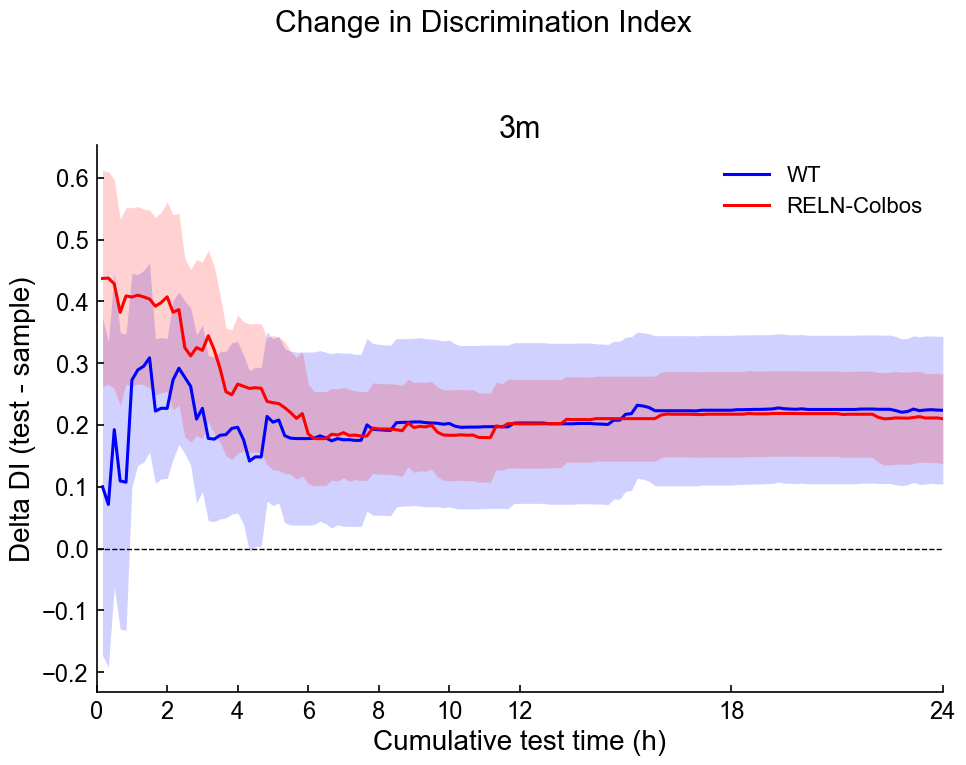

In [68]:

# Plot the full 24-hour Delta DI curve and run a mixed-effects model.

summary = (
    delta_di_24h.groupby(["Age", "Genotype", "time_h"], as_index=False)
    .agg(
        mean_delta=("Delta_DI", "mean"),
        sem_delta=("Delta_DI", "sem"),
    )
)

fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(10, 7.5), sharey=True)
axes = np.atleast_1d(axes)


for ax, age in zip(axes, AGE_ORDER):
    for genotype in DELTA_GENOTYPES:
        sub = summary[
            summary["Age"].eq(age)
            & summary["Genotype"].eq(genotype)
        ].sort_values("time_h")

        x = sub["time_h"].to_numpy()
        y = sub["mean_delta"].to_numpy()
        sem = sub["sem_delta"].fillna(0).to_numpy()

        ax.plot(x, y, color=GENO_COLORS[genotype], linewidth=2.2, label=genotype)
        ax.fill_between(
            x, y - sem, y + sem,
            color=GENO_COLORS[genotype],
            alpha=0.18,
            linewidth=0,
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlim(0, 24)
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 18, 24])
    ax.set_title(age)
    ax.set_xlabel("Cumulative test time (h)")
    ax.set_ylabel("Delta DI (test - sample)" if age == AGE_ORDER[0] else "")
    format_axes(ax)
    ax.legend(frameon=False)

fig.suptitle("Change in Discrimination Index", y=1.03)
plt.tight_layout()
save_figure_pdf()
plt.show()




# Whole Sample versus cumulative Test at 30, 45 and 60 minutes

This section performs the clarified analysis for **both total object exploration and
discrimination index (DI)**.

For every mouse, the Sample value is calculated once using the **whole Sample phase**.
That same Sample value is then compared separately with cumulative Test values at:

- 0–30 minutes
- 0–45 minutes
- 0–60 minutes

The analyses include:

1. WT versus RELN-Colbos comparisons within Sample and Test.
2. Paired whole-Sample versus Test comparisons within each genotype.
3. Separate statistics for 30, 45 and 60 minute Test endpoints.
4. Paired figures, CSV tables and PDF export.

For Sample DI, the side that later becomes novel is used. The Sample DI therefore
represents pre-existing side preference, whereas Test DI represents novel-object
discrimination.


In [69]:
# ==========================================================
# WHOLE SAMPLE VERSUS CUMULATIVE TEST
# FOR TOTAL EXPLORATION AND DI
# AT 30, 45 AND 60 MINUTES
# ==========================================================

EARLY_TIMEPOINTS_MIN = [30, 45, 60]
EARLY_TIME_LABELS = ["30 min", "45 min", "60 min"]
EARLY_GENOTYPES = ["WT", "RELN-Colbos"]
SAMPLE_TEST_PHASES = ["sample", "test"]
DI_PHASES = SAMPLE_TEST_PHASES
TOTAL_PHASES = SAMPLE_TEST_PHASES


def build_loukia_whole_sample_vs_test_tables(data):
    """
    Return mouse-level whole-Sample and cumulative-Test values.

    The whole Sample phase is summarised once per mouse and then repeated
    beside each Test endpoint so that the following paired comparisons can
    be made independently:

        whole Sample vs Test 0-30 min
        whole Sample vs Test 0-45 min
        whole Sample vs Test 0-60 min

    Both total object exploration and DI are calculated from the same
    mouse-level summaries.
    """

    required = {
        "MouseSessionID", "KageID", "Cohort", "Age", "Genotype",
        "Phase", "NOR_side", "time_min", "left_sec", "right_sec",
    }
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    work = data.copy()
    work["Phase"] = work["Phase"].astype(str).str.strip().str.lower()

    for column in ["time_min", "left_sec", "right_sec"]:
        work[column] = pd.to_numeric(work[column], errors="coerce")

    work["left_sec"] = work["left_sec"].fillna(0)
    work["right_sec"] = work["right_sec"].fillna(0)

    work = work[
        work["time_min"].notna()
        & work["time_min"].ge(0)
        & work["Genotype"].isin(EARLY_GENOTYPES)
        & work["Phase"].isin(SAMPLE_TEST_PHASES)
    ].copy()

    # Use the side that becomes novel during Test for both phases.
    future_novel_side = (
        work["NOR_side"].astype(str).str.strip().str.upper().str[0]
    )
    work["novel_sec"] = np.where(
        future_novel_side.eq("L"), work["left_sec"], work["right_sec"]
    )
    work["familiar_sec"] = np.where(
        future_novel_side.eq("L"), work["right_sec"], work["left_sec"]
    )

    id_columns = [
        "MouseSessionID", "KageID", "Cohort", "Age", "Genotype", "Phase"
    ]

    def summarise_mouse_phase(phase_data):
        summary = (
            phase_data
            .groupby(id_columns, as_index=False, observed=True)
            .agg(
                left_sec=("left_sec", "sum"),
                right_sec=("right_sec", "sum"),
                novel_sec=("novel_sec", "sum"),
                familiar_sec=("familiar_sec", "sum"),
            )
        )

        summary["Total_exploration_sec"] = (
            summary["left_sec"] + summary["right_sec"]
        )
        denominator = summary["novel_sec"] + summary["familiar_sec"]
        summary["DI"] = np.where(
            denominator > 0,
            (summary["novel_sec"] - summary["familiar_sec"]) / denominator,
            np.nan,
        )
        return summary

    # Whole Sample: no 30/45/60-minute truncation.
    whole_sample = summarise_mouse_phase(
        work[work["Phase"].eq("sample")].copy()
    )

    output_parts = []

    for cutoff_min in EARLY_TIMEPOINTS_MIN:
        # Repeat the same whole-Sample value for each independent comparison.
        sample_for_endpoint = whole_sample.copy()
        sample_for_endpoint["time_min"] = cutoff_min
        sample_for_endpoint["time_label"] = f"{cutoff_min} min"

        # Test values are cumulative from time zero to the requested endpoint.
        test_for_endpoint = summarise_mouse_phase(
            work[
                work["Phase"].eq("test")
                & work["time_min"].between(0, cutoff_min, inclusive="both")
            ].copy()
        )
        test_for_endpoint["time_min"] = cutoff_min
        test_for_endpoint["time_label"] = f"{cutoff_min} min"

        output_parts.extend([sample_for_endpoint, test_for_endpoint])

    metrics = pd.concat(output_parts, ignore_index=True)
    metrics["time_label"] = pd.Categorical(
        metrics["time_label"],
        categories=EARLY_TIME_LABELS,
        ordered=True,
    )
    metrics["Phase"] = pd.Categorical(
        metrics["Phase"],
        categories=SAMPLE_TEST_PHASES,
        ordered=True,
    )

    return metrics


sample_test_metrics_30_45_60 = (
    build_loukia_whole_sample_vs_test_tables(main_binned)
)

# Keep the familiar variable names used later in the notebook.
total_exploration_30_45_60 = sample_test_metrics_30_45_60.copy()
sample_test_DI_30_45_60 = sample_test_metrics_30_45_60.copy()

print("Phases included:")
print(sample_test_metrics_30_45_60["Phase"].dropna().unique())

# Confirm that each mouse has exactly one whole-Sample value repeated at
# all three endpoints.
sample_consistency_qc = (
    sample_test_metrics_30_45_60[
        sample_test_metrics_30_45_60["Phase"].eq("sample")
    ]
    .groupby("MouseSessionID", observed=True)
    .agg(
        n_sample_total_values=("Total_exploration_sec", "nunique"),
        n_sample_DI_values=("DI", "nunique"),
    )
    .reset_index()
)

if (
    sample_consistency_qc["n_sample_total_values"].gt(1).any()
    or sample_consistency_qc["n_sample_DI_values"].gt(1).any()
):
    raise ValueError(
        "Whole-Sample values changed across endpoints. Check phase filtering."
    )

loukia_sample_sizes = (
    sample_test_metrics_30_45_60
    .groupby(
        ["Phase", "Age", "Genotype", "time_label"],
        observed=True,
        as_index=False,
    )
    .agg(n_mice=("MouseSessionID", "nunique"))
)

display(sample_test_metrics_30_45_60.head())
display(loukia_sample_sizes)


Phases included:
['sample', 'test']
Categories (2, object): ['sample' < 'test']


,MouseSessionID,KageID,Cohort,Age,Genotype,Phase,left_sec,right_sec,novel_sec,familiar_sec,Total_exploration_sec,DI,time_min,time_label
0,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage1,Kage1,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,323.0,338.5,338.5,323.0,661.5,0.023432,30,30 min
1,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage10,Kage10,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,RELN-Colbos,sample,579.0,1035.5,1035.5,579.0,1614.5,0.282750,30,30 min
2,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage11,Kage11,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,sample,357.5,307.5,357.5,307.5,665.0,0.075188,30,30 min
3,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage12,Kage12,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,sample,545.0,523.5,545.0,523.5,1068.5,0.020122,30,30 min
4,2026-01-Jan-Feb_RELN-COLBOS_Coh2_Kage13,Kage13,2026-01-Jan-Feb_RELN-COLBOS_Coh2,3m,WT,sample,591.0,373.5,373.5,591.0,964.5,-0.225505,30,30 min


,Phase,Age,Genotype,time_label,n_mice
0,sample,3m,RELN-Colbos,30 min,7
1,sample,3m,RELN-Colbos,45 min,7
2,sample,3m,RELN-Colbos,60 min,7
3,sample,3m,WT,30 min,9
4,sample,3m,WT,45 min,9
5,sample,3m,WT,60 min,9
6,test,3m,RELN-Colbos,30 min,6
7,test,3m,RELN-Colbos,45 min,7
8,test,3m,RELN-Colbos,60 min,7
9,test,3m,WT,30 min,8


In [70]:
# ==========================================================
# STATISTICS
# ==========================================================

def compare_sample_test_paired_value(df, value_col, context=None):
    """Paired Sample-versus-Test analysis for a specified outcome."""
    context = {} if context is None else dict(context)

    paired = (
        df.pivot_table(
            index="MouseSessionID",
            columns="Phase",
            values=value_col,
            aggfunc="first",
        )
        .dropna(subset=SAMPLE_TEST_PHASES)
    )

    difference = paired["test"] - paired["sample"]
    diff_norm = shapiro_result(difference)

    result = {
        **context,
        "comparison": "Whole Sample vs Test",
        "value_col": value_col,
        "n_pairs": len(paired),
        "sample_mean": paired["sample"].mean() if len(paired) else np.nan,
        "test_mean": paired["test"].mean() if len(paired) else np.nan,
        "mean_change_test_minus_sample": (
            difference.mean() if len(difference) else np.nan
        ),
        "difference_shapiro_W": diff_norm["W"],
        "difference_shapiro_p": diff_norm["p"],
        "differences_normal": diff_norm["normal"],
        "test": "not enough paired data",
        "statistic": np.nan,
        "p_raw": np.nan,
    }

    if len(paired) < 2:
        return result

    if diff_norm["normal"]:
        statistic, p = ttest_rel(
            paired["test"], paired["sample"], nan_policy="omit"
        )
        result["test"] = "Paired t-test"
    else:
        try:
            statistic, p = wilcoxon(
                paired["test"],
                paired["sample"],
                alternative="two-sided",
                zero_method="wilcox",
            )
            result["test"] = "Wilcoxon signed-rank"
        except ValueError:
            statistic, p = np.nan, np.nan
            result["test"] = "Wilcoxon unavailable"

    result["statistic"] = statistic
    result["p_raw"] = p
    return result


# ----------------------------------------------------------
# A. WT versus NLGF within each phase, age and endpoint
# ----------------------------------------------------------

def build_genotype_statistics(data, value_col, analysis_name):
    rows = []

    for phase in SAMPLE_TEST_PHASES:
        for age in AGE_ORDER:
            for cutoff_min in EARLY_TIMEPOINTS_MIN:
                subset = data[
                    data["Phase"].eq(phase)
                    & data["Age"].eq(age)
                    & data["time_min"].eq(cutoff_min)
                ].copy()

                rows.append(
                    compare_wt_nlgf(
                        subset,
                        value_col=value_col,
                        context={
                            "analysis": analysis_name,
                            "Phase": phase,
                            "Age": age,
                            "time_min": cutoff_min,
                            "time_label": f"{cutoff_min} min",
                        },
                    )
                )

    results = pd.DataFrame(rows)

    # Separate multiple-testing families by phase.
    corrected = [
        add_holm_and_stars(family)
        for _, family in results.groupby("Phase", sort=False)
    ]
    return pd.concat(corrected, ignore_index=True)


total_exploration_stats = build_genotype_statistics(
    total_exploration_30_45_60,
    value_col="Total_exploration_sec",
    analysis_name="Total exploration WT vs NLGF",
)

di_genotype_stats = build_genotype_statistics(
    sample_test_DI_30_45_60,
    value_col="DI",
    analysis_name="DI WT vs NLGF",
)


# ----------------------------------------------------------
# B. Paired whole Sample versus Test
# separately for each outcome, age, genotype and endpoint
# ----------------------------------------------------------

def build_paired_statistics(data, value_col, analysis_name):
    rows = []

    for age in AGE_ORDER:
        for genotype in EARLY_GENOTYPES:
            for cutoff_min in EARLY_TIMEPOINTS_MIN:
                subset = data[
                    data["Age"].eq(age)
                    & data["Genotype"].eq(genotype)
                    & data["time_min"].eq(cutoff_min)
                ].copy()

                rows.append(
                    compare_sample_test_paired_value(
                        subset,
                        value_col=value_col,
                        context={
                            "analysis": analysis_name,
                            "Age": age,
                            "Genotype": genotype,
                            "time_min": cutoff_min,
                            "time_label": f"{cutoff_min} min",
                        },
                    )
                )

    results = pd.DataFrame(rows)

    # Correct the 30/45/60-minute tests separately within each
    # age-by-genotype family.
    corrected = [
        add_holm_and_stars(family)
        for _, family in results.groupby(
            ["Age", "Genotype"], sort=False, observed=True
        )
    ]
    return pd.concat(corrected, ignore_index=True)


total_exploration_sample_test_stats = build_paired_statistics(
    total_exploration_30_45_60,
    value_col="Total_exploration_sec",
    analysis_name="Paired whole Sample vs Test total exploration",
)

di_sample_test_stats = build_paired_statistics(
    sample_test_DI_30_45_60,
    value_col="DI",
    analysis_name="Paired whole Sample vs Test DI",
)


print("WT versus NLGF: total exploration")
display(total_exploration_stats)

print("Paired whole Sample versus Test: total exploration")
display(total_exploration_sample_test_stats)

print("WT versus NLGF: DI")
display(di_genotype_stats)

print("Paired whole Sample versus Test: DI")
display(di_sample_test_stats)


NameError: name 'compare_wt_nlgf' is not defined

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 135_Total_object_exploration_whole_Sample_versus_Test_030_min.pdf


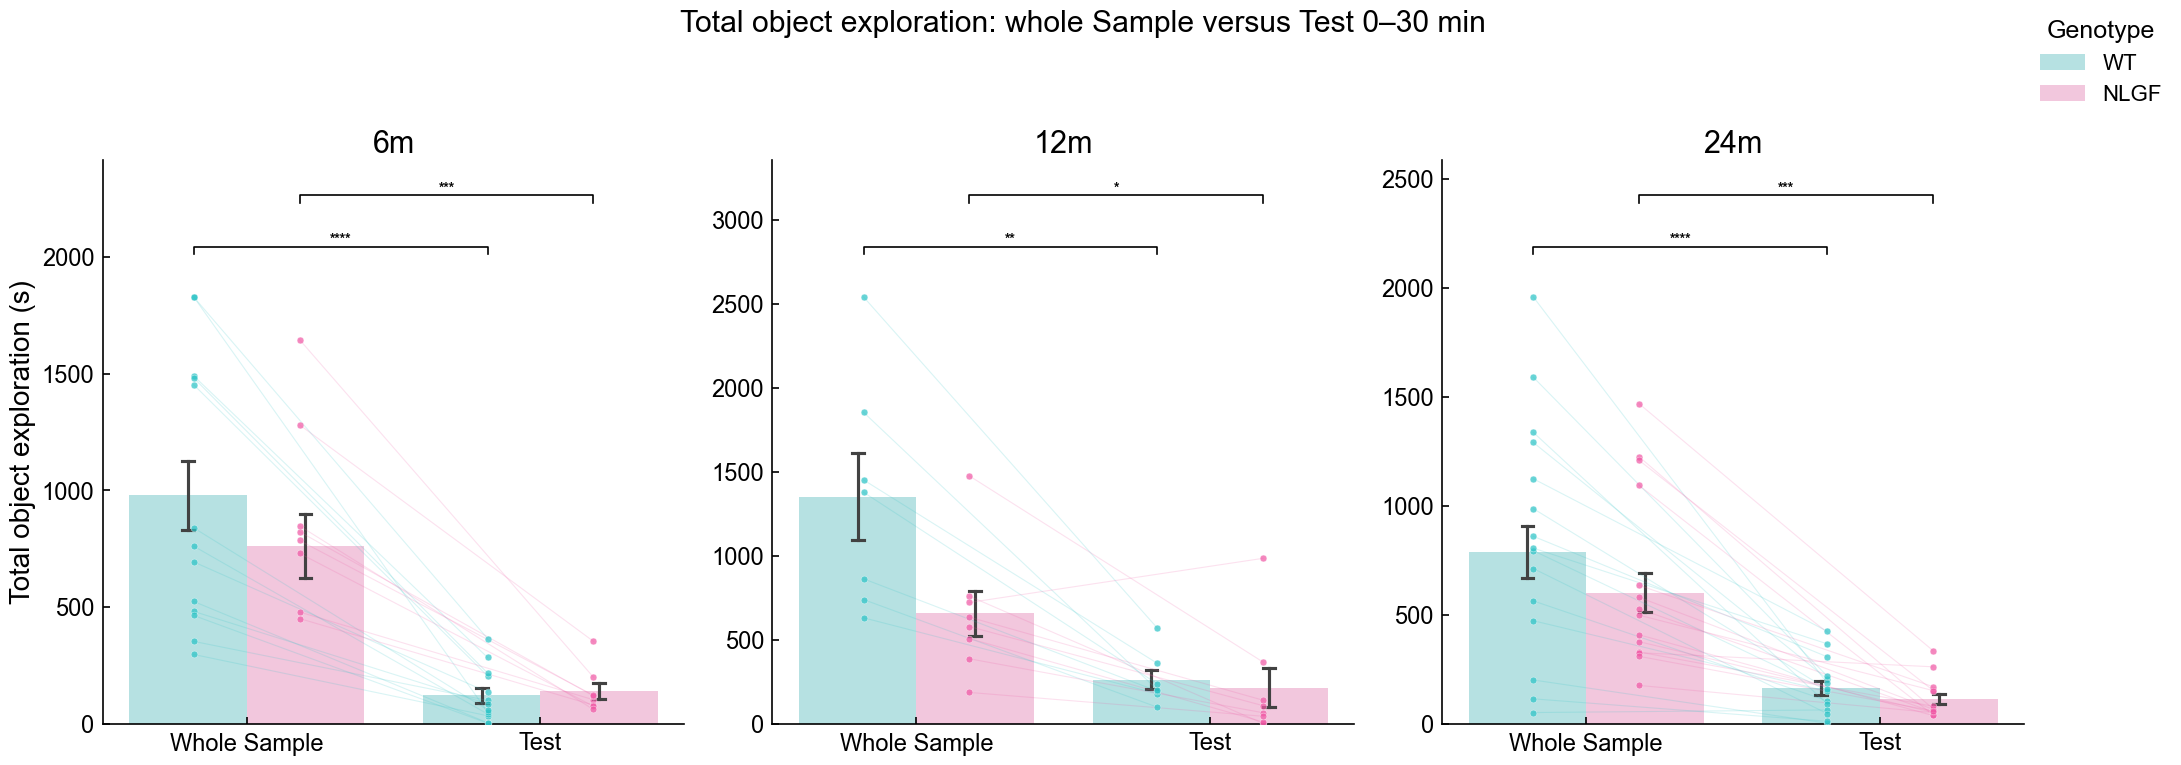

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 136_Total_object_exploration_whole_Sample_versus_Test_045_min.pdf


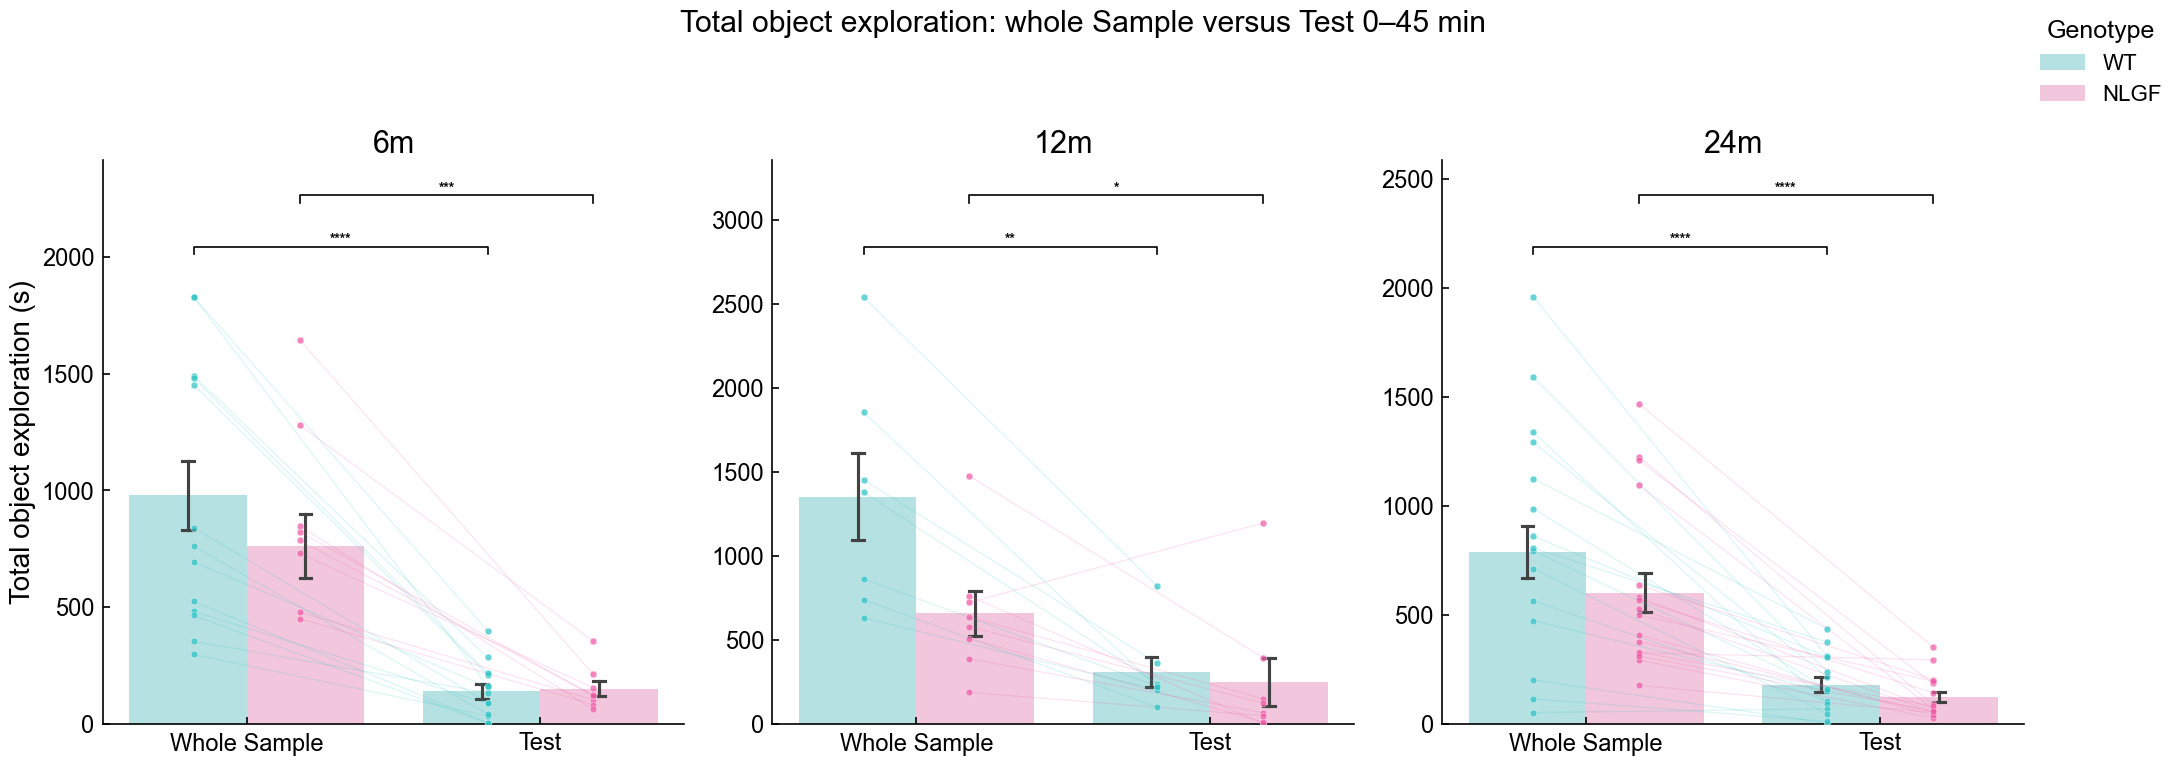

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 137_Total_object_exploration_whole_Sample_versus_Test_060_min.pdf


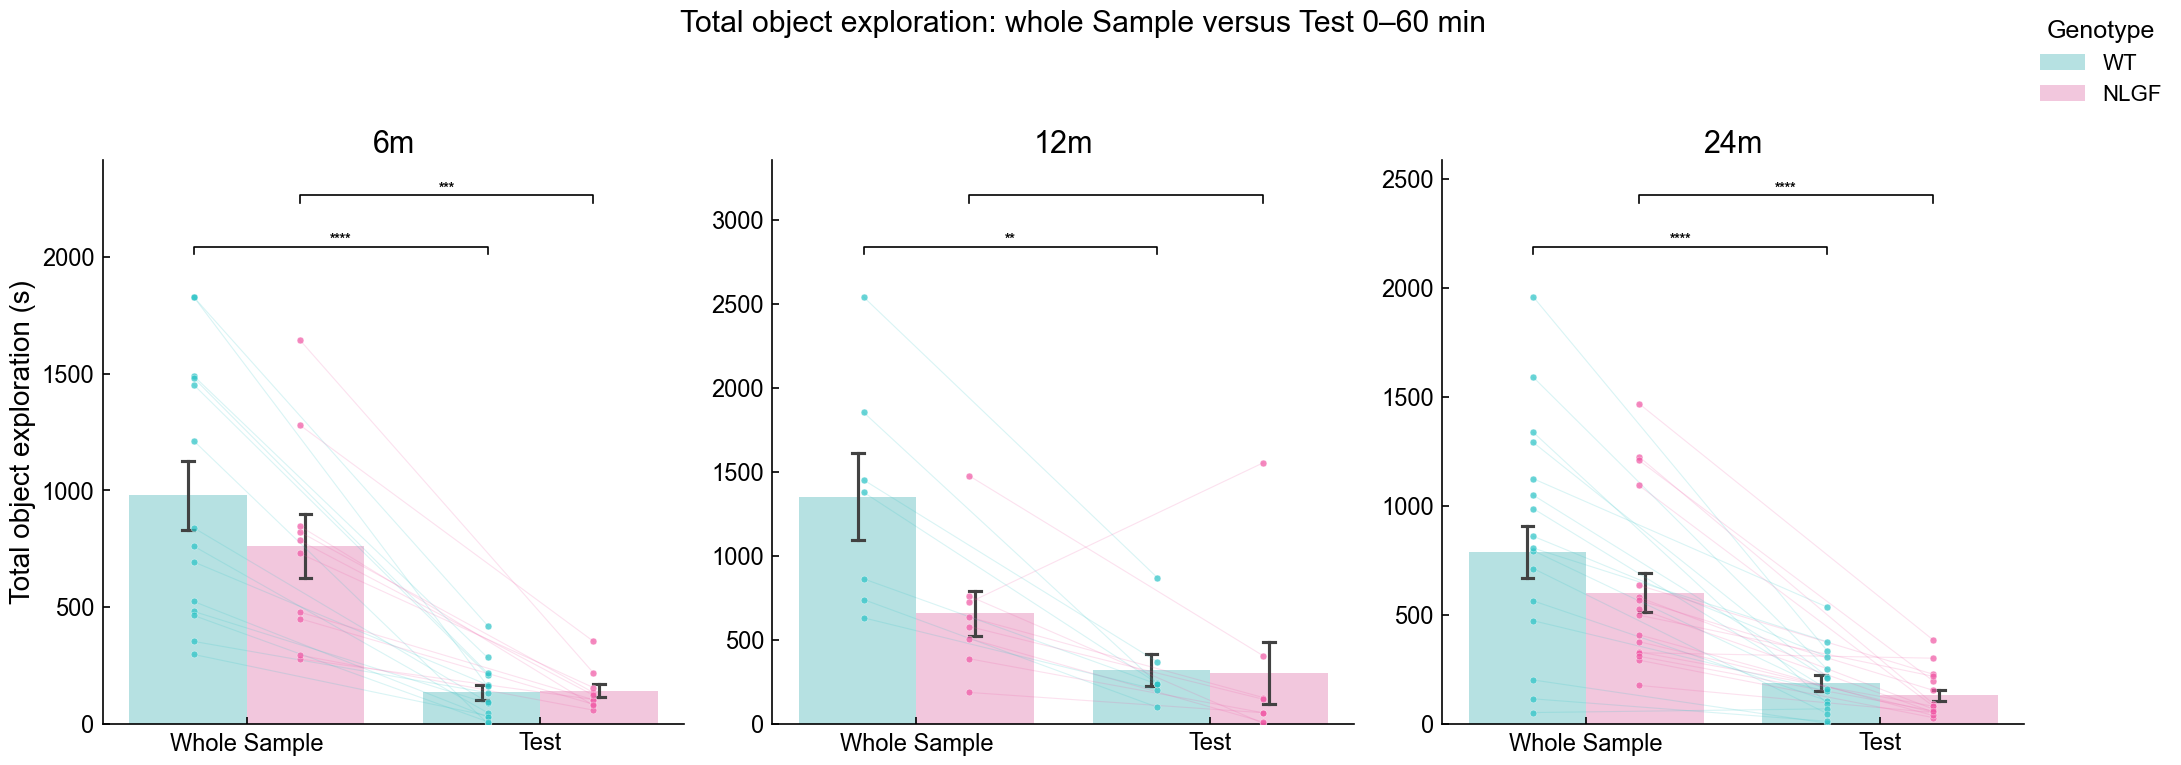

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 138_Discrimination_index_whole_Sample_versus_Test_030_min.pdf


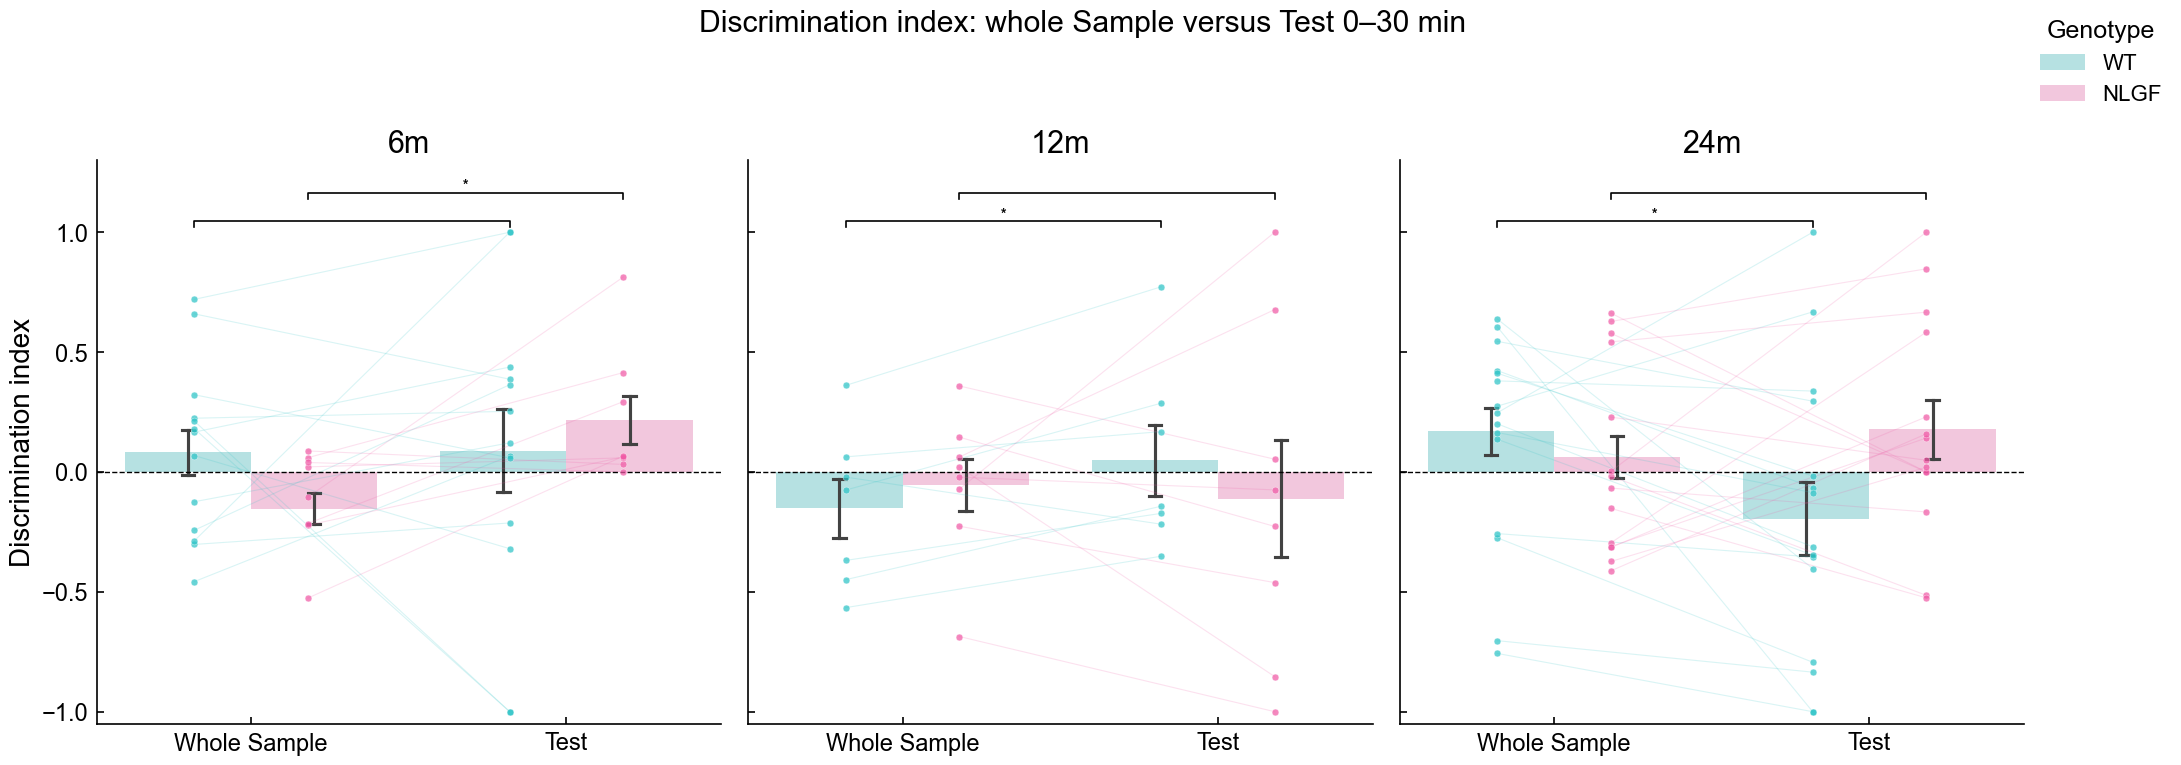

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 139_Discrimination_index_whole_Sample_versus_Test_045_min.pdf


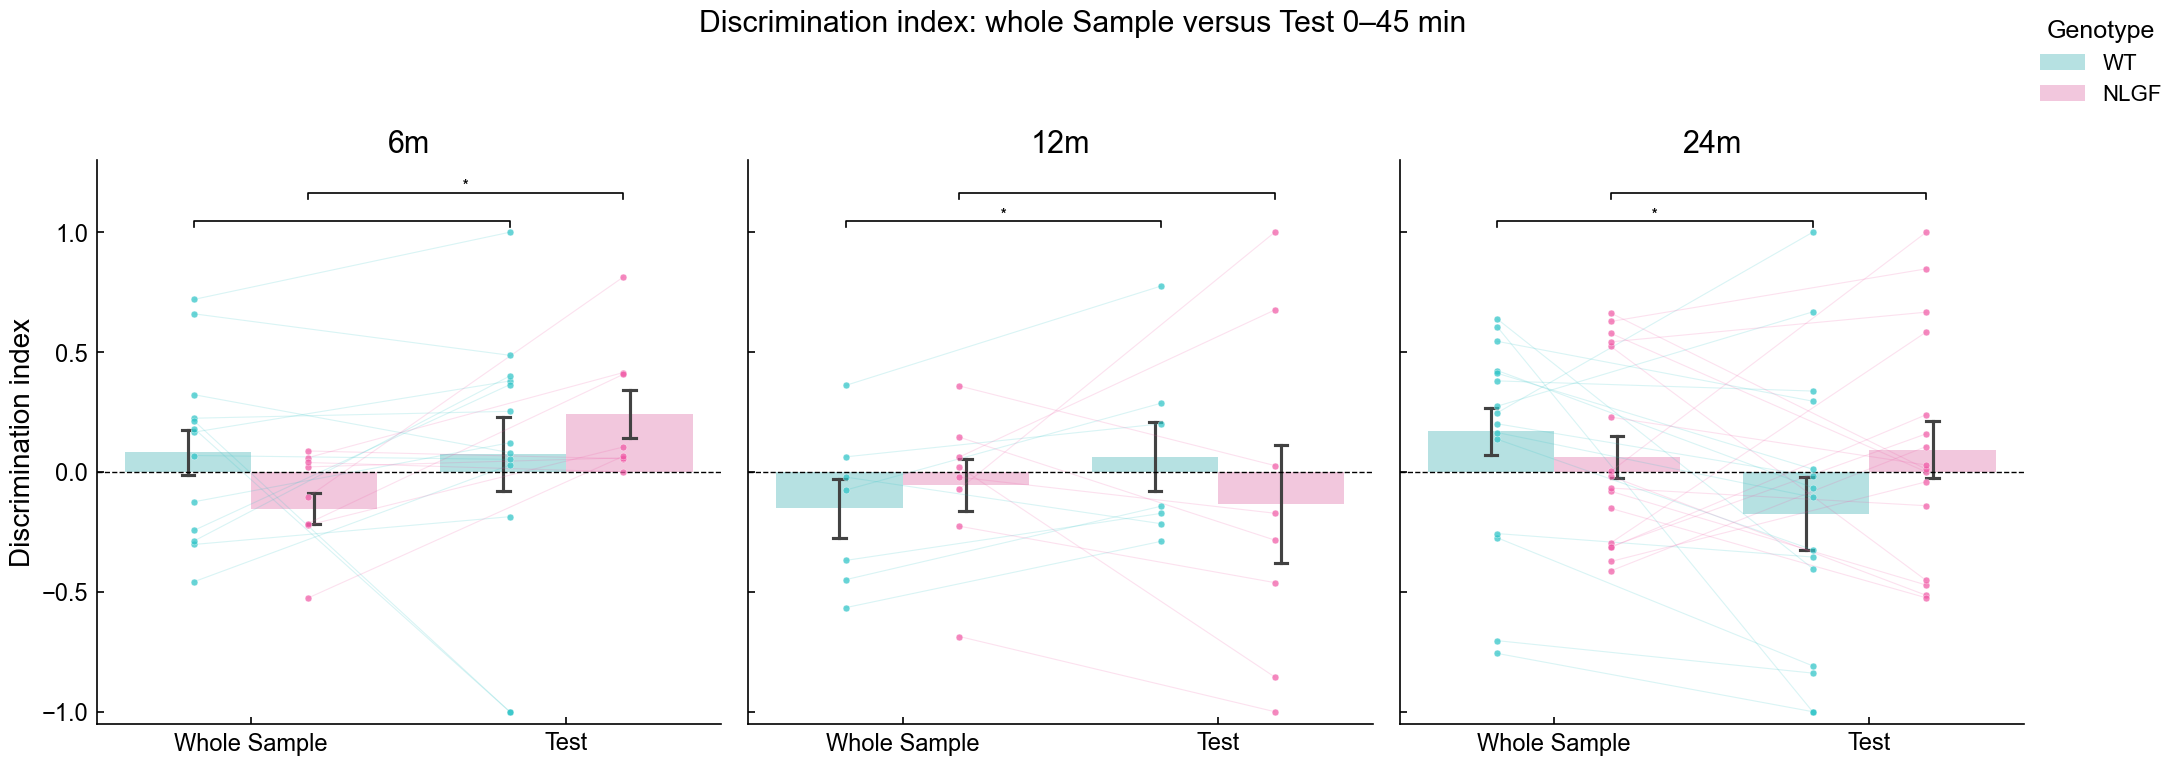

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_72251/4092563772.py:

Saved PDF: 140_Discrimination_index_whole_Sample_versus_Test_060_min.pdf


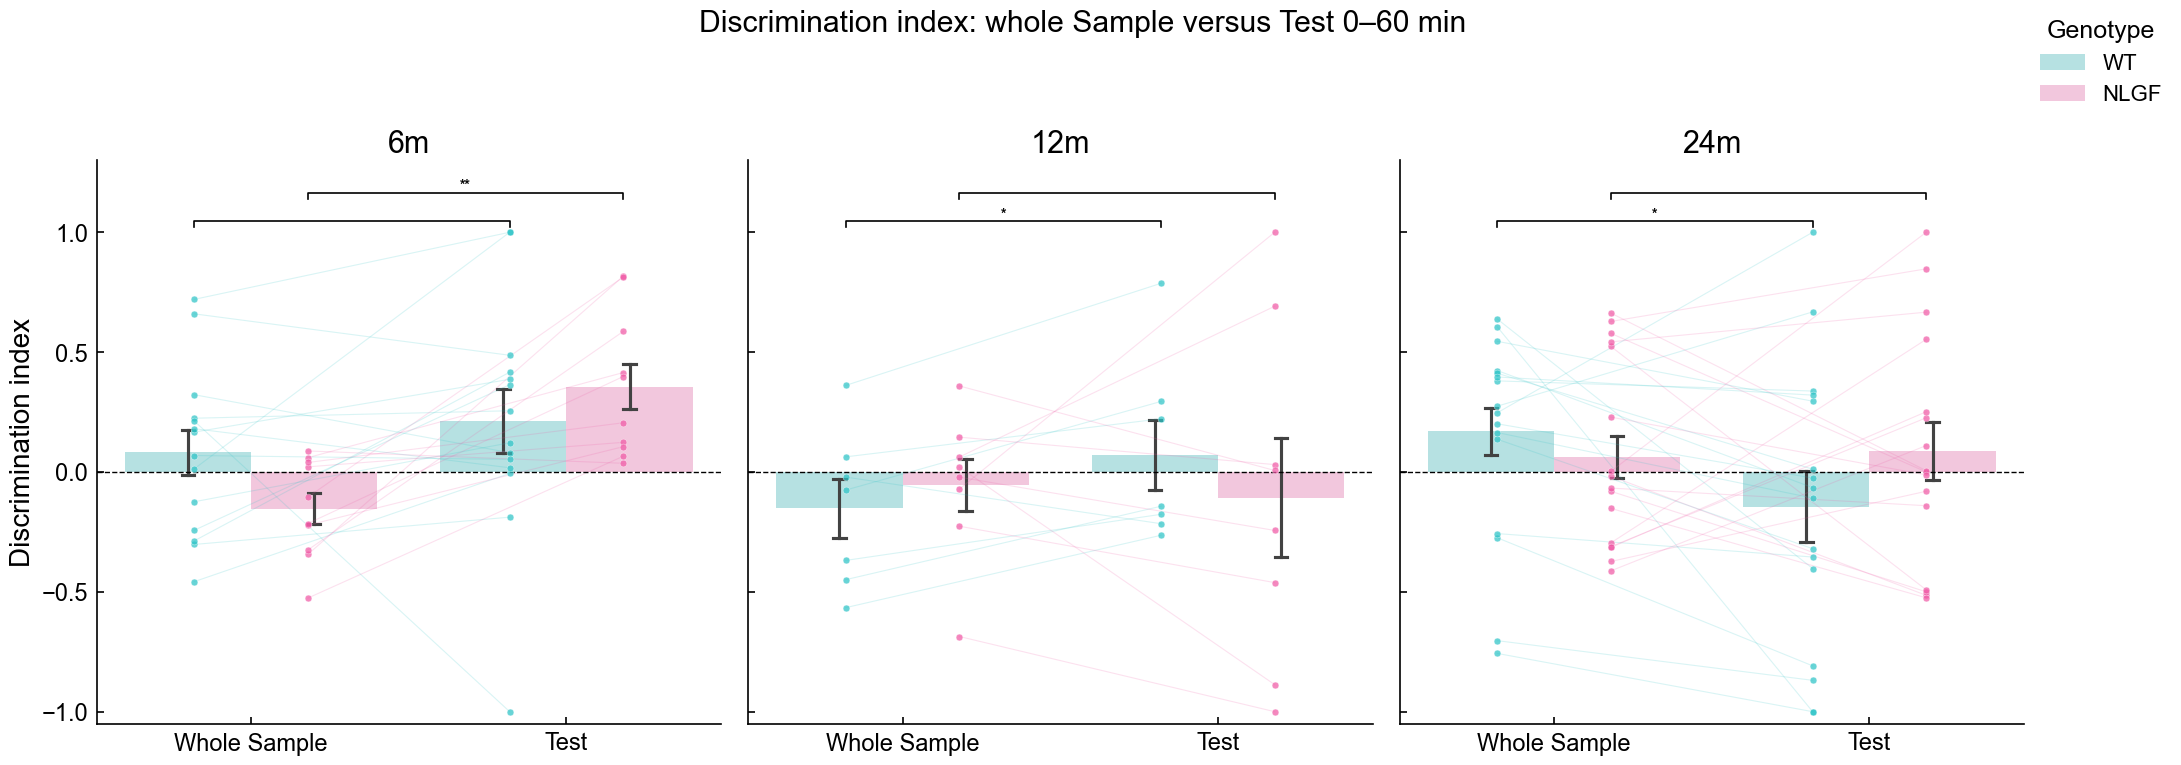

In [ ]:
# ==========================================================
# REORGANISED FIGURES BY TEST ENDPOINT
#
# One figure per endpoint:
#   Whole Sample vs 30 min Test: 6m, 12m, 24m
#   Whole Sample vs 45 min Test: 6m, 12m, 24m
#   Whole Sample vs 60 min Test: 6m, 12m, 24m
#
# Separate figure sets are produced for:
#   1. Total object exploration
#   2. Discrimination index
# ==========================================================

PHASE_X = {"sample": 0, "test": 1}
GENOTYPE_OFFSET = {"WT": -0.18, "NLGF": 0.18}


def plot_endpoint_across_ages(
    data,
    stats_df,
    value_col,
    ylabel,
    figure_title,
    output_prefix,
    di_plot=False,
):
    """
    Produce one figure for each Test endpoint.

    Each figure contains three panels:
        6m, 12m and 24m

    Within each age panel:
        whole Sample vs cumulative Test
        WT and NLGF shown separately
        paired mouse values connected
    """

    for cutoff_min in EARLY_TIMEPOINTS_MIN:

        fig, axes = plt.subplots(
            1,
            len(AGE_ORDER),
            figsize=(22, 7.5),
            sharey=di_plot,
        )
        axes = np.atleast_1d(axes)

        for ax, age in zip(axes, AGE_ORDER):

            panel_df = data[
                data["Age"].eq(age)
                & data["time_min"].eq(cutoff_min)
            ].copy()

            sns.barplot(
                data=panel_df,
                x="Phase",
                y=value_col,
                hue="Genotype",
                order=SAMPLE_TEST_PHASES,
                hue_order=EARLY_GENOTYPES,
                palette=GENO_COLORS,
                errorbar="se",
                capsize=0.08,
                alpha=0.38,
                ax=ax,
            )

            # ----------------------------------------------
            # Mouse-level paired lines and points
            # ----------------------------------------------
            for genotype in EARLY_GENOTYPES:

                genotype_df = panel_df[
                    panel_df["Genotype"].eq(genotype)
                ].copy()

                paired = (
                    genotype_df
                    .pivot_table(
                        index="MouseSessionID",
                        columns="Phase",
                        values=value_col,
                        aggfunc="first",
                    )
                    .dropna(subset=SAMPLE_TEST_PHASES)
                )

                x_sample = (
                    PHASE_X["sample"]
                    + GENOTYPE_OFFSET[genotype]
                )
                x_test = (
                    PHASE_X["test"]
                    + GENOTYPE_OFFSET[genotype]
                )

                for _, row in paired.iterrows():

                    ax.plot(
                        [x_sample, x_test],
                        [row["sample"], row["test"]],
                        color=GENO_COLORS[genotype],
                        alpha=0.18,
                        linewidth=0.8,
                        zorder=2,
                    )

                    ax.scatter(
                        [x_sample, x_test],
                        [row["sample"], row["test"]],
                        color=GENO_COLORS[genotype],
                        edgecolor="white",
                        linewidth=0.35,
                        s=24,
                        alpha=0.72,
                        zorder=3,
                    )

            # ----------------------------------------------
            # Statistical brackets
            # ----------------------------------------------
            if di_plot:
                bracket_levels = {
                    "WT": 1.02,
                    "NLGF": 1.14,
                }
                bracket_height = 0.025

            else:
                panel_max = finite_max(
                    panel_df[value_col],
                    default=1,
                )
                bracket_step = max(panel_max * 0.10, 1)

                bracket_levels = {
                    "WT": panel_max + bracket_step,
                    "NLGF": panel_max + bracket_step * 2.2,
                }
                bracket_height = bracket_step * 0.18

            for genotype in EARLY_GENOTYPES:

                stat_row = stats_df[
                    stats_df["Age"].eq(age)
                    & stats_df["Genotype"].eq(genotype)
                    & stats_df["time_min"].eq(cutoff_min)
                ]

                if stat_row.empty:
                    continue

                add_bracket(
                    ax,
                    PHASE_X["sample"]
                    + GENOTYPE_OFFSET[genotype],
                    PHASE_X["test"]
                    + GENOTYPE_OFFSET[genotype],
                    bracket_levels[genotype],
                    stat_row.iloc[0]["stars"],
                    height=bracket_height,
                    fontsize=10,
                )

            # ----------------------------------------------
            # Axis formatting
            # ----------------------------------------------
            ax.set_title(age)
            ax.set_xlabel("")
            ax.set_xticks([0, 1])
            ax.set_xticklabels(
                ["Whole Sample", "Test"]
            )

            ax.set_ylabel(
                ylabel if age == AGE_ORDER[0] else ""
            )

            if di_plot:
                ax.axhline(
                    0,
                    color="black",
                    linestyle="--",
                    linewidth=1,
                )
                ax.set_ylim(-1.05, 1.30)

            else:
                panel_max = finite_max(
                    panel_df[value_col],
                    default=1,
                )
                bracket_step = max(panel_max * 0.10, 1)

                ax.set_ylim(
                    bottom=0,
                    top=max(
                        ax.get_ylim()[1],
                        panel_max + bracket_step * 3.2,
                    ),
                )

            format_axes(ax)

            if ax.get_legend() is not None:
                ax.get_legend().remove()

        # ----------------------------------------------
        # Shared legend and title
        # ----------------------------------------------
        handles, labels = axes[-1].get_legend_handles_labels()

        fig.legend(
            handles[:2],
            labels[:2],
            title="Genotype",
            frameon=False,
            loc="upper right",
        )

        fig.suptitle(
            (
                f"{figure_title}: whole Sample versus "
                f"Test 0–{cutoff_min} min"
            ),
            y=1.03,
        )

        plt.tight_layout(
            rect=[0, 0, 0.94, 0.98]
        )

        # Save using your existing PDF helper.
        save_figure_pdf()

        # Optional separate named PDF.
        if "LOUKIA_OUTPUT_DIR" in globals():
            fig.savefig(
                LOUKIA_OUTPUT_DIR
                / (
                    f"{output_prefix}_whole_sample_vs_"
                    f"test_{cutoff_min}min_across_ages.pdf"
                ),
                format="pdf",
                bbox_inches="tight",
            )

        plt.show()


# ==========================================================
# 1. TOTAL OBJECT EXPLORATION
# ==========================================================

plot_endpoint_across_ages(
    data=total_exploration_30_45_60,
    stats_df=total_exploration_sample_test_stats,
    value_col="Total_exploration_sec",
    ylabel="Total object exploration (s)",
    figure_title="Total object exploration",
    output_prefix="total_object_exploration",
    di_plot=False,
)


# ==========================================================
# 2. DISCRIMINATION INDEX
# ==========================================================

plot_endpoint_across_ages(
    data=sample_test_DI_30_45_60,
    stats_df=di_sample_test_stats,
    value_col="DI",
    ylabel="Discrimination index",
    figure_title="Discrimination index",
    output_prefix="discrimination_index",
    di_plot=True,
)

In [ ]:

# ==========================================================
# FINALISE THE COMBINED MULTIPAGE PDF
# ==========================================================

try:
    _ALL_FIGURES_PDF.close()
    print(f"Combined PDF saved successfully:\n{ALL_FIGURES_PDF_PATH}")
    print(f"Total figures saved: {_FIGURE_PDF_COUNTER}")
except Exception as exc:
    print(f"Could not close the combined PDF writer: {exc}")


Combined PDF saved successfully:
/Volumes/Aimi_SmrtKg/NOR_MASTER/SmartKage_NOR_all_figures.pdf
Total figures saved: 140


# FINAL statistical analysis 
This section supersedes earlier exploratory statistics. It performs normality checks, chooses parametric/non-parametric tests as appropriate, and reports **raw p-values only**.


In [ ]:
# ==========================================================
# STATISTICS HELPERS 
# ==========================================================
# IMPORTANT:
# - Independent WT vs NLGF comparisons: Shapiro-Wilk per group ->
#   Welch two-tailed t-test if both groups pass, otherwise Mann-Whitney U.
# - Paired comparisons: Shapiro-Wilk on paired differences ->
#   paired t-test if normal, otherwise Wilcoxon signed-rank.
# - Age x Genotype for one-value-per-mouse outcomes: ordinary two-way ANOVA
#   using a Type III ANOVA table.
# - Repeated observations within the same mouse (period/ITI/phase/side/time):
#   mixed-effects repeated-measures model with mouse as a random intercept.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, ttest_rel, wilcoxon, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

ALPHA_FINAL = 0.05


def _final_clean(x):
    return pd.to_numeric(pd.Series(x), errors='coerce').dropna().to_numpy(dtype=float)


def _final_shapiro(x):
    x = _final_clean(x)
    if len(x) < 3:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': 'Shapiro-Wilk requires at least 3 observations'}
    try:
        W, p = shapiro(x)
        return {'n': len(x), 'W': float(W), 'p_value': float(p),
                'normal': bool(p > ALPHA_FINAL), 'note': ''}
    except Exception as exc:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': str(exc)}


def _final_sig(p):
    if pd.isna(p): return 'NA'
    if p < 0.0001: return '****'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'


def final_independent_test(df, value_col, group_col='Genotype', g1='WT', g2='NLGF', context=None):
    context = {} if context is None else dict(context)
    x = _final_clean(df.loc[df[group_col].eq(g1), value_col])
    y = _final_clean(df.loc[df[group_col].eq(g2), value_col])
    nx = _final_shapiro(x); ny = _final_shapiro(y)
    row = {**context, 'value_col': value_col, 'group_1': g1, 'group_2': g2,
           'n_1': len(x), 'n_2': len(y),
           'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'median_1': np.median(x) if len(x) else np.nan,
           'median_2': np.median(y) if len(y) else np.nan,
           'shapiro_1_W': nx['W'], 'shapiro_1_p': nx['p_value'],
           'shapiro_2_W': ny['W'], 'shapiro_2_p': ny['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(x) < 2 or len(y) < 2:
        row['note'] = 'Fewer than 2 observations in at least one group'
        row['stars'] = 'NA'; return row
    if nx['normal'] is True and ny['normal'] is True:
        stat, p = ttest_ind(x, y, equal_var=False, alternative='two-sided')
        test = 'Welch two-tailed unpaired t-test'
    else:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        test = 'Mann-Whitney U'
    row.update(test=test, statistic=float(stat), p_value=float(p), stars=_final_sig(p), note='')
    return row


def final_paired_test(df, subject_col, condition_col, value_col, c1, c2, context=None):
    context = {} if context is None else dict(context)
    wide = (df[df[condition_col].isin([c1, c2])]
            .pivot_table(index=subject_col, columns=condition_col, values=value_col, aggfunc='mean'))
    if c1 not in wide.columns or c2 not in wide.columns:
        return {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
                'n_pairs': 0, 'test': 'not tested', 'statistic': np.nan,
                'p_value': np.nan, 'stars': 'NA', 'note': 'Required condition missing'}
    wide = wide.dropna(subset=[c1, c2])
    x = pd.to_numeric(wide[c1], errors='coerce').to_numpy(float)
    y = pd.to_numeric(wide[c2], errors='coerce').to_numpy(float)
    d = y - x
    nd = _final_shapiro(d)
    row = {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
           'n_pairs': len(wide), 'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'mean_change_2_minus_1': np.mean(d) if len(d) else np.nan,
           'difference_shapiro_W': nd['W'], 'difference_shapiro_p': nd['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(wide) < 2:
        row['stars']='NA'; row['note']='Fewer than 2 complete pairs'; return row
    if nd['normal'] is True:
        stat, p = ttest_rel(y, x, alternative='two-sided')
        test = 'Paired two-tailed t-test'
    else:
        try:
            stat, p = wilcoxon(y, x, alternative='two-sided', zero_method='wilcox')
            test = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p, test = np.nan, np.nan, 'Wilcoxon unavailable'
    row.update(test=test, statistic=float(stat) if np.isfinite(stat) else np.nan,
               p_value=float(p) if np.isfinite(p) else np.nan,
               stars=_final_sig(p), note='')
    return row


def final_normality_table(df, value_col, group_cols):
    rows=[]
    for keys, sub in df.groupby(group_cols, observed=True, dropna=False):
        if not isinstance(keys, tuple): keys=(keys,)
        r=_final_shapiro(sub[value_col])
        rows.append({**dict(zip(group_cols, keys)), 'value_col': value_col, **r})
    return pd.DataFrame(rows)


def final_two_way_anova(df, value_col, age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    d=df[[value_col, age_col, genotype_col]].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula = f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}'))"
    model = smf.ols(formula, data=d).fit()
    aov = anova_lm(model, typ=3).reset_index().rename(columns={'index':'Effect', 'PR(>F)':'p_value'})
    aov['stars']=aov['p_value'].apply(_final_sig)
    for k,v in context.items(): aov[k]=v
    resid = pd.DataFrame([{**context, 'value_col': value_col, 'analysis':'two-way ANOVA residuals', **_final_shapiro(model.resid)}])
    return aov, resid


def final_mixed_repeated(df, value_col, subject_col, repeated_col,
                         age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    cols=[value_col, subject_col, repeated_col, age_col, genotype_col]
    d=df[cols].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula=(f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}')) * C(Q('{repeated_col}'))")
    try:
        fit=smf.mixedlm(formula, d, groups=d[subject_col]).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
        ci=fit.conf_int()
        terms=[]
        for term,p in fit.pvalues.items():
            if term in ('Group Var','Intercept'): continue
            terms.append({**context, 'value_col':value_col, 'term':term,
                          'coefficient':fit.params.get(term,np.nan),
                          'SE':fit.bse.get(term,np.nan),
                          'CI_low':ci.loc[term,0] if term in ci.index else np.nan,
                          'CI_high':ci.loc[term,1] if term in ci.index else np.nan,
                          'p_value':p, 'stars':_final_sig(p),
                          'model':'Mixed-effects repeated-measures model (random intercept = mouse)'})
        residual=pd.DataFrame([{**context, 'value_col':value_col, 'analysis':'mixed-model residuals', **_final_shapiro(fit.resid)}])
        return pd.DataFrame(terms), residual
    except Exception as exc:
        return pd.DataFrame([{**context,'value_col':value_col,'term':'MODEL_FAILED','p_value':np.nan,'stars':'NA','note':str(exc)}]), pd.DataFrame()

# ==========================================================
# FINAL NOR STATISTICS — RAW P VALUES ONLY
# ==========================================================
FINAL_STATS_DIR = MASTER_OUTPUT / 'FINAL_unadjusted_statistics'
FINAL_STATS_DIR.mkdir(exist_ok=True)

# 1) Total exploration: WT vs NLGF within each age and phase + repeated phase model.
normality=[]; pairwise=[]
if 'phase_total' in globals():
    d=phase_total[phase_total['Genotype'].isin(['WT','NLGF'])].copy()
    normality.append(final_normality_table(d,'total_sec',['Age','Genotype','Phase']).assign(Analysis='Total exploration'))
    for age in AGE_ORDER:
        for phase in PHASE_ORDER:
            pairwise.append(final_independent_test(d[d['Age'].eq(age)&d['Phase'].eq(phase)],'total_sec',
                context={'Analysis':'Total exploration','Age':age,'Phase':phase,'Comparison':'WT vs NLGF'}))
    total_rm,total_rm_resid=final_mixed_repeated(d,'total_sec','MouseSessionID','Phase',context={'Analysis':'Total exploration'})
else:
    total_rm,total_rm_resid=pd.DataFrame(),pd.DataFrame()

# 2) Whole-24 h sample vs test DI: paired t/Wilcoxon within genotype.
paired_rows=[]
if 'sample_test_di_24h' in globals():
    d24=sample_test_di_24h[sample_test_di_24h['Genotype'].isin(['WT','NLGF'])].copy()
    for age in AGE_ORDER:
        for genotype in ['WT','NLGF']:
            sub=d24[d24['Age'].eq(age)&d24['Genotype'].eq(genotype)]
            paired_rows.append(final_paired_test(sub,'MouseSessionID','Phase','DI','sample','test',
                context={'Analysis':'Whole 24h DI: Sample vs Test','Age':age,'Genotype':genotype}))
    di_phase_rm,di_phase_rm_resid=final_mixed_repeated(d24,'DI','MouseSessionID','Phase',context={'Analysis':'Whole 24h DI'})
else:
    di_phase_rm,di_phase_rm_resid=pd.DataFrame(),pd.DataFrame()

# 3) Whole-24 h test DI: age x genotype two-way ANOVA and age-specific WT vs NLGF.
di24_geno=[]; di24_norm=[]; di24_aov=pd.DataFrame(); di24_resid=pd.DataFrame()
if 'sample_test_di_24h' in globals():
    test24=sample_test_di_24h[(sample_test_di_24h['Phase'].eq('test')) & sample_test_di_24h['Genotype'].isin(['WT','NLGF'])].copy()
    di24_norm.append(final_normality_table(test24,'DI',['Age','Genotype']).assign(Analysis='Whole 24h test DI'))
    for age in AGE_ORDER:
        di24_geno.append(final_independent_test(test24[test24['Age'].eq(age)],'DI',
            context={'Analysis':'Whole 24h test DI','Age':age,'Comparison':'WT vs NLGF'}))
    di24_aov,di24_resid=final_two_way_anova(test24,'DI',context={'Analysis':'Whole 24h test DI'})

# 4) DI/Delta-DI over 2,4,6,8 h: repeated time model + age/time-specific WT vs NLGF.
time_pairwise=[]; time_norm=[]; time_models=[]; time_resids=[]
for analysis_name, source_name, value_col in [
    ('Test DI over time','di_timepoint_df','DI'),
    ('Delta DI over time','delta_di_over_time','Delta_DI')]:
    if source_name not in globals(): continue
    src=globals()[source_name].copy()
    tcol='timepoint_h'
    src['timepoint_numeric']=pd.to_numeric(src[tcol].astype(str),errors='coerce')
    src=src[src['timepoint_numeric'].isin([2,4,6,8]) & src['Genotype'].isin(['WT','NLGF'])]
    time_norm.append(final_normality_table(src,value_col,['Age','Genotype','timepoint_numeric']).assign(Analysis=analysis_name))
    for age in AGE_ORDER:
        for tp in [2,4,6,8]:
            time_pairwise.append(final_independent_test(src[src['Age'].eq(age)&src['timepoint_numeric'].eq(tp)],value_col,
                context={'Analysis':analysis_name,'Age':age,'timepoint_h':tp,'Comparison':'WT vs NLGF'}))
    model,resid=final_mixed_repeated(src,value_col,'MouseSessionID','timepoint_numeric',context={'Analysis':analysis_name})
    if not model.empty: time_models.append(model)
    if not resid.empty: time_resids.append(resid)

# 5) First approach: Fisher exact at each age; logistic regression for Age x Genotype.
fisher_rows=[]; logistic_df=pd.DataFrame()
if 'first_binary' in globals():
    fb=first_binary[first_binary['Genotype'].isin(['WT','NLGF'])].copy()
    fb['novel_first']=fb['FirstApproach'].eq('novel').astype(int)
    for age in AGE_ORDER:
        sub=fb[fb['Age'].eq(age)]
        tab=pd.crosstab(sub['Genotype'],sub['FirstApproach']).reindex(index=['WT','NLGF'],columns=['novel','familiar'],fill_value=0)
        if tab.sum().sum() and (tab.sum(axis=1)>0).all():
            odds,p=fisher_exact(tab.to_numpy(),alternative='two-sided')
        else: odds,p=np.nan,np.nan
        fisher_rows.append({'Analysis':'Novel first','Age':age,'test':'Fisher exact','odds_ratio':odds,'p_value':p,'stars':_final_sig(p),
                            'WT_novel':tab.loc['WT','novel'],'WT_familiar':tab.loc['WT','familiar'],
                            'NLGF_novel':tab.loc['NLGF','novel'],'NLGF_familiar':tab.loc['NLGF','familiar']})
    try:
        fit=smf.glm("novel_first ~ C(Age) * C(Genotype)",data=fb,family=sm.families.Binomial()).fit()
        ci=fit.conf_int(); logistic_df=pd.DataFrame({'term':fit.params.index,'coefficient':fit.params.values,'SE':fit.bse.values,
            'CI_low':ci[0].values,'CI_high':ci[1].values,'p_value':fit.pvalues.values})
        logistic_df['stars']=logistic_df['p_value'].apply(_final_sig)
        logistic_df['Analysis']='Novel first logistic regression: Age x Genotype'
    except Exception as exc:
        logistic_df=pd.DataFrame([{'Analysis':'Novel first logistic regression: Age x Genotype','term':'MODEL_FAILED','p_value':np.nan,'note':str(exc)}])

normality_df=pd.concat(normality+di24_norm+time_norm,ignore_index=True) if (normality or di24_norm or time_norm) else pd.DataFrame()
pairwise_df=pd.DataFrame(pairwise+di24_geno+time_pairwise)
paired_df=pd.DataFrame(paired_rows)
repeated_df=pd.concat([x for x in [total_rm,di_phase_rm]+time_models if not x.empty],ignore_index=True) if any([not x.empty for x in [total_rm,di_phase_rm]+time_models]) else pd.DataFrame()
repeated_resid_df=pd.concat([x for x in [total_rm_resid,di_phase_rm_resid]+time_resids if not x.empty],ignore_index=True) if any([not x.empty for x in [total_rm_resid,di_phase_rm_resid]+time_resids]) else pd.DataFrame()

normality_df.to_csv(FINAL_STATS_DIR/'normality_Shapiro_Wilk.csv',index=False)
pairwise_df.to_csv(FINAL_STATS_DIR/'WT_vs_NLGF_unadjusted.csv',index=False)
paired_df.to_csv(FINAL_STATS_DIR/'paired_sample_vs_test_unadjusted.csv',index=False)
di24_aov.to_csv(FINAL_STATS_DIR/'whole24h_test_DI_two_way_ANOVA_Age_x_Genotype.csv',index=False)
di24_resid.to_csv(FINAL_STATS_DIR/'whole24h_test_DI_ANOVA_residual_normality.csv',index=False)
repeated_df.to_csv(FINAL_STATS_DIR/'repeated_measures_mixed_models.csv',index=False)
repeated_resid_df.to_csv(FINAL_STATS_DIR/'repeated_model_residual_normality.csv',index=False)
pd.DataFrame(fisher_rows).to_csv(FINAL_STATS_DIR/'novel_first_Fisher_exact_unadjusted.csv',index=False)
logistic_df.to_csv(FINAL_STATS_DIR/'novel_first_logistic_Age_x_Genotype.csv',index=False)

print('FINAL RAW-P NOR statistics saved to:', FINAL_STATS_DIR)
display(pairwise_df.head(30)); display(paired_df); display(di24_aov); display(pd.DataFrame(fisher_rows))


/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


FINAL RAW-P NOR statistics saved to: /Volumes/Aimi_SmrtKg/NOR_MASTER/FINAL_unadjusted_statistics


,Analysis,Age,Phase,Comparison,value_col,group_1,group_2,n_1,n_2,mean_1,mean_2,median_1,median_2,shapiro_1_W,shapiro_1_p,shapiro_2_W,shapiro_2_p,test,statistic,p_value,stars,note,timepoint_h
0,Total exploration,6m,sample,WT vs NLGF,total_sec,WT,NLGF,14,10,978.642857,761.100000,799.750000,757.500000,0.893560,0.090984,0.906555,0.258153,Welch two-tailed unpaired t-test,1.079805,0.292067,ns,,NaN
1,Total exploration,6m,ITI_baseline,WT vs NLGF,total_sec,WT,NLGF,14,10,836.178571,442.350000,458.000000,445.500000,0.676947,0.000215,0.937609,0.526730,Mann-Whitney U,87.000000,0.333974,ns,,NaN
2,Total exploration,6m,test,WT vs NLGF,total_sec,WT,NLGF,14,10,883.607143,592.650000,588.750000,552.000000,0.741841,0.001038,0.922861,0.381436,Mann-Whitney U,80.000000,0.578031,ns,,NaN
3,Total exploration,12m,sample,WT vs NLGF,total_sec,WT,NLGF,7,8,1350.928571,656.125000,1378.000000,606.500000,0.923369,0.496014,0.873917,0.164565,Welch two-tailed unpaired t-test,2.383550,0.040705,*,,NaN
4,Total exploration,12m,ITI_baseline,WT vs NLGF,total_sec,WT,NLGF,7,8,803.428571,795.062500,789.500000,413.750000,0.958866,0.808945,0.592813,0.000131,Mann-Whitney U,41.000000,0.151981,ns,,NaN
5,Total exploration,12m,test,WT vs NLGF,total_sec,WT,NLGF,7,8,1090.071429,949.562500,772.000000,589.750000,0.720220,0.006137,0.805990,0.033168,Mann-Whitney U,35.000000,0.463403,ns,,NaN
6,Total exploration,24m,sample,WT vs NLGF,total_sec,WT,NLGF,19,18,786.842105,601.361111,794.000000,512.500000,0.963972,0.652654,0.843873,0.006790,Mann-Whitney U,202.000000,0.354031,ns,,NaN
7,Total exploration,24m,ITI_baseline,WT vs NLGF,total_sec,WT,NLGF,19,18,352.710526,231.361111,307.500000,204.750000,0.929183,0.167289,0.875324,0.021799,Mann-Whitney U,228.000000,0.086005,ns,,NaN
8,Total exploration,24m,test,WT vs NLGF,total_sec,WT,NLGF,19,18,609.000000,563.277778,719.500000,396.750000,0.841191,0.004839,0.521960,0.000001,Mann-Whitney U,201.500000,0.361948,ns,,NaN
9,Whole 24h test DI,6m,NaN,WT vs NLGF,DI,WT,NLGF,14,10,0.232082,0.257409,0.256241,0.403390,0.886517,0.072026,0.866418,0.090781,Welch two-tailed unpaired t-test,-0.160609,0.874027,ns,,NaN


,Analysis,Age,Genotype,value_col,condition_1,condition_2,n_pairs,mean_1,mean_2,mean_change_2_minus_1,difference_shapiro_W,difference_shapiro_p,test,statistic,p_value,stars,note
0,Whole 24h DI: Sample vs Test,6m,WT,DI,sample,test,14,0.082731,0.232082,0.149351,0.929409,0.299368,Paired two-tailed t-test,1.951986,0.072819,ns,
1,Whole 24h DI: Sample vs Test,6m,NLGF,DI,sample,test,10,-0.154736,0.257409,0.412144,0.942642,0.582774,Paired two-tailed t-test,3.580382,0.005927,**,
2,Whole 24h DI: Sample vs Test,12m,WT,DI,sample,test,7,-0.150705,0.172609,0.323314,0.912783,0.415481,Paired two-tailed t-test,4.816715,0.002950,**,
3,Whole 24h DI: Sample vs Test,12m,NLGF,DI,sample,test,8,-0.052126,-0.175233,-0.123107,0.968820,0.888592,Paired two-tailed t-test,-0.798200,0.450980,ns,
4,Whole 24h DI: Sample vs Test,24m,WT,DI,sample,test,19,0.169806,-0.019839,-0.189645,0.967320,0.721867,Paired two-tailed t-test,-2.718566,0.014085,*,
5,Whole 24h DI: Sample vs Test,24m,NLGF,DI,sample,test,18,0.062836,0.093018,0.030182,0.976320,0.904382,Paired two-tailed t-test,0.230122,0.820744,ns,


,Effect,sum_sq,df,F,p_value,stars,Analysis
0,Intercept,0.245652,1.0,1.464563,0.230276,ns,Whole 24h test DI
1,C(Q('Age')),0.838907,2.0,2.500758,0.089326,ns,Whole 24h test DI
2,C(Q('Genotype')),0.451711,1.0,2.693073,0.105271,ns,Whole 24h test DI
3,C(Q('Age')):C(Q('Genotype')),0.572565,2.0,1.706800,0.188909,ns,Whole 24h test DI
4,Residual,11.741143,70.0,NaN,NaN,NA,Whole 24h test DI


,Analysis,Age,test,odds_ratio,p_value,stars,WT_novel,WT_familiar,NLGF_novel,NLGF_familiar
0,Novel first,6m,Fisher exact,0.888889,1.000000,ns,8,6,6,4
1,Novel first,12m,Fisher exact,0.450000,0.619270,ns,3,4,5,3
2,Novel first,24m,Fisher exact,0.273504,0.157057,ns,4,13,9,8


## NOR RE-EXPORT
The cell below provides the requested broken-axis total-exploration figure.

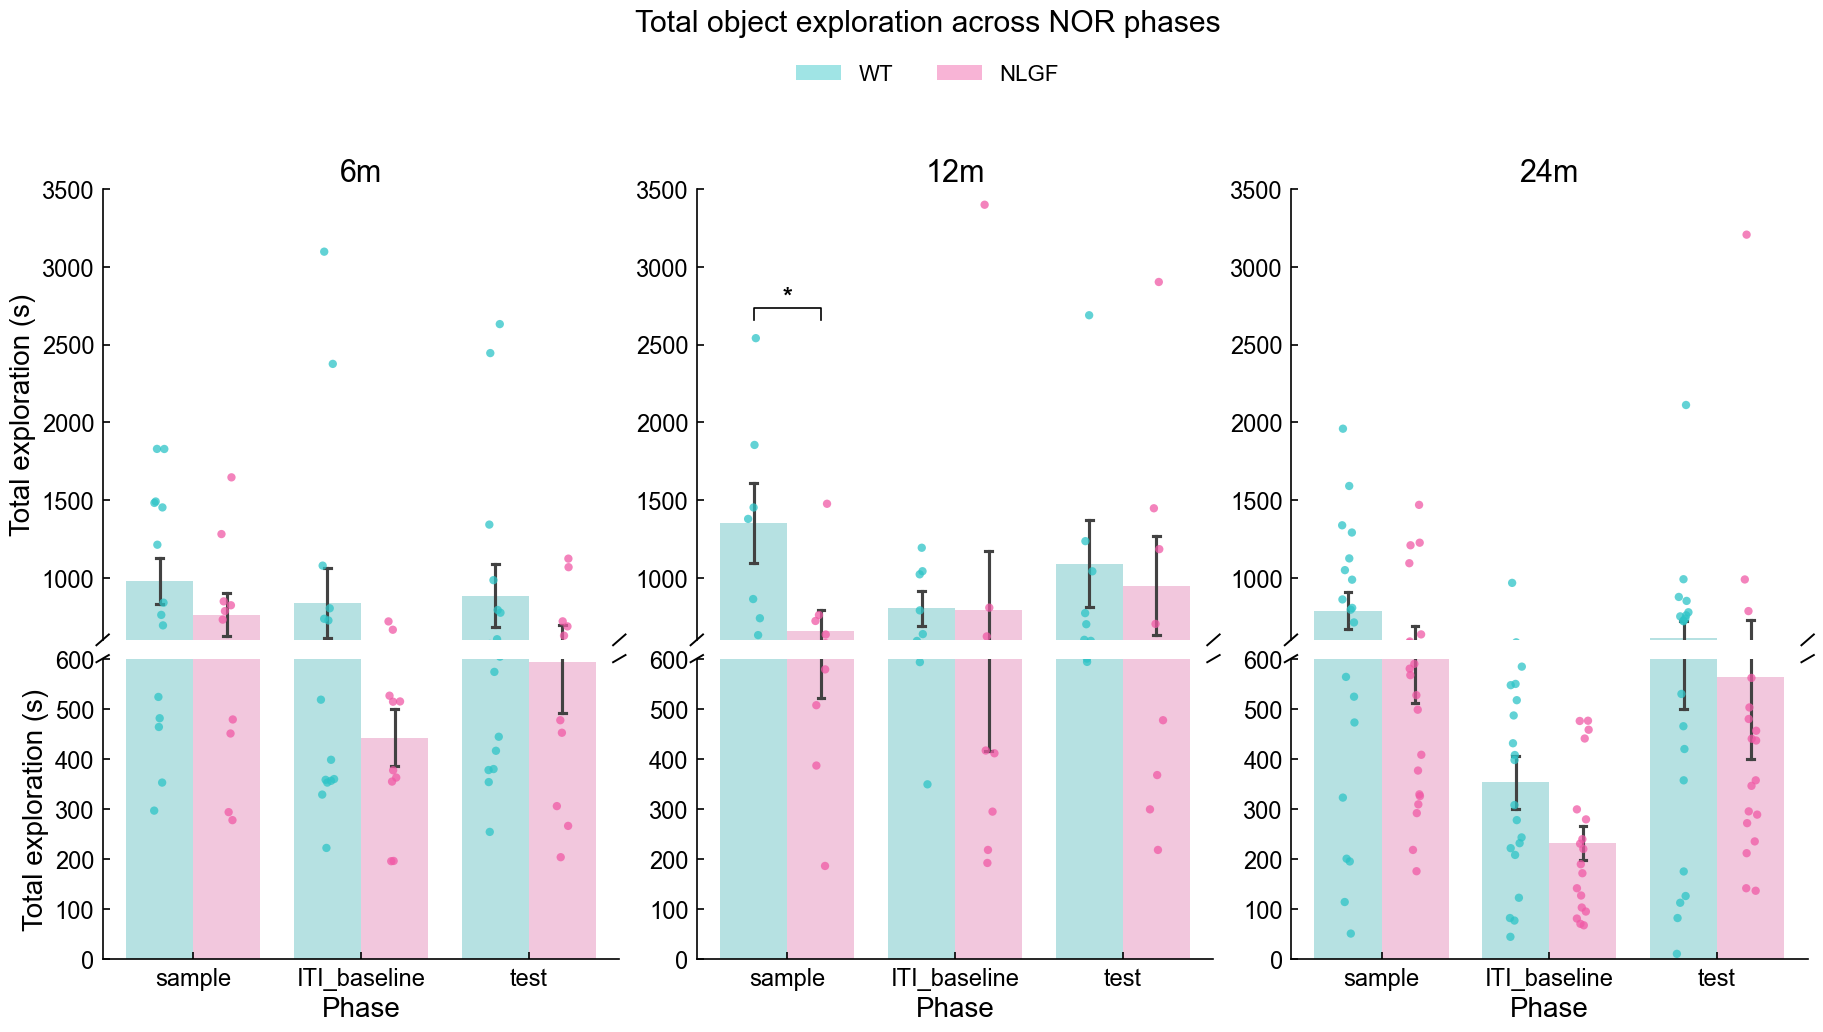

In [ ]:
def plot_total_exploration_broken_axis_thesis(phase_total, stats_df=None):
    fig=plt.figure(figsize=(22,10))
    gs=fig.add_gridspec(2,len(AGE_ORDER),height_ratios=[0.60,0.40],hspace=0.05,wspace=0.15)
    for col,age in enumerate(AGE_ORDER):
        up=fig.add_subplot(gs[0,col]); lo=fig.add_subplot(gs[1,col],sharex=up)
        sub=phase_total[(phase_total["Age"]==age)&phase_total["Genotype"].isin(["WT","NLGF"])].copy()
        for ax in [up,lo]:
            sns.barplot(data=sub,x="Phase",y="total_sec",hue="Genotype",
                        order=PHASE_ORDER,hue_order=["WT","NLGF"],palette=GENO_COLORS,
                        errorbar="se",capsize=0.08,alpha=0.38,ax=ax)
            sns.stripplot(data=sub,x="Phase",y="total_sec",hue="Genotype",
                          order=PHASE_ORDER,hue_order=["WT","NLGF"],palette=GENO_COLORS,
                          dodge=True,jitter=0.08,size=6,alpha=0.75,legend=False,ax=ax)
            if ax.get_legend() is not None: ax.get_legend().remove()
            format_axes(ax)
        lo.set_ylim(0,600); up.set_ylim(600,3500)
        up.spines["bottom"].set_visible(False); lo.spines["top"].set_visible(False)
        up.tick_params(axis="x",bottom=False,labelbottom=False)
        d=.012
        for ax,y0 in [(up,0),(lo,1)]:
            kw=dict(transform=ax.transAxes,color="black",clip_on=False,lw=1.4)
            if ax is up:
                ax.plot((-d,+d),(-d,+d),**kw); ax.plot((1-d,1+d),(-d,+d),**kw)
            else:
                ax.plot((-d,+d),(1-d,1+d),**kw); ax.plot((1-d,1+d),(1-d,1+d),**kw)
        up.set_title(age); lo.set_xlabel("Phase"); up.set_xlabel("")
        up.tick_params(axis="x", bottom=False, labelbottom=False)
        lo.set_ylabel("Total exploration (s)" if col==0 else "")
        up.set_ylabel("Total exploration (s)" if col==0 else "")
        # RAW significance stars in lower/upper segment as appropriate
        if stats_df is not None:
            offsets={"WT":-0.20,"NLGF":0.20}
            for i,phase in enumerate(PHASE_ORDER):
                row=stats_df[(stats_df["Age"]==age)&(stats_df["Phase"]==phase)]
                if row.empty: continue
                star=row.iloc[0]["stars"]
                if star in ("ns","NA",""): continue
                local=pd.to_numeric(sub.loc[sub["Phase"]==phase,"total_sec"],errors="coerce").max()
                ax=lo if local<520 else up
                y=local+35 if ax is lo else local+120
                add_bracket(ax,i+offsets["WT"],i+offsets["NLGF"],y,star,fontsize=18)
    from matplotlib.patches import Patch
    fig.legend([Patch(facecolor=GENO_COLORS[g],alpha=.45,label=g) for g in ["WT","NLGF"]],
               ["WT","NLGF"],loc="upper center",ncol=2,frameon=False, bbox_to_anchor=(0.5, 1.025))
    fig.suptitle("Total object exploration across NOR phases",y=1.06)
    fig.savefig(MASTER_OUTPUT/"THESIS_total_exploration_broken_axis.pdf",
                bbox_inches="tight",transparent=True)
    plt.show()

if "total_exploration_stats" in globals():
    plot_total_exploration_broken_axis_thesis(phase_total,total_exploration_stats)
